# Turbulence synthesis: MGD and MGD regularised (Guth method) 

This notebook runs the 1D turbulence synthesis experiment and compares MGD theta trajectories with the regularised trajectories. 


In [1]:
import torch
import numpy as np
import matplotlib as mpl
%matplotlib inline
import matplotlib.pyplot as plt
from scipy import stats, ndimage

import sys
from pathlib import Path

import hashlib
from datetime import datetime
from types import SimpleNamespace

root = Path.cwd()
print(root)

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from utils_experiment import * 
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

root = Path.cwd()
print(root) 

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence
device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence


## Data preprocessing

In [2]:
# Orthogonal wavelet
W = DefineWavelet('Db', m=3, device=device)

Data = load_turbulence_1d()
print(Data.shape) 

n = 1024
Data = split_periodize_reshape(Data, n)

#B, C, L = Data.shape
#Data = Data.view(B * 2, C, L // 2)
#print(Data.shape) 

# Same preprocessing as in the original notebook.
for j in range(2):
    Data = W.decompose(Data)[1]

n1 = 5000
x1 = normalize(Data[:n1]).to(device) # choose here if you want less data 
print('Data shape after preprocessing:', Data.shape)
print('x1 shape:', x1.shape) 

torch.Size([10000, 1, 1800])
Data shape after preprocessing: torch.Size([10000, 1, 256])
x1 shape: torch.Size([5000, 1, 256])


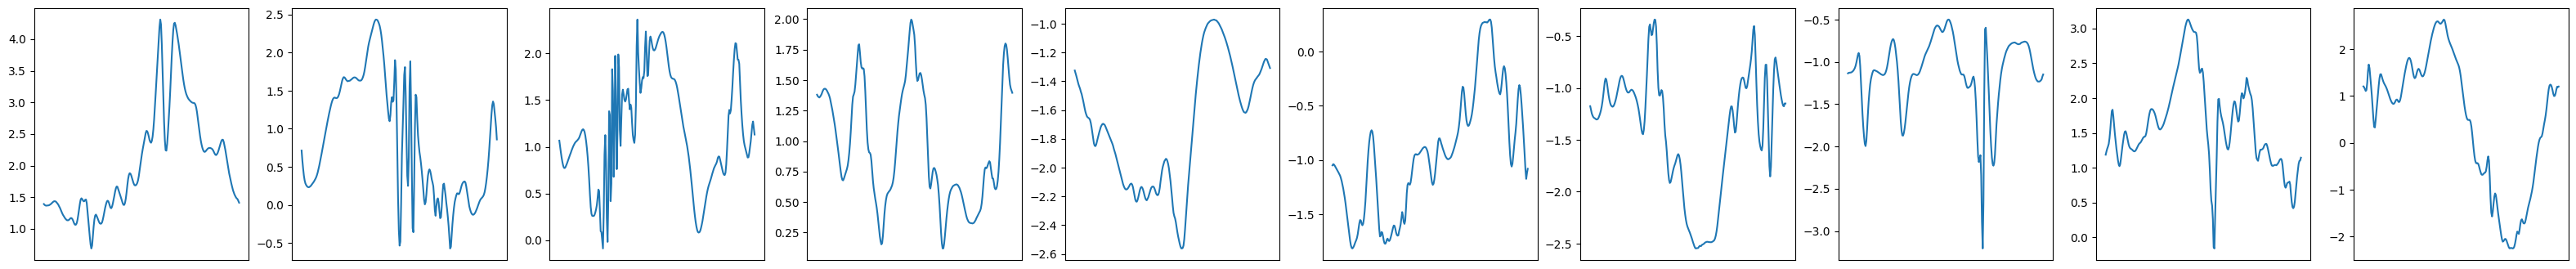

In [3]:
%matplotlib inline 
plot_time_series_row(x1, 10)

## Shared model/SDE parameters

In [5]:
B, channels, M = x1.shape
print(f'(B, C, T) = ({B}, {channels}, {M}).')

J = 8
Q = 3

filters, filters_Phi = return_Filters(M, J, 1, device=device, include_phi=True)
filters_Q = return_Filters(M, J, Q, device=device)

print("filters shape:", filters.shape) 
print("filters_Q shape:", filters_Q.shape) 

interpolant = 'Cos'
nt = 40000

# originally 50000
t = 1 - (1 - torch.linspace(0, 1, nt + 1))**2  # LINEAR SCHEDULE 
sigma = 3.5 

nb_workers = x1.shape[0]
nb_interpolants = x1.shape[0]
batch_size = x1.shape[0] 
regularization = 1e-2

n_subsample = 200
lam = 5e-07

seed = 300

terms = [
    "L_6",
    "L_6_psi", 
    "L_2_lowpass",
    "Scattering_Fourth_Order_Mod2_Real_Q1",
    "Scattering_Fourth_Order_Mod2_Imag_Q1",
    "Scalar_psi_gaussianK",
    "Scalar_morlet_gaussianK", 
]

timestamp= datetime.now().strftime("%Y%m%d_%H%M")

FORCE_RERUN = False
SAVE_AUX_MOMENTS = True

label = ""

args = SimpleNamespace(
       Re_number=None, timestamp=timestamp, label=label,
       J=J, Q=Q, terms=terms,
       nt=nt, sigma=sigma, interpolant=interpolant,
       regularization=regularization, lam=lam, n_subsample=n_subsample,
       batch_size=None, force_rerun=FORCE_RERUN, no_save_aux_moments=not SAVE_AUX_MOMENTS,
       n_traj_groups=5, n_tau=30, moment_threshold=1e-8, n1=x1.shape[0], seed=seed,
   )

config = build_config_name(args, M, coarse_grained=False, include_timestamp=True)
log_dir = root / 'saved_results/logs'
exp_dir = root / 'saved_results' / 'experiments' / config
fig_dir = exp_dir / 'figures'
exp_dir.mkdir(parents=True, exist_ok=True)
fig_dir.mkdir(parents=True, exist_ok=True)
logger = setup_logging(log_dir, config)

(B, C, T) = (5000, 1, 256).
filters shape: torch.Size([1, 9, 256])
filters_Q shape: torch.Size([1, 25, 256])


## save wavelet coefficients 

## Check wavelet coefficients histograms, Q=3

torch.Size([3000, 22, 128])


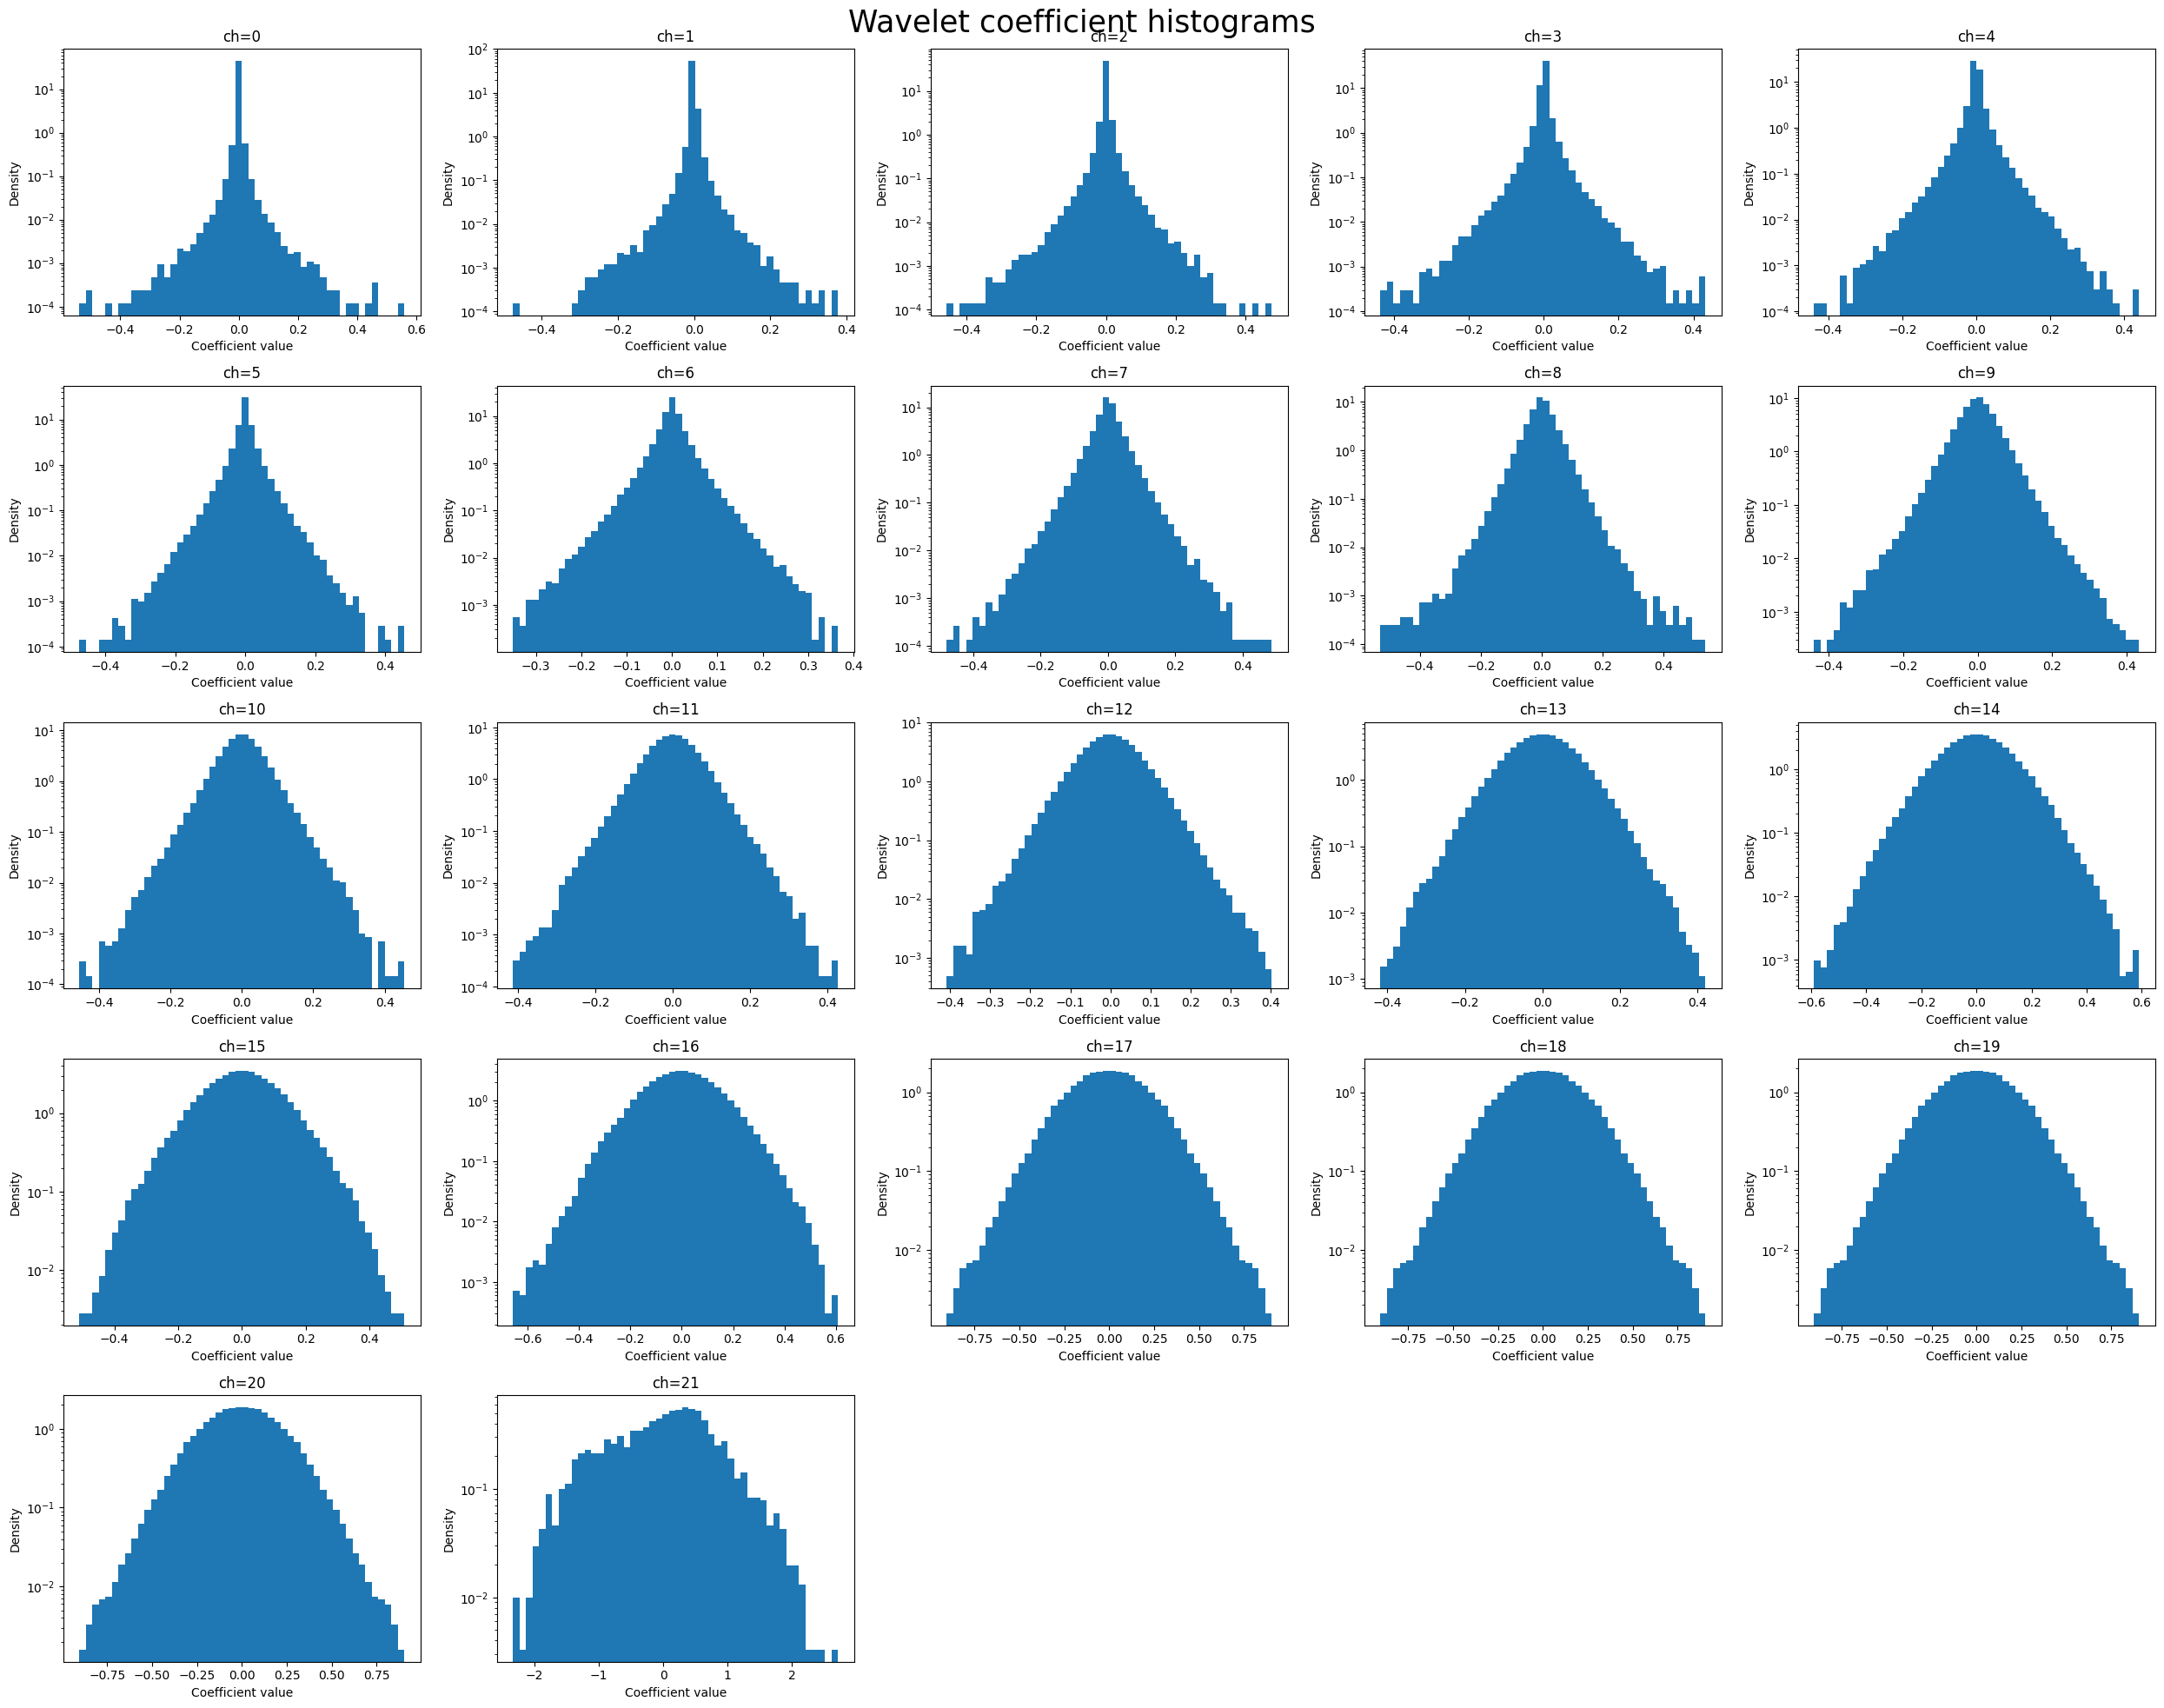

In [29]:
%matplotlib inline 
wt = torch.fft.ifft(torch.fft.fft(x1) * filters_Q).real  # (B, J, T)
print(wt.shape) 
n_wavelets = filters_Q.shape[1]
# ------------------------------------------------------------------
# 1. Overview grid
# ------------------------------------------------------------------
ncols = 5
nrows = math.ceil(n_wavelets / ncols)
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = axes.flatten()
for i in range(n_wavelets):
    vals = wt[:, i, :].detach().cpu().flatten().numpy()
    axes[i].hist(vals, bins=50, density=True, log=True)
    axes[i].set_title(f"ch={i}")
    axes[i].set_xlabel("Coefficient value")
    axes[i].set_ylabel("Density")
for j in range(n_wavelets, len(axes)):
    axes[j].axis("off")
plt.suptitle(f"Wavelet coefficient histograms", fontsize=25)
plt.tight_layout()
plt.show()

## Run or load an experiment

Set `FORCE_RERUN = True` if you want to recompute samples even when saved results already exist.

The standard outputs are saved with your existing `save_results(...)`. In addition, this notebook saves a small auxiliary `.pt` file containing `barphi_e` and `barphi_p`, because these are useful for plotting moment matching after reloading.


## Define and run experiments 

In [35]:
t[-72:]

tensor([0.9999, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000,
        1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000, 1.0000])

In [6]:
potentials_dir = exp_dir / 'fitted_potentials'
result = run_experiment(args, M, config, x1, filters, t[:-72], 
                        logger, root, device=device, 
                        filters_Q=filters_Q, filters_Phi=filters_Phi, 
                        potentials_save_dir=potentials_dir,
                       ) 

2026-07-29 16:19:42  INFO      Loaded existing results for turbulencesynth_M256_J8_Q3_sigma3.5_nt40000_n1_5000_lam5e-07_seed_300_terms2f1130a8_20260728_1232


In [7]:
# save reg thetas 
theta_reg_t = result['Theta_reg']
theta_reg_t.shape 

torch.Size([197, 272])

## Check fits 

In [ ]:
FITTED_DIR = potentials_dir
Q = 3

with torch.no_grad():
    filters = return_Filters(M, J, 1, device=device)
    potentials = get_1d_potentials(
        terms, J, filters, Q, filters_Q, filters_Phi,
        scalar_param=None, parallel=False,
    )
    sizes = [p.num_coefficients for p in potentials.values()]
    print(f"Total potential features: {sum(sizes)}")

    evaluated_features = []
    for name, p in potentials.items():
        p.to(device)
        state_path = FITTED_DIR / f"{name}.pt"

        if hasattr(p, "is_fitted"):
            own_filters = p.filters  # whichever bank THIS potential was built with
            if state_path.exists():
                p = type(p).load_fixed_parameters(state_path, own_filters, map_location=device)
                p.to(device)
                potentials[name] = p
                print(f"[{name}] loaded fitted state: {p.num_coefficients} active statistics")
            else:
                p.fit_reference(x1)
                p.save_fixed_parameters(state_path)
                print(f"[{name}] fit fresh and saved: {p.num_coefficients} active statistics")

        feat = p(x1)
        if feat.ndim == 1:
            feat = feat.unsqueeze(1)
        evaluated_features.append(feat)

    phi_X = torch.cat(evaluated_features, dim=-1)
    print(f"Total potential features after fitting: {phi_X.shape[-1]}")

Total potential features: 311
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-16205911  K2=-16326488  K3=-16348547  K4=-16349085)
[GGD^4][ch 0] Keff=4  cuts=[0.0002 0.0007 0.0054]  pi=[45.8% 44.0% 9.7% 0.5%]  alpha=[1.96 0.79 0.41 0.41]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-16491472  K2=-16634391  K3=-16660426  K4=-16661796)
[GGD^4][ch 1] Keff=4  cuts=[0.0002 0.0006 0.0070]  pi=[66.9% 22.7% 9.9% 0.5%]  alpha=[1.61 0.41 0.39 0.41]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-15401259  K2=-15555130  K3=-15569726  K4=-15573686)
[GGD^4][ch 2] Keff=4  cuts=[0.0003 0.0012 0.0131]  pi=[66.4% 23.1% 9.9% 0.6%]  alpha=[1.49 0.38 0.37 0.41]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-14014799  K2=-14124933  K3=-14137468  K4=-14140422)
[GGD^4][ch 3] Keff=4  cuts=[0.0005 0.0026 0.0258]  pi=[66.0% 23.4% 10.0% 0.6%]  alpha=[1.19 0.35 0.38 0.42]  active=4


In [36]:
state_path

PosixPath('saved_results/Scattering_Fourth_Order_Mod2_Imag_Q1.pt')

## Fit check 

In [10]:
root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from potentials.potentials_classes.generalized_gauss_Kregions import Scalar_GGD_KRegion

In [11]:
filters = return_Filters(M, J, 1, device=device, include_phi=False)
model1= Scalar_GGD_KRegion(filters)
model1.fit_reference(x1)

    [model-select] chose K=3  (Kmax=4)  (BIC: K1=-2317987  K2=-2330567  K3=-2332021  K4=-2332016)
[GGD^4][ch 0] Keff=3  cuts=[0.0000 0.0027 0.0739]  pi=[0.0% 39.3% 58.5% 2.2%]  alpha=[1.00 1.38 0.34 0.43]  active=3
    [model-select] chose K=3  (Kmax=4)  (BIC: K1=-1858462  K2=-1865742  K3=-1865843  K4=-1865777)
[GGD^4][ch 1] Keff=3  cuts=[0.0000 0.0090 0.1079]  pi=[0.0% 53.3% 44.4% 2.3%]  alpha=[1.00 1.17 0.36 0.68]  active=3
    [model-select] chose K=3  (Kmax=4)  (BIC: K1=-1176965  K2=-1179030  K3=-1179038  K4=-1178994)
[GGD^4][ch 2] Keff=3  cuts=[0.0000 0.0169 0.2731]  pi=[0.0% 39.4% 60.0% 0.6%]  alpha=[1.00 1.61 0.60 1.23]  active=3
    [model-select] chose K=2  (Kmax=4)  (BIC: K1=-784055  K2=-785324  K3=-785288  K4=-785238)
[GGD^4][ch 3] Keff=2  cuts=[0.0000 0.0000 0.0728]  pi=[0.0% 0.0% 66.7% 33.3%]  alpha=[1.00 1.00 1.62 0.89]  active=2
    [model-select] chose K=2  (Kmax=4)  (BIC: K1=-532353  K2=-533110  K3=-533092  K4=-533040)
[GGD^4][ch 4] Keff=2  cuts=[0.0000 0.0000 0.1474] 

/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/turbulence/../codes/potentials/potentials_classes/generalized_gauss_Kregions.py:178: RuntimeWarning: overflow encountered in cast
  logpdf = (np.log(a) - np.log(2.0) - np.log(s) - gammaln(1.0 / a) - (ah / s) ** a)


    [model-select] chose K=4  (Kmax=4)  (BIC: K1=927376  K2=925707  K3=925339  K4=924882)
[GGD^4][ch 7] Keff=4  cuts=[0.5874 1.2203 1.8304]  pi=[53.1% 32.6% 12.3% 2.0%]  alpha=[8.00 1.30 0.49 1.38]  active=4
[active] 22 active statistics (10 dead slots dropped before they can singularize the Gram)
[prune] dropped 0 near-collinear statistic(s); 22 remain


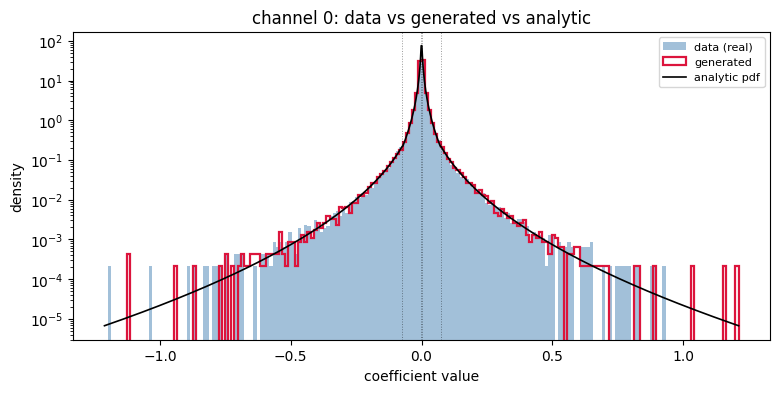

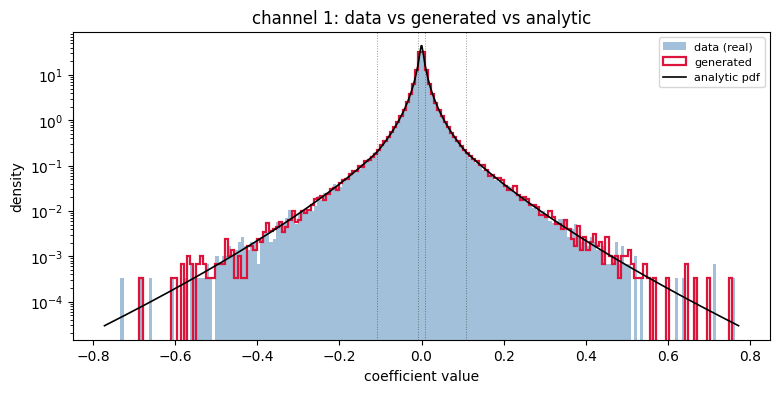

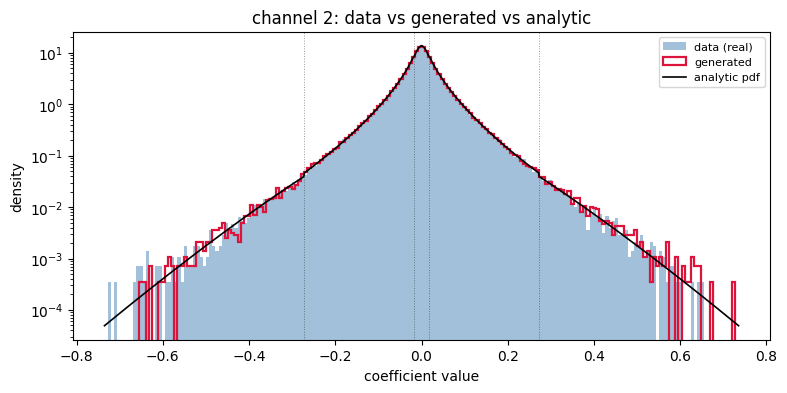

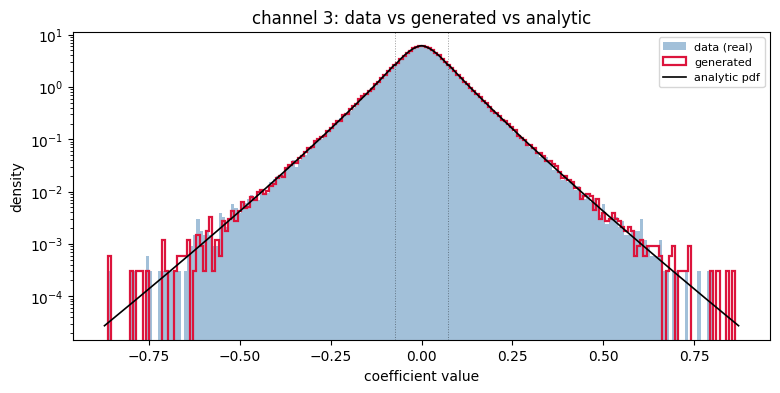

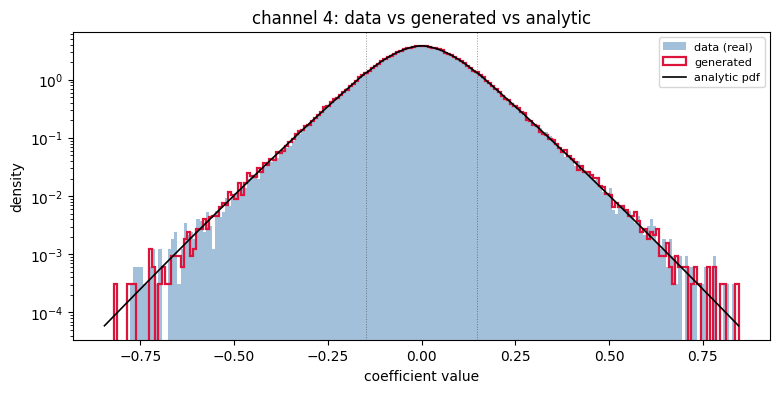

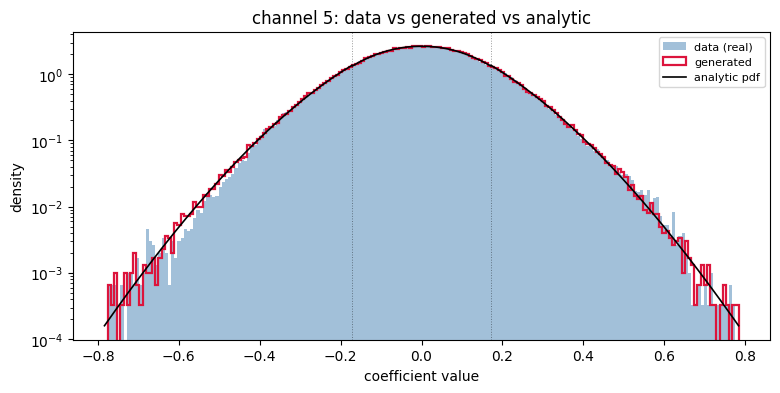

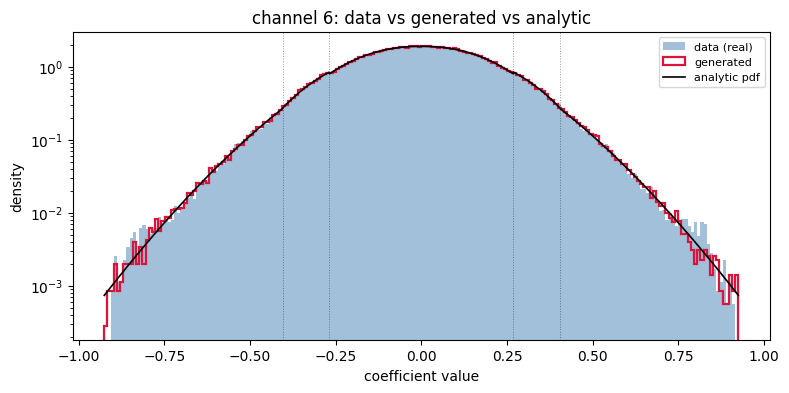

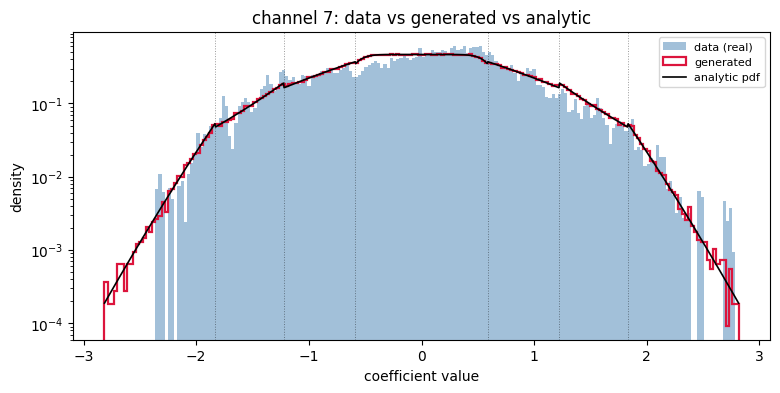

In [12]:
%matplotlib inline 
for i in range (0,filters.shape[1]): 
    model1.compare_channel(x1, j=i)

In [13]:
filtersQ = return_Filters(M, J, 3, device=device, include_phi=False)
print(filtersQ.shape)
model3 = Scalar_GGD_KRegion(filtersQ)
model3.fit_reference(x1)

torch.Size([1, 22, 128])
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-4027535  K2=-4064139  K3=-4068783  K4=-4069589)
[GGD^4][ch 0] Keff=4  cuts=[0.0005 0.0015 0.0062]  pi=[59.7% 21.4% 13.2% 5.7%]  alpha=[1.40 0.36 0.36 0.38]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-3852025  K2=-3868739  K3=-3871998  K4=-3872672)
[GGD^4][ch 1] Keff=4  cuts=[0.0002 0.0008 0.0083]  pi=[38.7% 25.6% 30.1% 5.6%]  alpha=[1.52 0.33 0.34 0.39]  active=4
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-3276841  K2=-3281218  K3=-3282998  K4=-3283318)
[GGD^4][ch 2] Keff=4  cuts=[0.0002 0.0019 0.0309]  pi=[18.5% 45.7% 33.6% 2.2%]  alpha=[1.56 0.29 0.35 0.42]  active=4
    [model-select] chose K=2  (Kmax=4)  (BIC: K1=-2741834  K2=-2743711  K3=-2743582  K4=-2743697)
[GGD^4][ch 3] Keff=2  cuts=[0.0000 0.0000 0.0004]  pi=[0.0% 0.0% 18.5% 81.5%]  alpha=[1.00 2.38 1.19 0.31]  active=2
    [model-select] chose K=4  (Kmax=4)  (BIC: K1=-2299768  K2=-2300975  K3=-2300918  K4=-2301028)
[GGD^4][ch 4] 

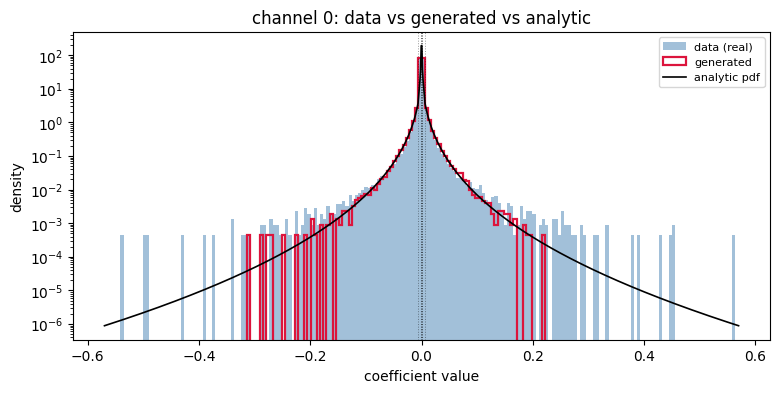

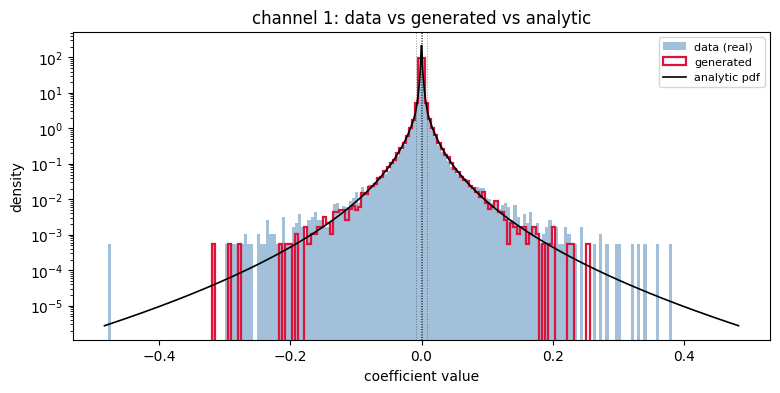

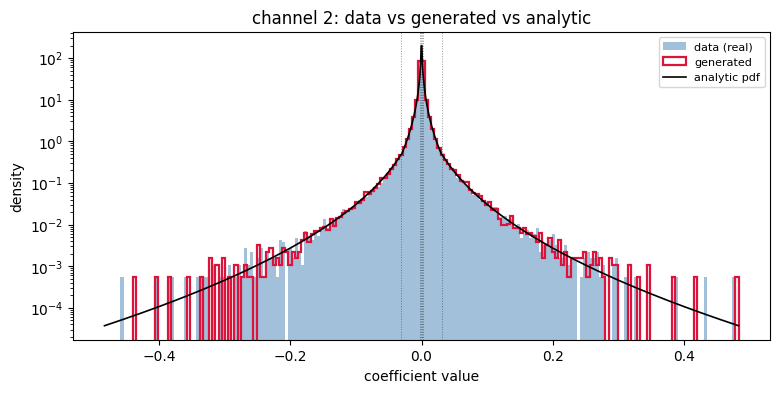

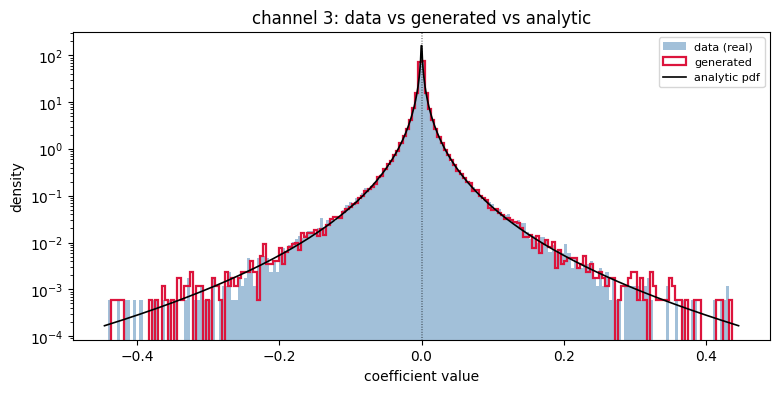

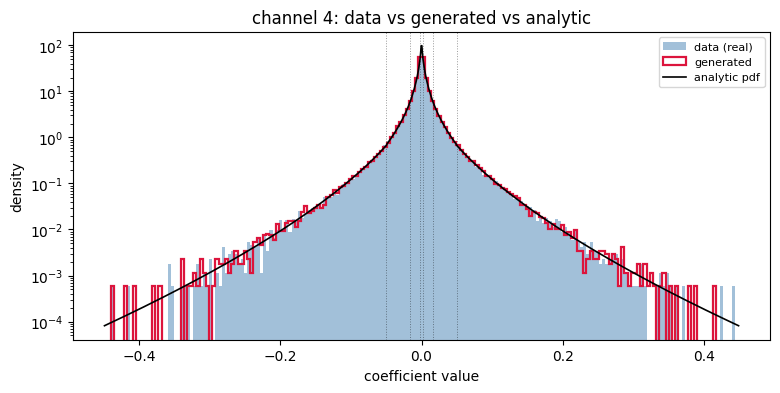

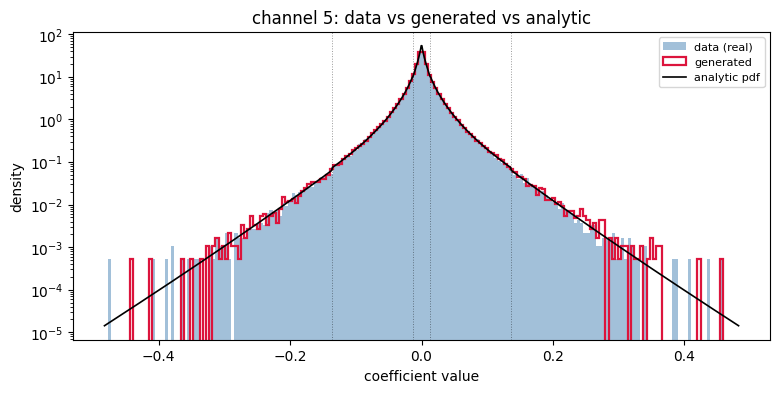

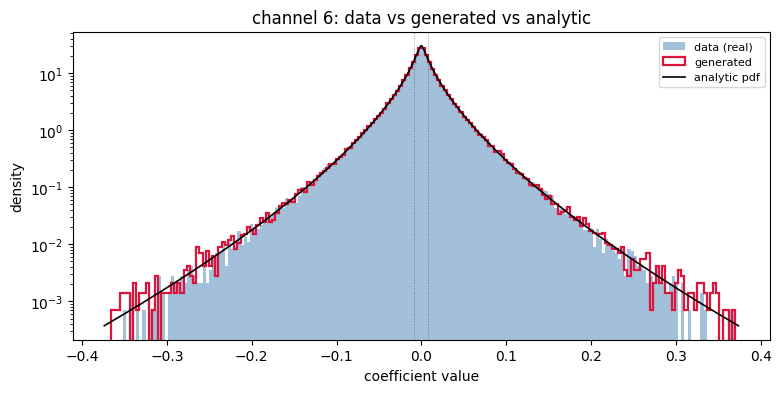

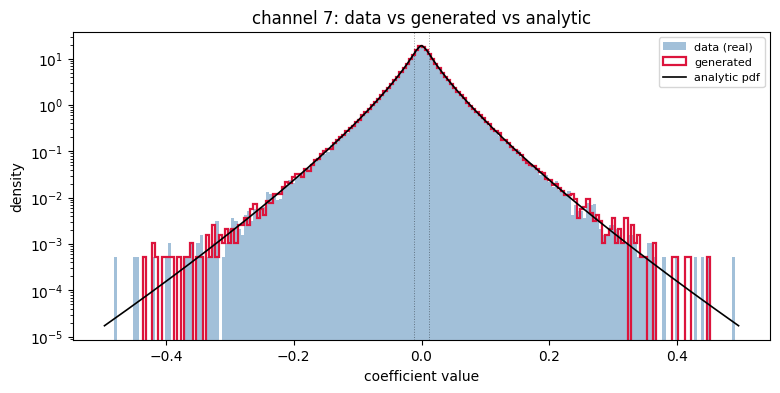

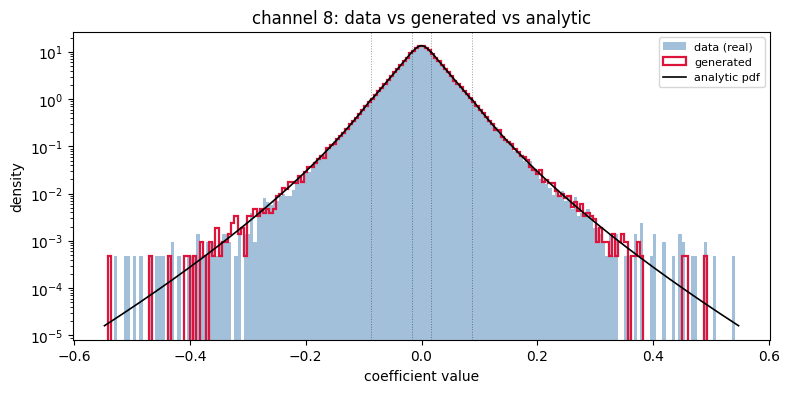

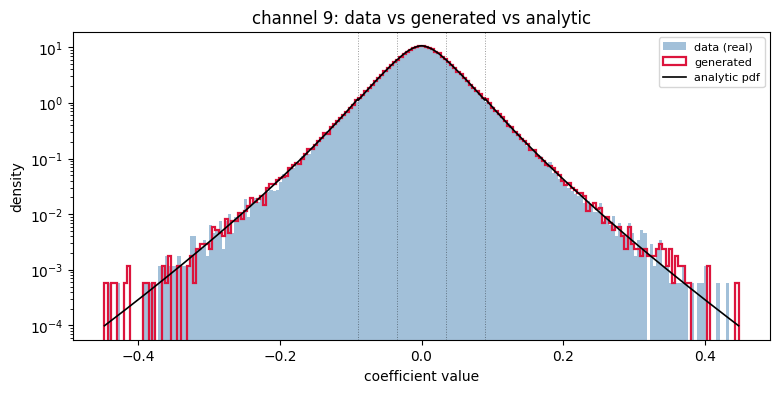

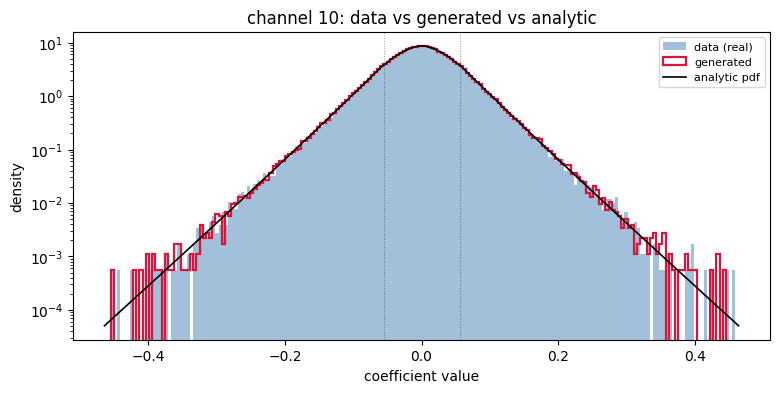

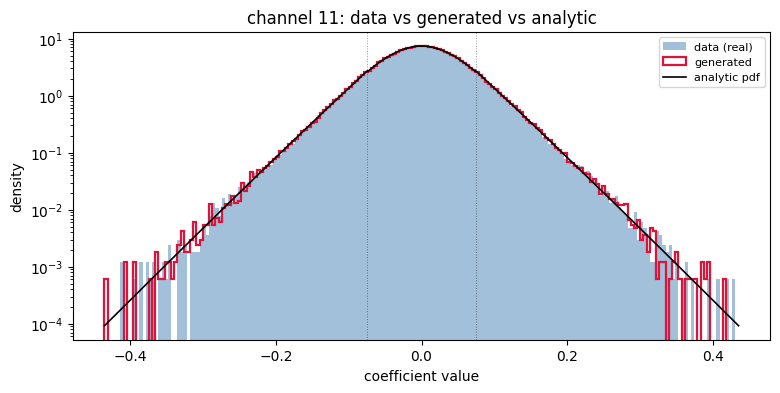

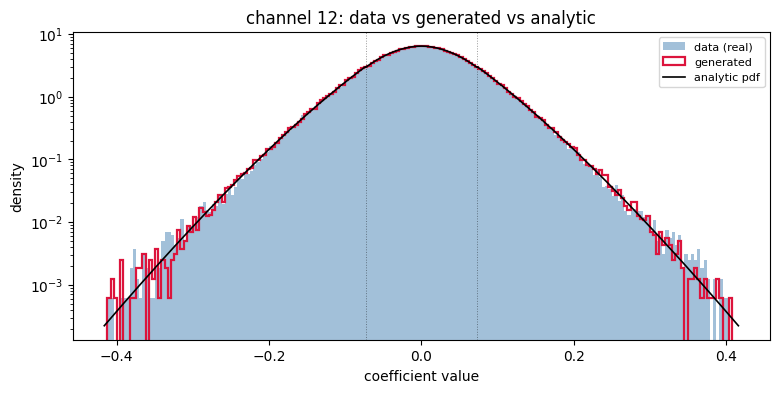

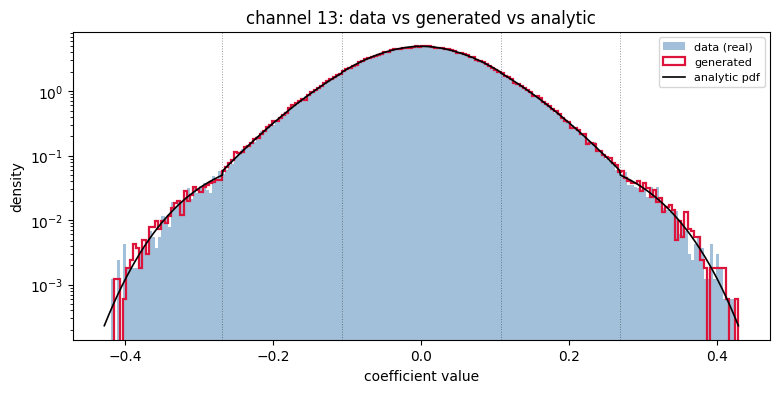

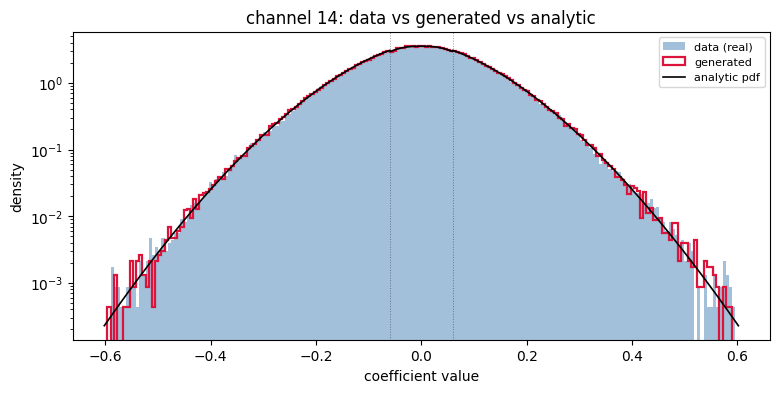

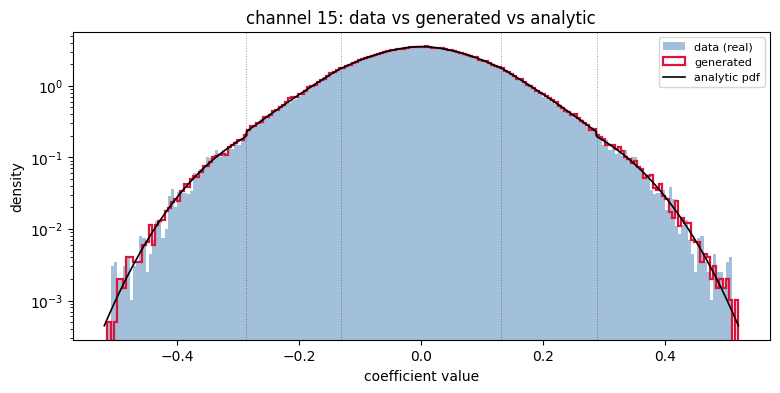

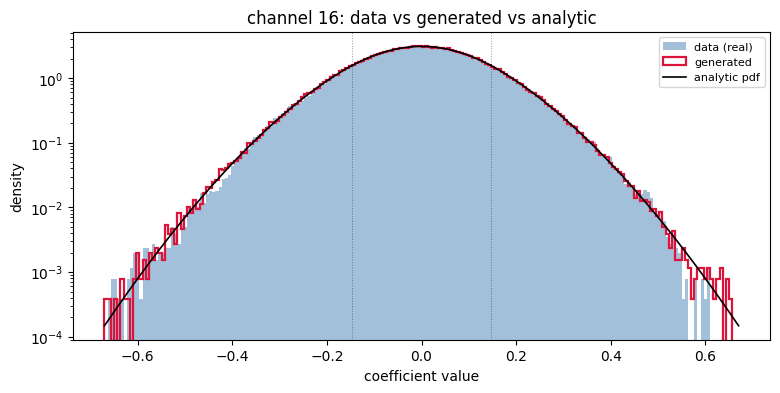

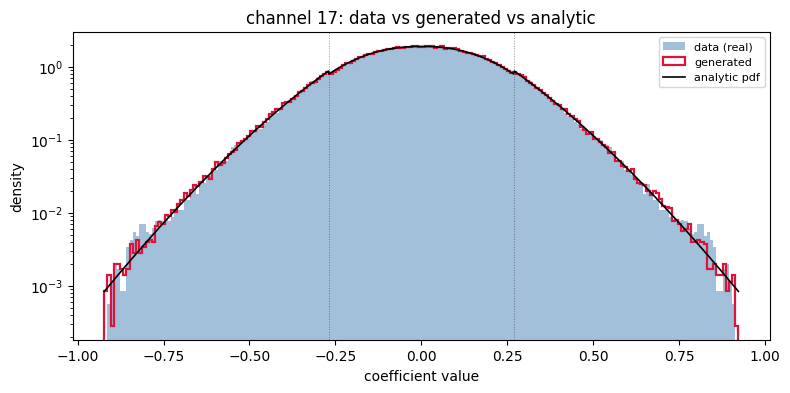

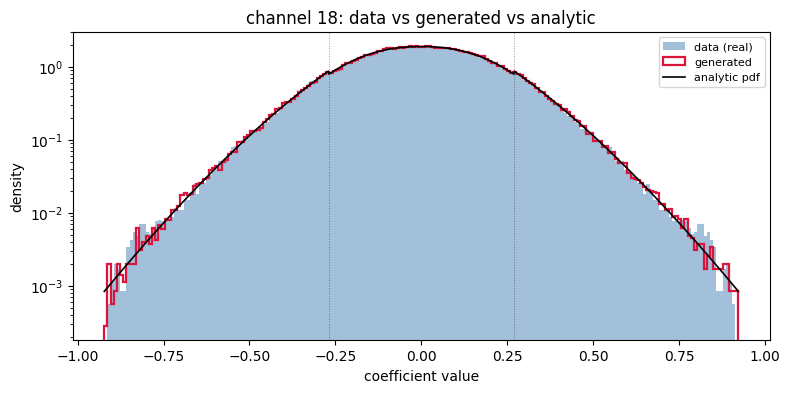

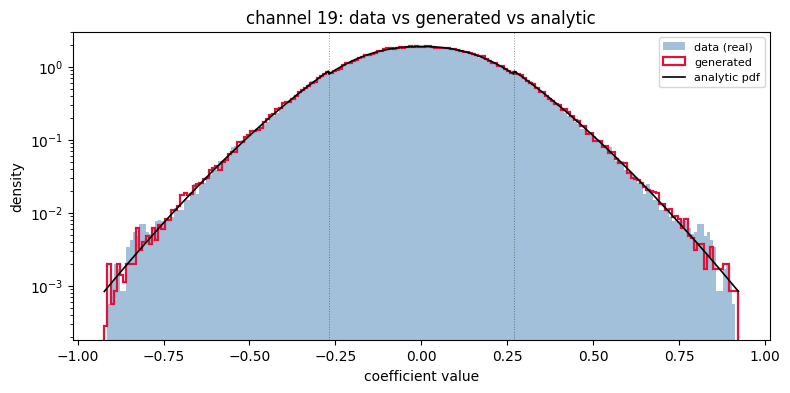

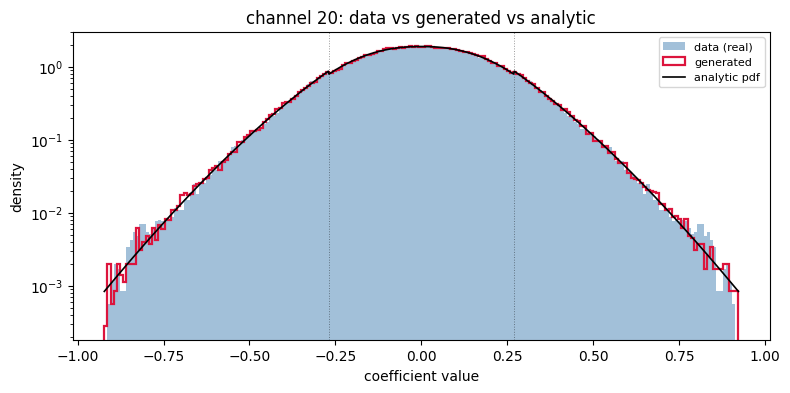

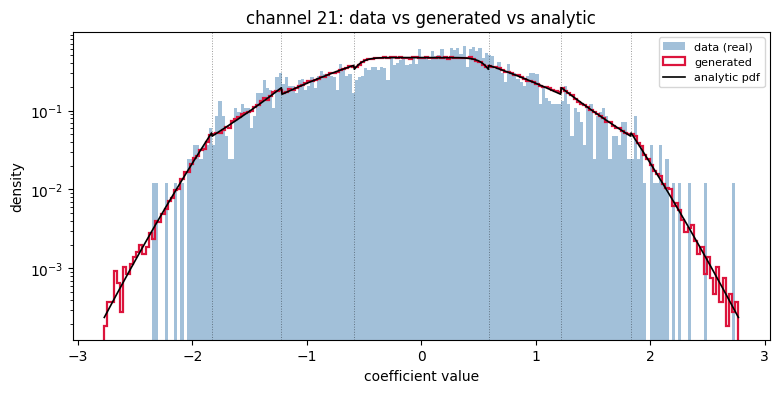

In [14]:
%matplotlib inline 
for i in range(0,filtersQ.shape[1]): 
    model3.compare_channel(x1, j=i)

## Analyze results 

In [8]:
theta_t = result['theta_t']
print(theta_t.shape, theta_t.device)
theta_reg_t = result['Theta_reg']

torch.Size([39704, 272]) cpu


In [9]:
theta_reg_t[:,5]

tensor([ 1.1721e+03, -1.3209e+03,  3.6647e+03,  1.0016e+04,  9.5234e+03,
         6.3595e+03,  1.4163e+04,  5.4391e+03,  1.4289e+04,  1.1909e+04,
         1.2056e+04,  2.7092e+03,  2.4274e+03, -7.2340e+02,  5.6669e+02,
        -4.2725e+03, -5.1840e+03, -5.9172e+02, -9.1561e+02,  7.8506e+02,
         5.7833e+03,  5.0985e+03,  1.7650e+03, -4.6196e+03,  3.2762e+03,
         3.0010e+03, -3.4847e+02,  1.7696e+03, -1.8680e+03, -1.1822e+03,
        -2.0857e+03, -6.1742e+02, -1.2420e+03, -1.0040e+03, -7.2121e+02,
        -5.7046e+02,  7.5859e+02, -6.6591e+02, -1.1815e+03, -1.8571e+02,
        -2.4270e+02,  1.3498e+02,  4.3441e+02, -1.0281e+02,  3.5994e+01,
        -8.4510e+02, -5.1263e+02, -3.7802e+02, -9.1554e+02, -2.1804e+02,
        -1.0495e+03, -6.7360e+02, -4.7059e+02,  1.9937e+02, -3.0084e+02,
         2.7525e+01, -7.3613e+02, -2.0448e+02, -5.3853e+02,  3.4196e+02,
         1.1496e+02, -5.9612e+02, -3.0316e+02, -3.7055e+02, -1.4720e+02,
        -5.1800e+02, -2.4855e+02, -2.9590e+02, -3.0

## Coarse grain 

9927 197


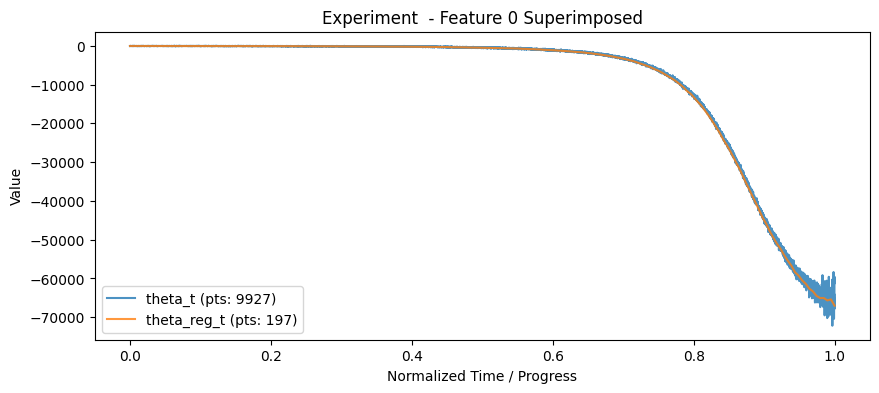

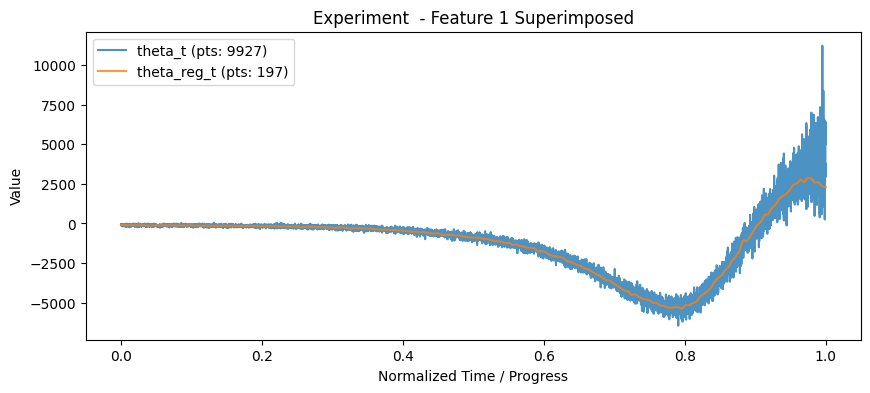

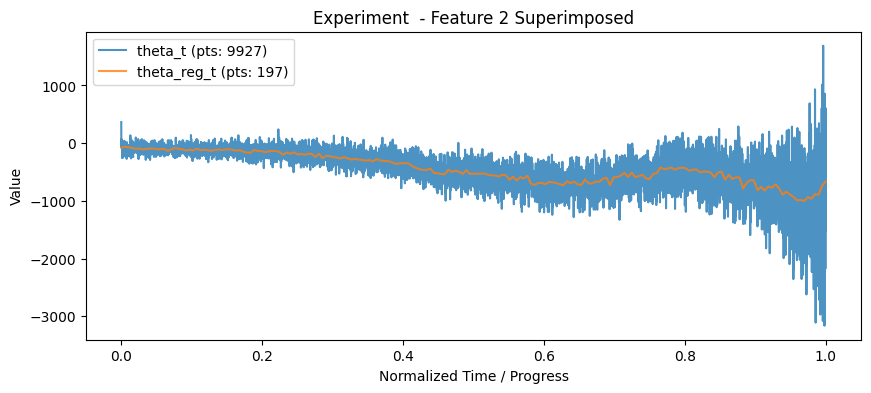

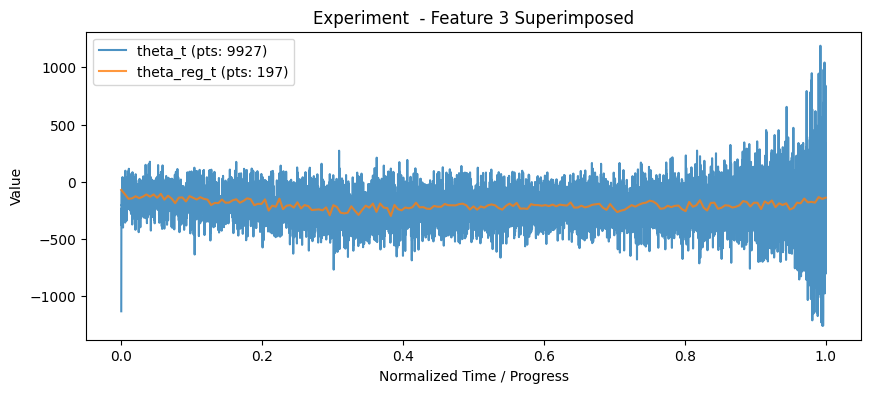

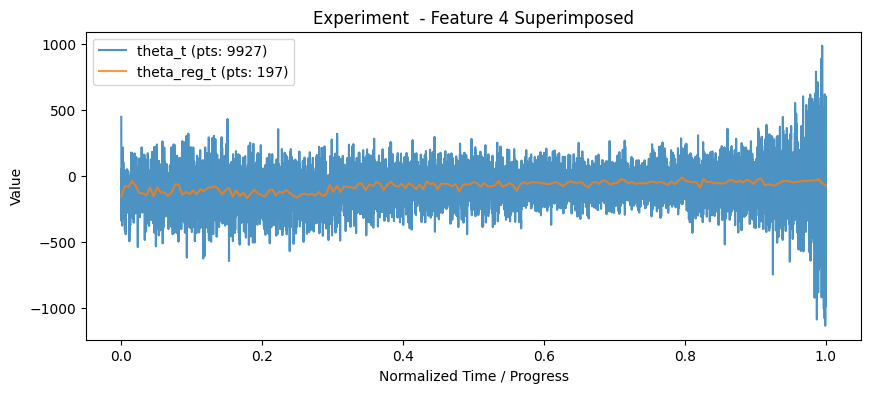

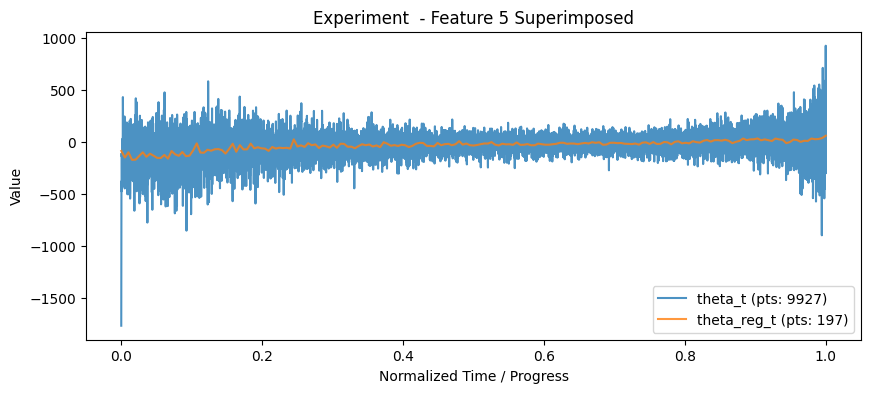

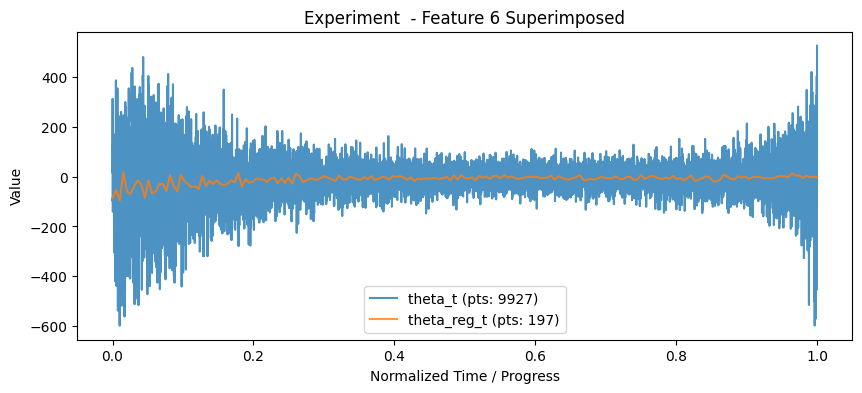

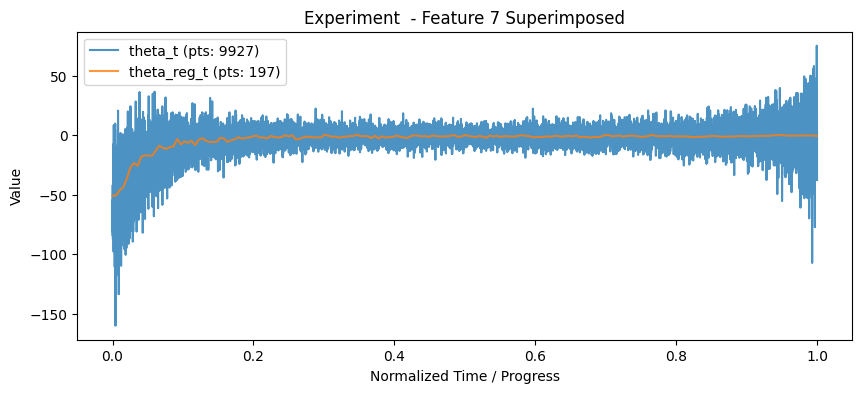

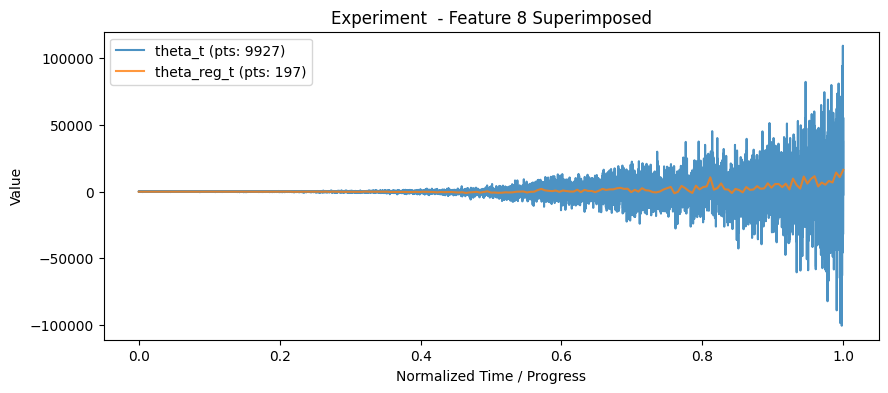

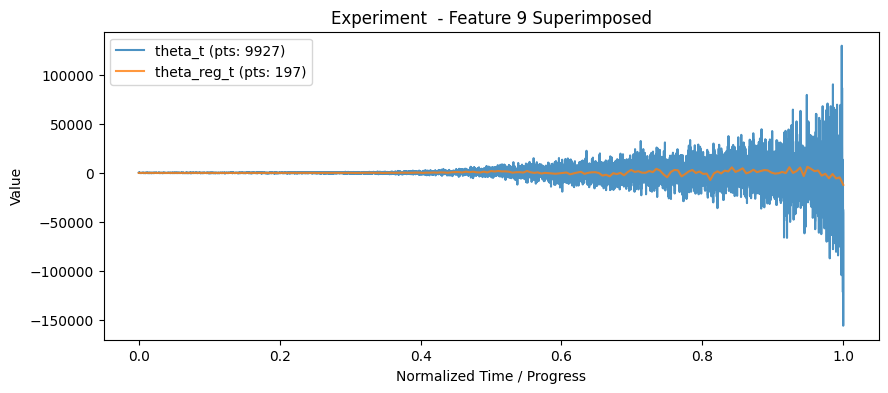

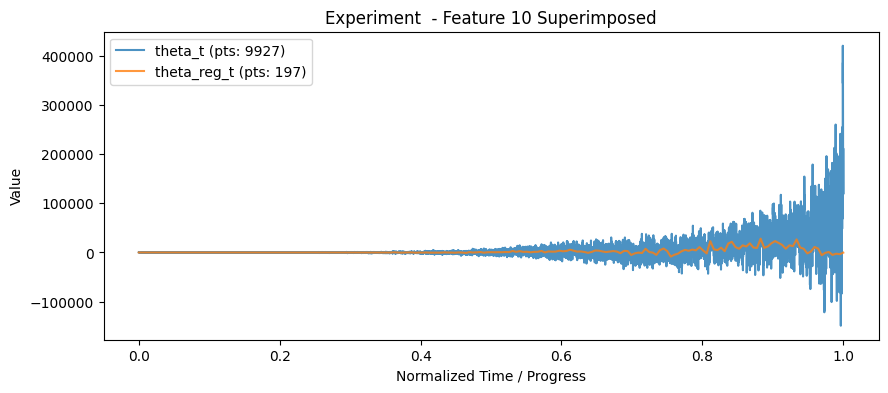

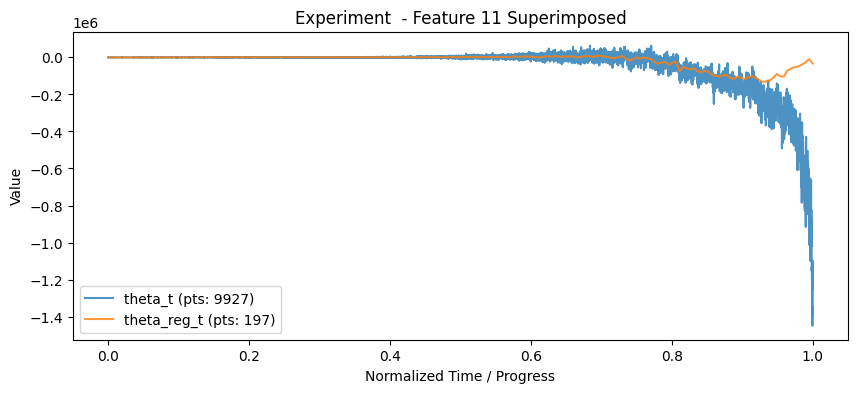

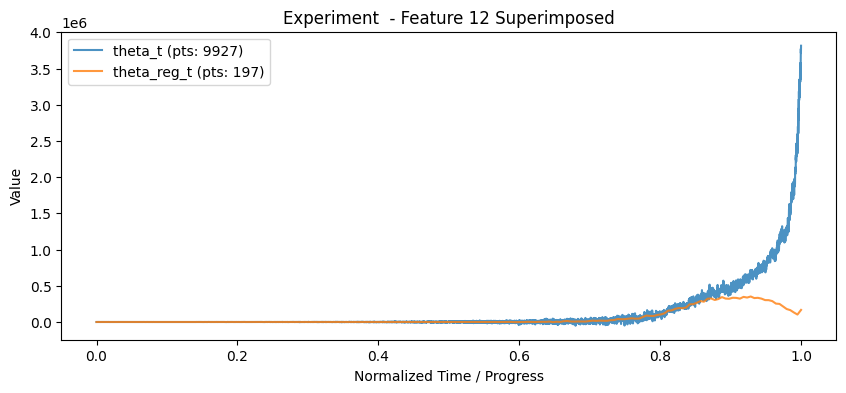

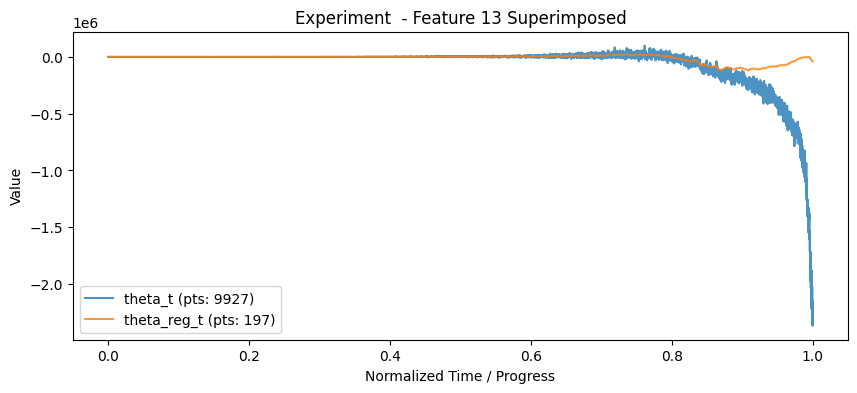

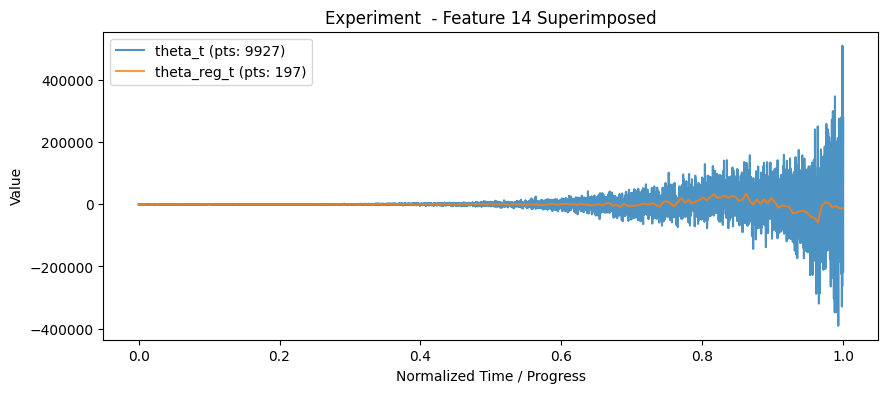

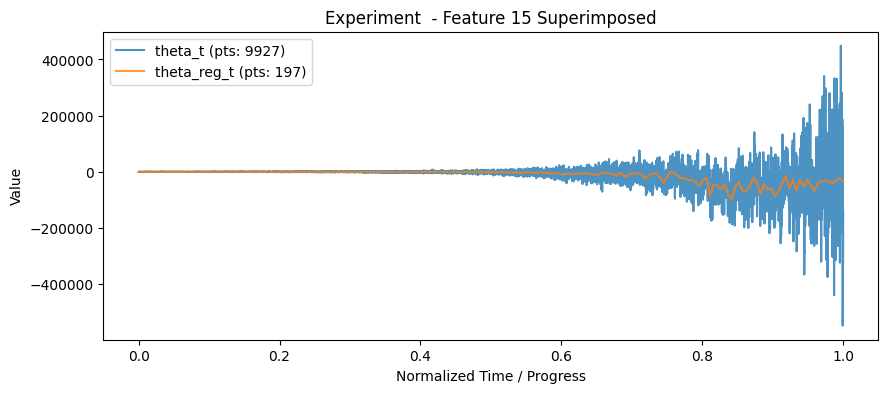

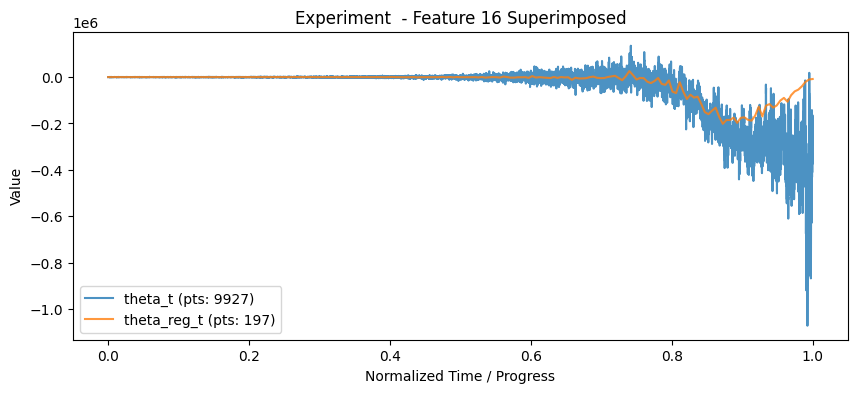

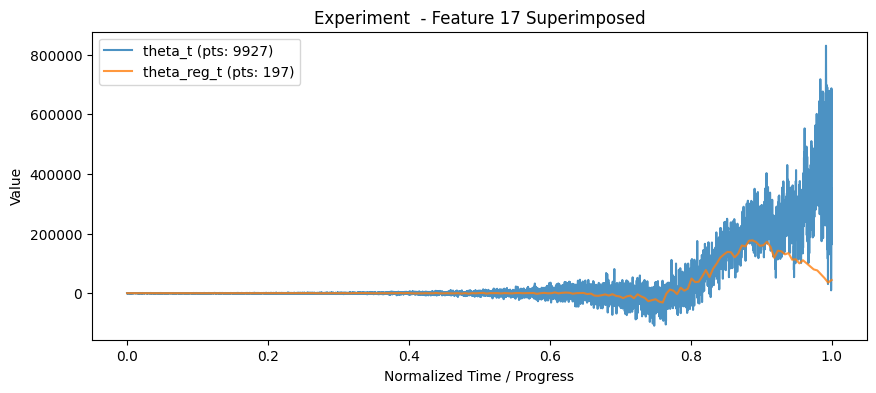

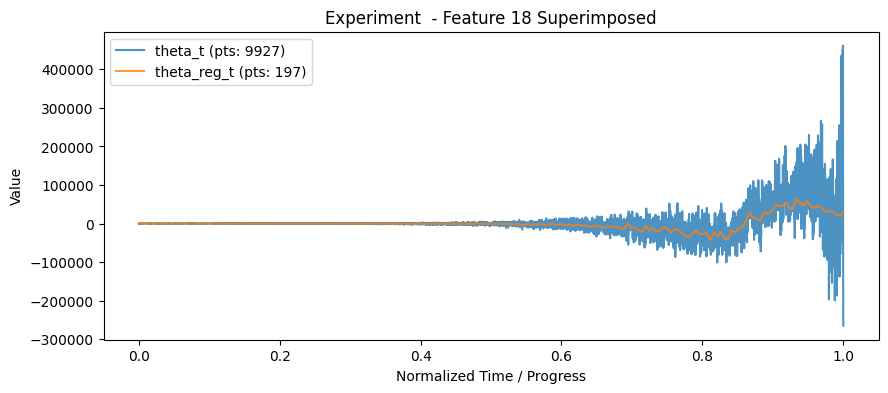

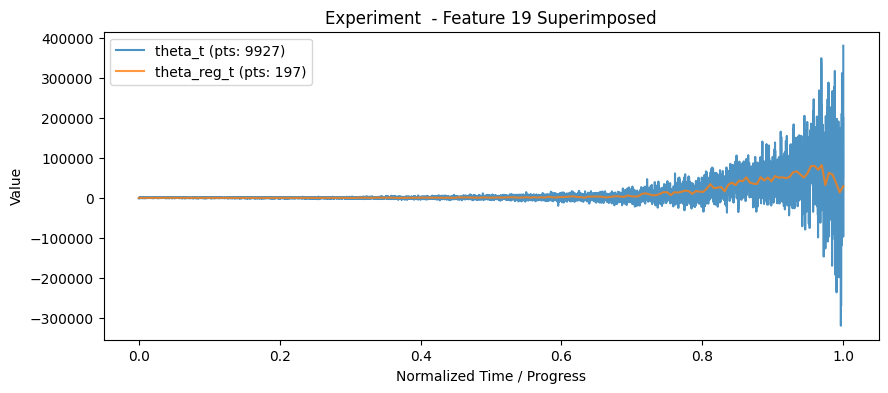

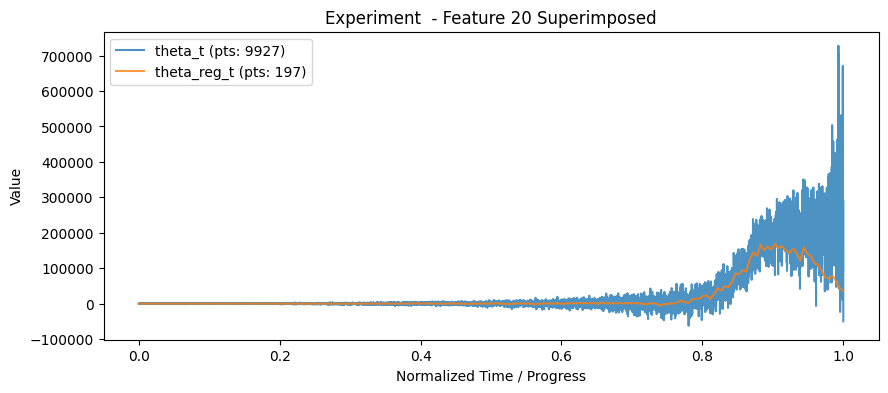

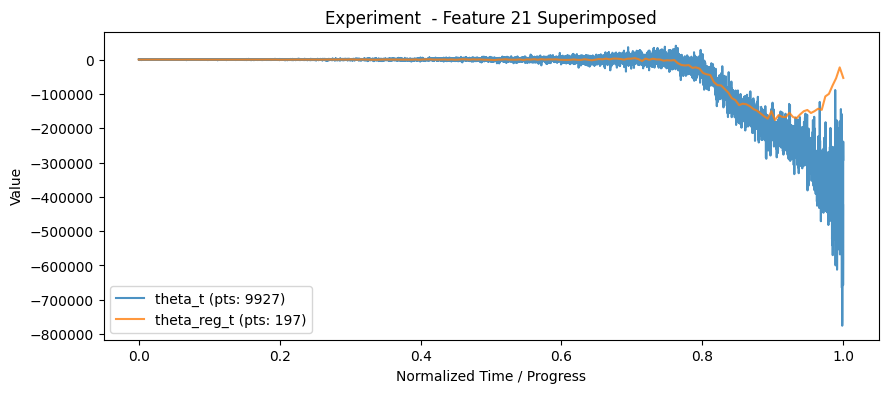

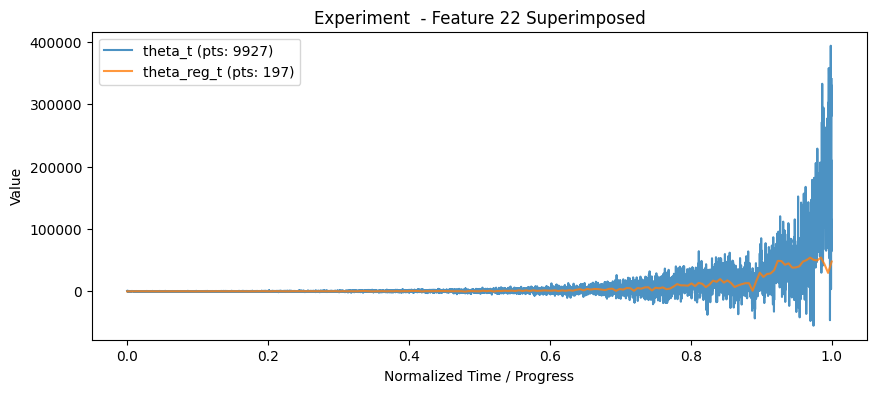

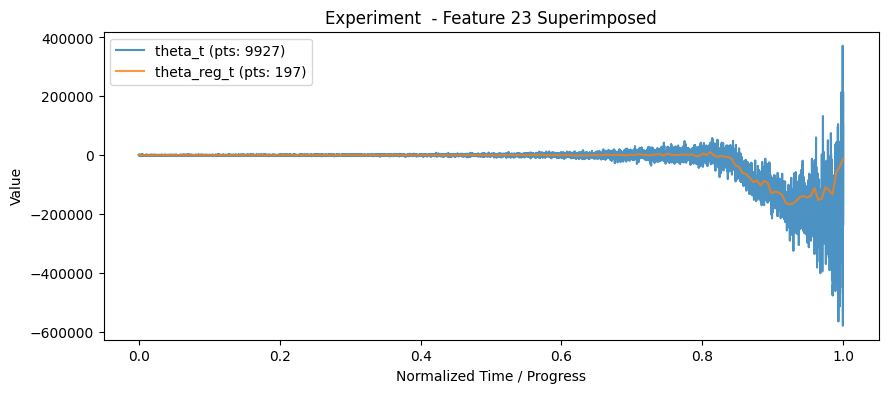

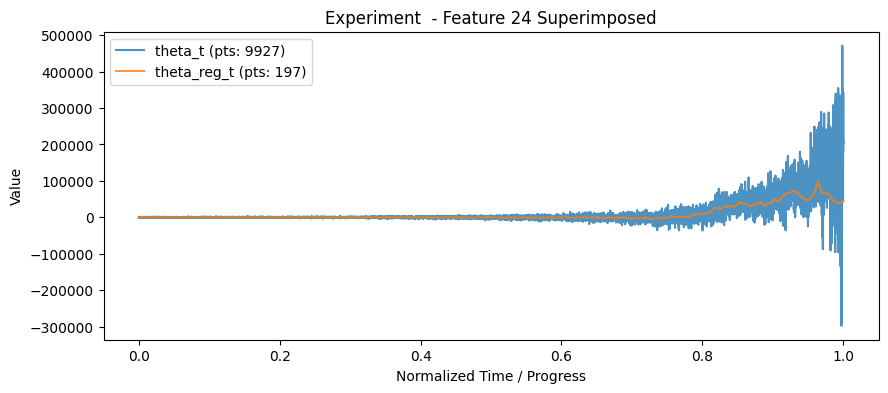

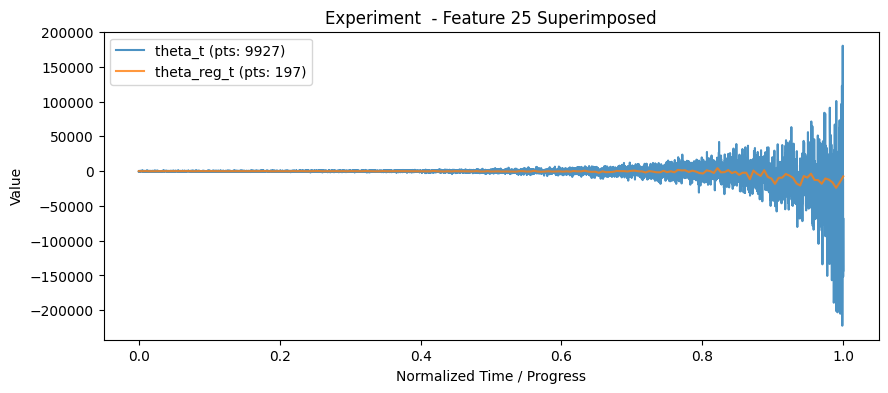

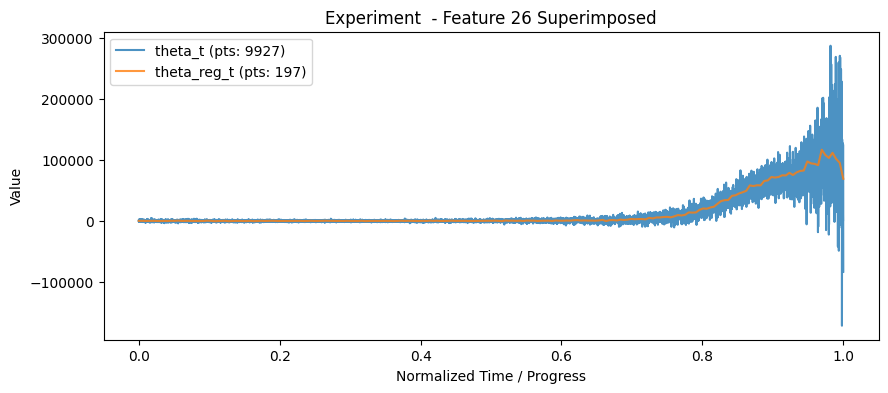

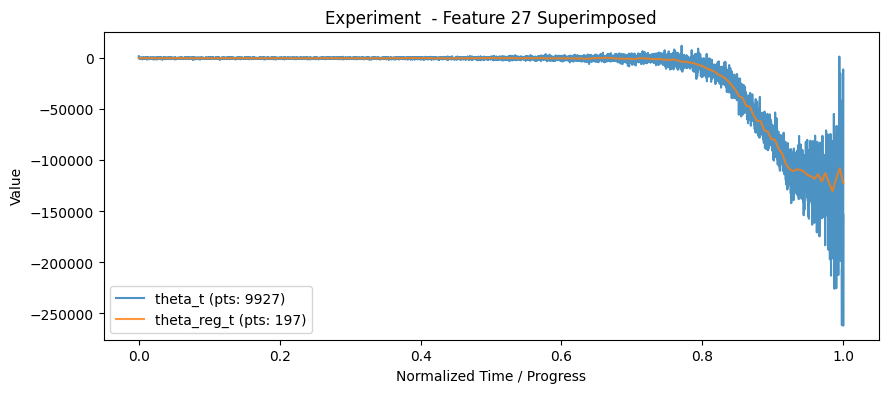

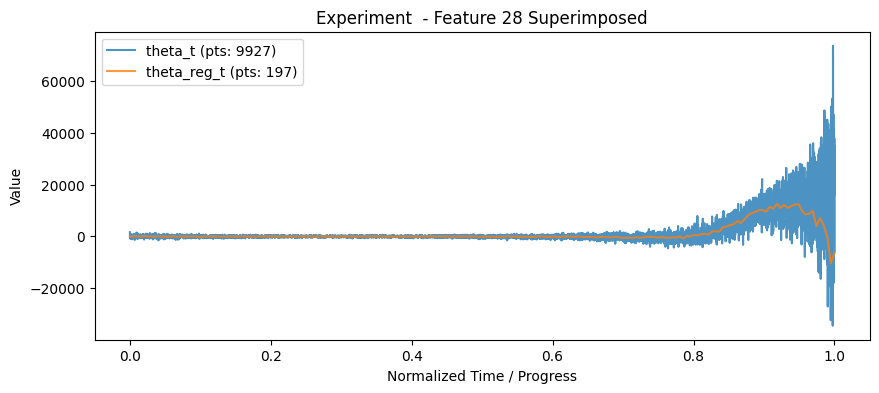

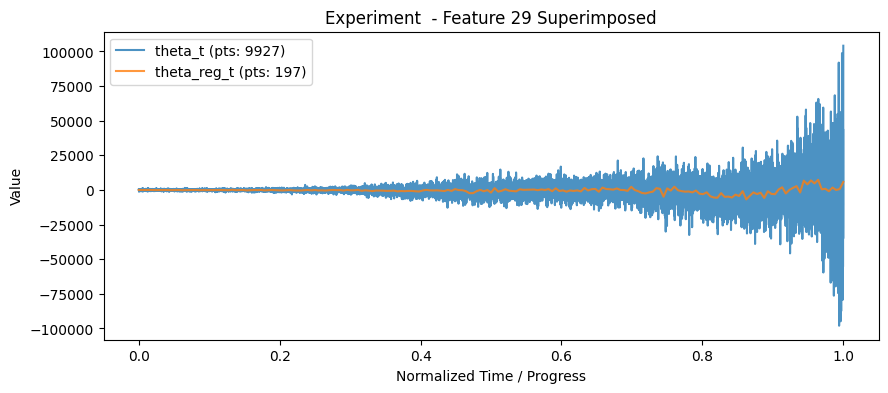

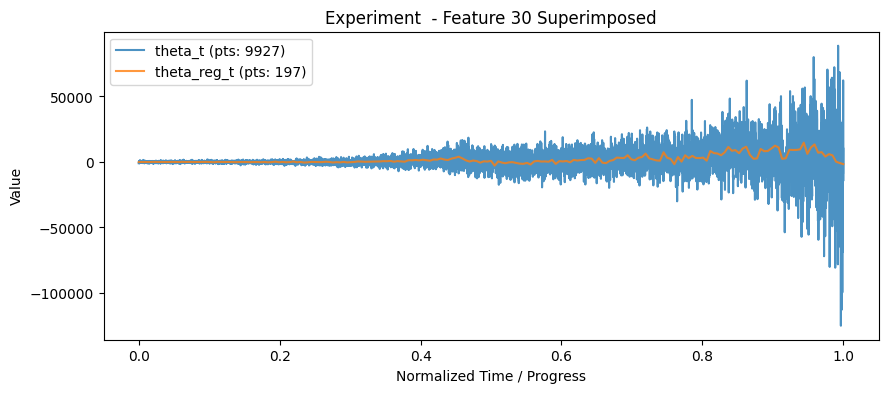

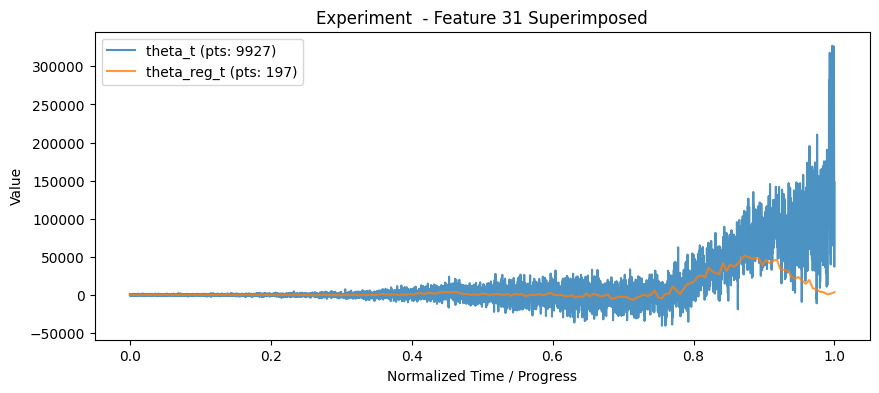

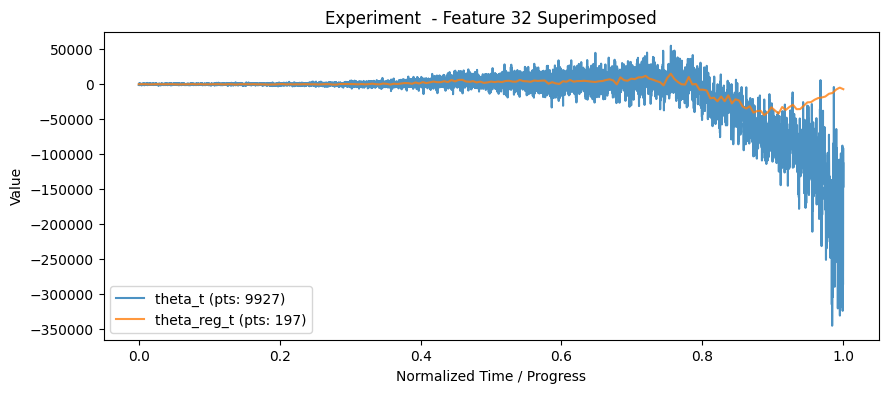

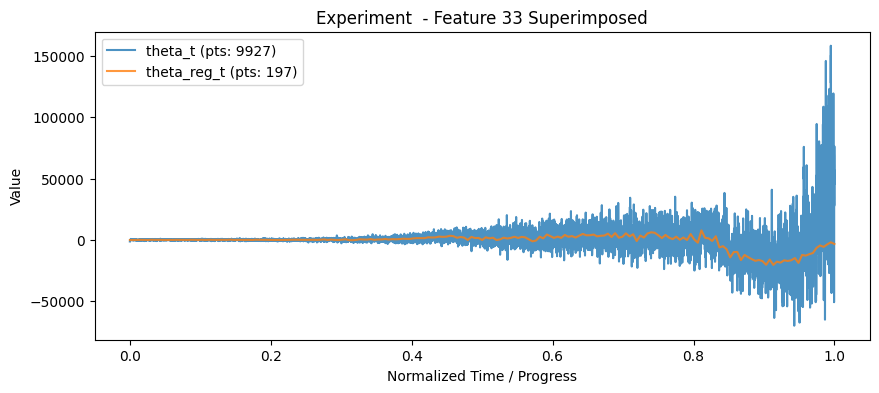

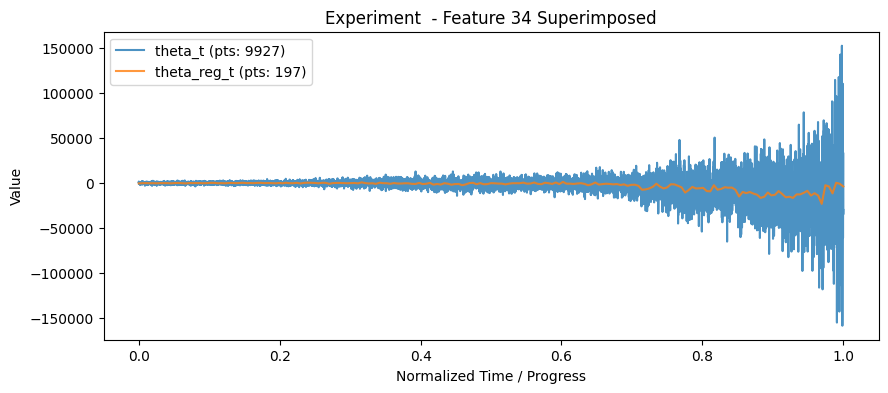

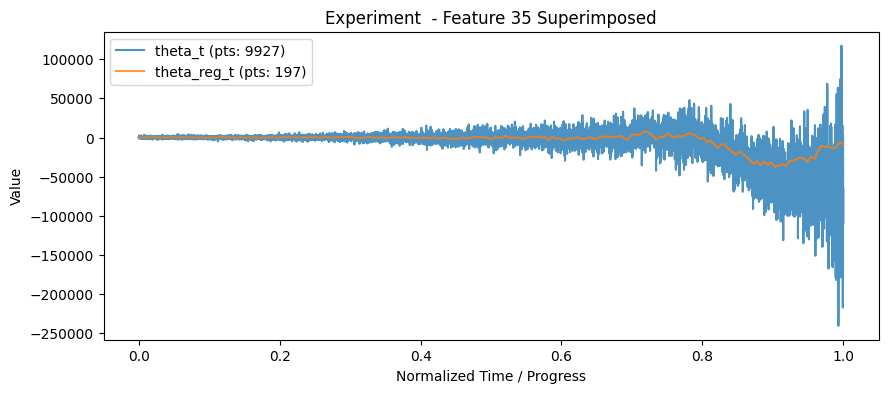

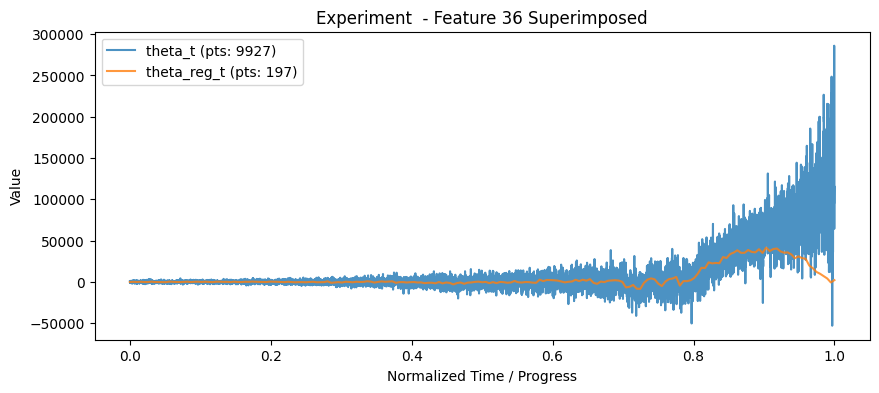

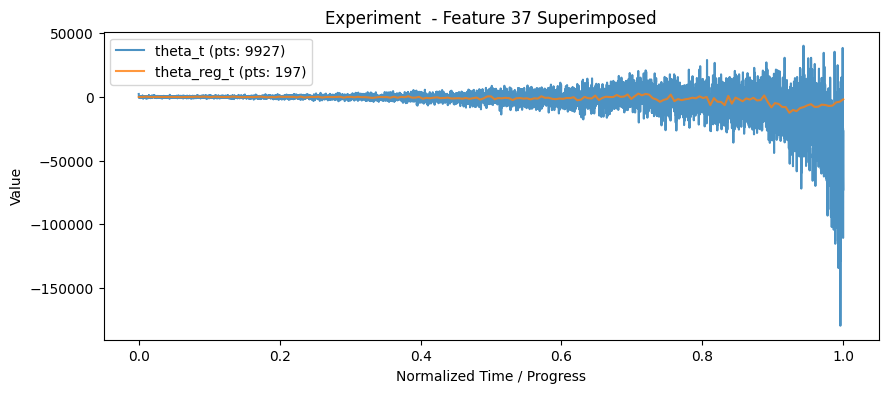

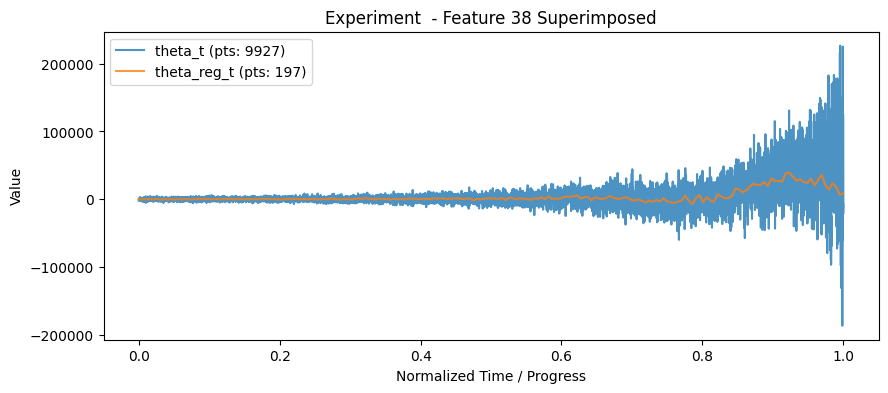

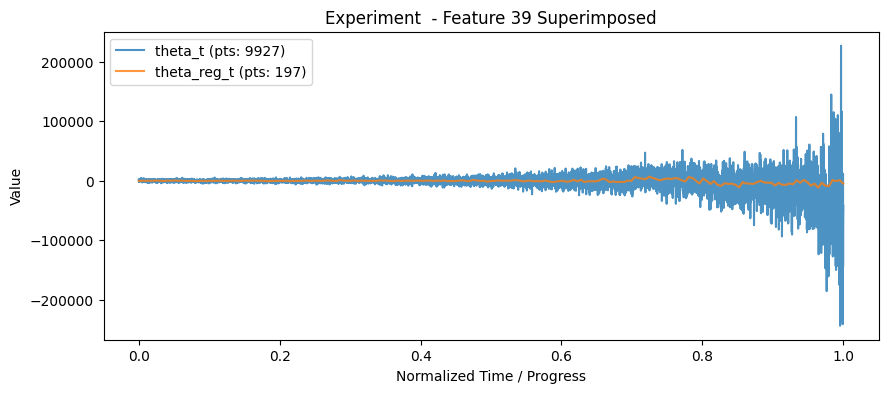

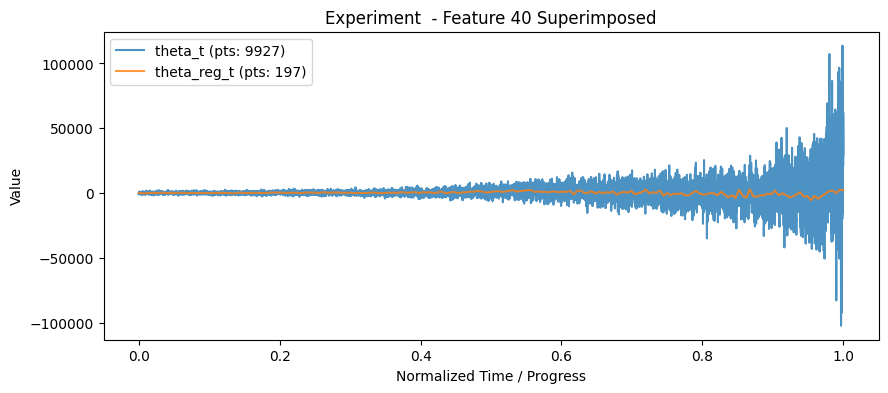

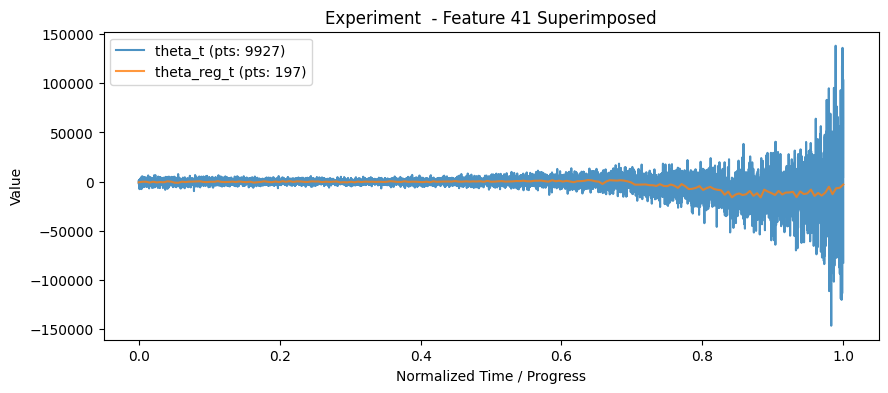

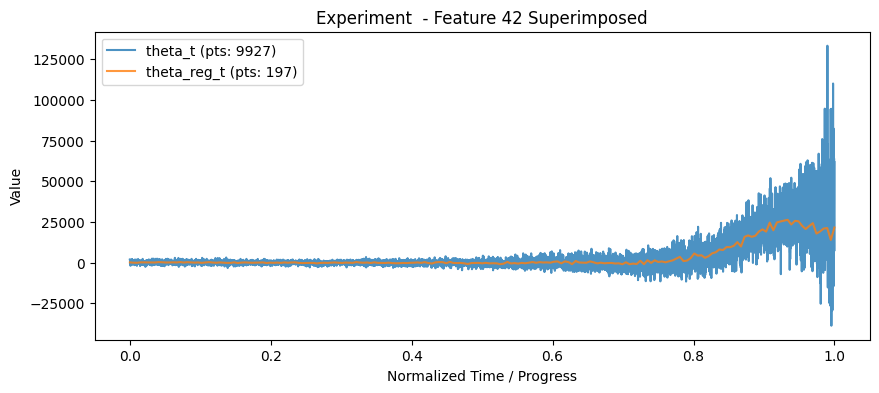

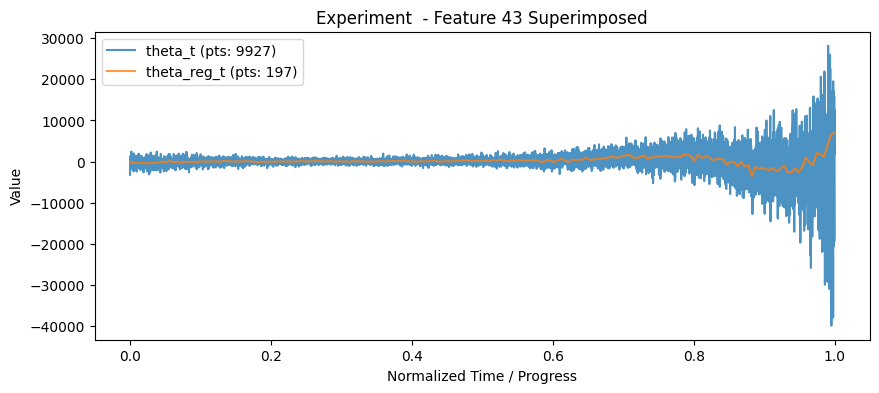

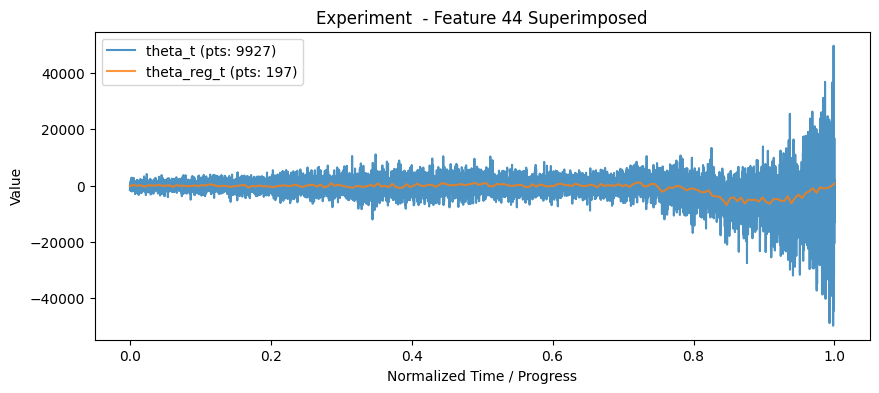

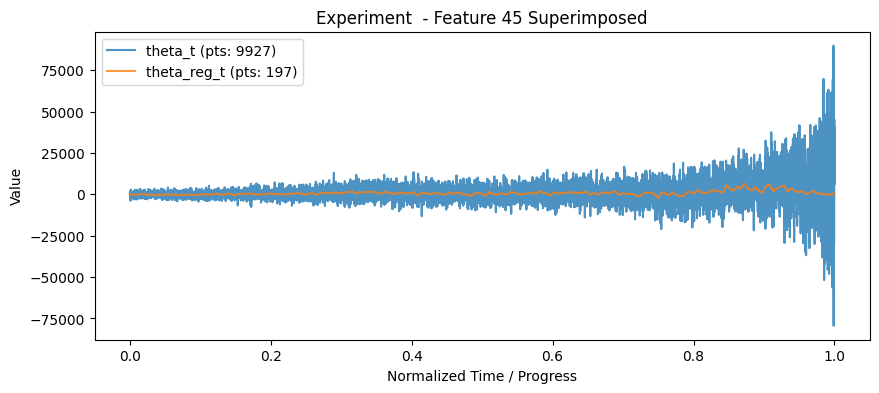

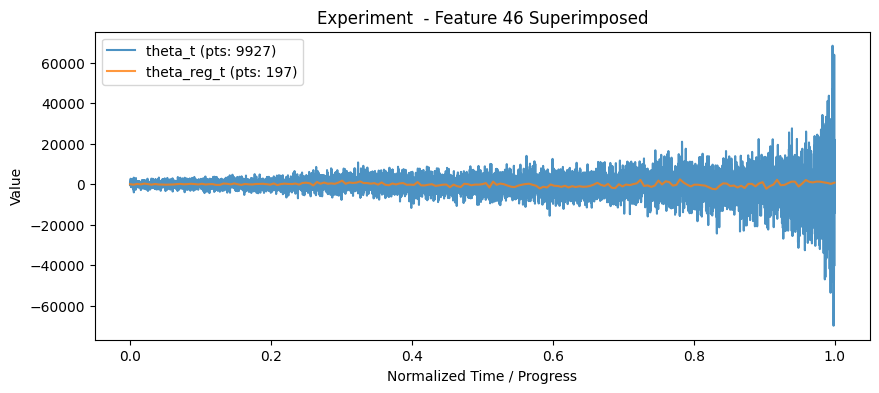

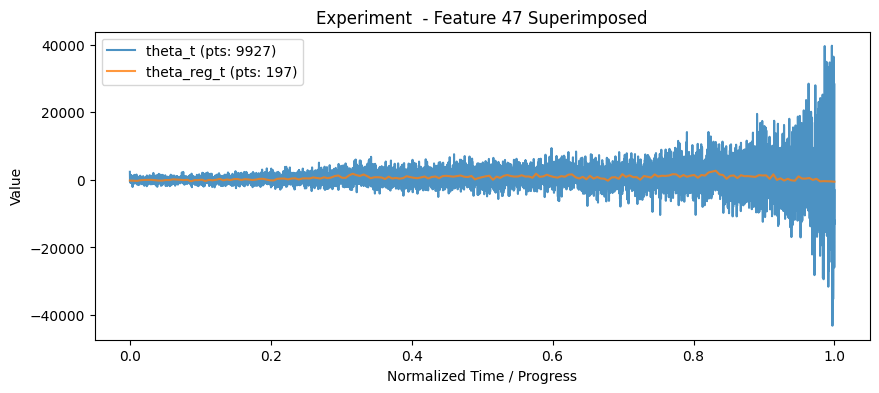

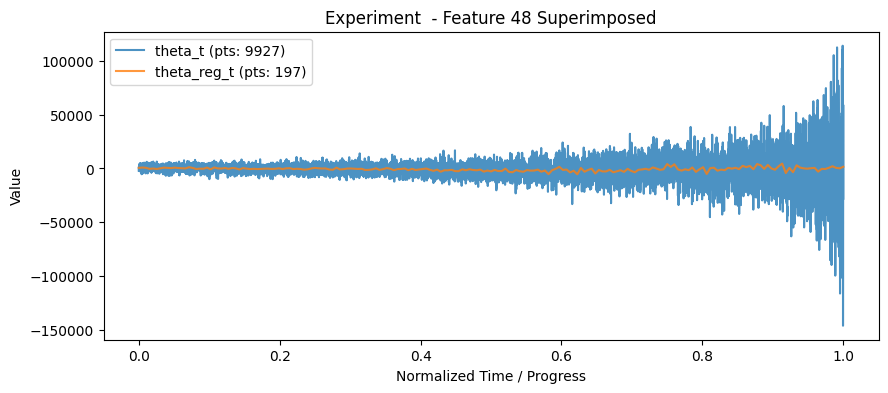

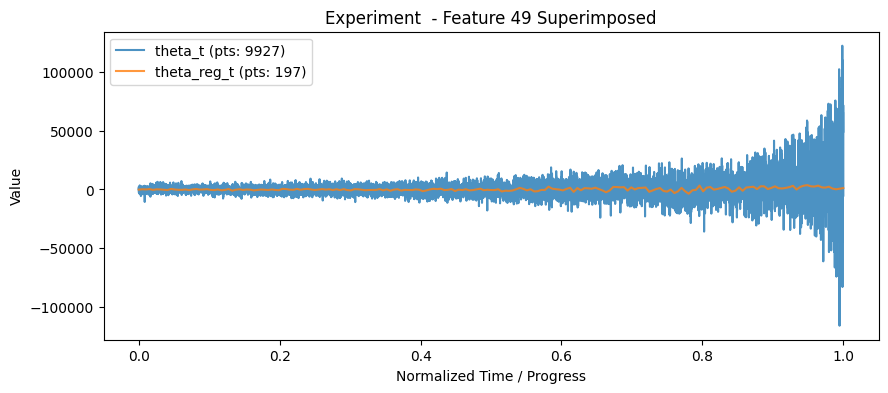

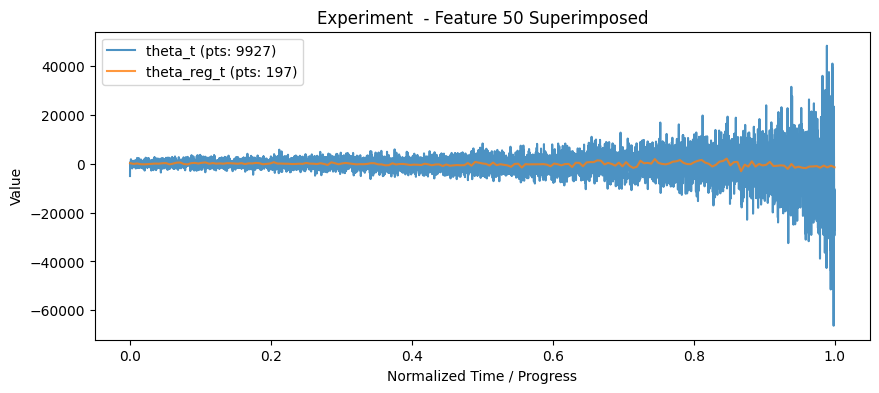

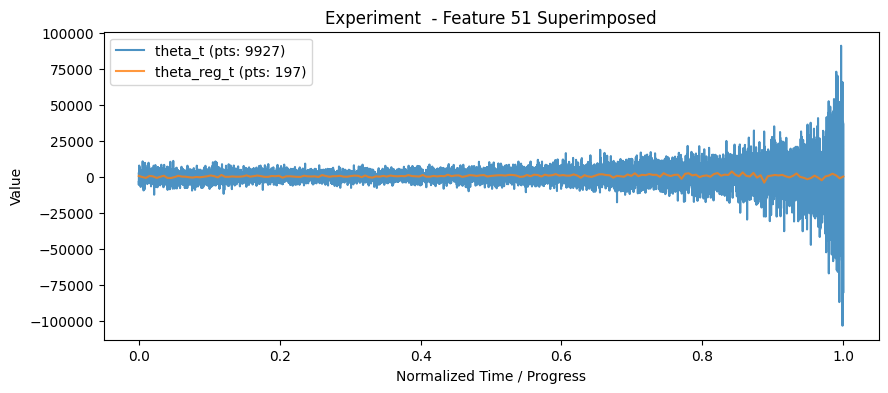

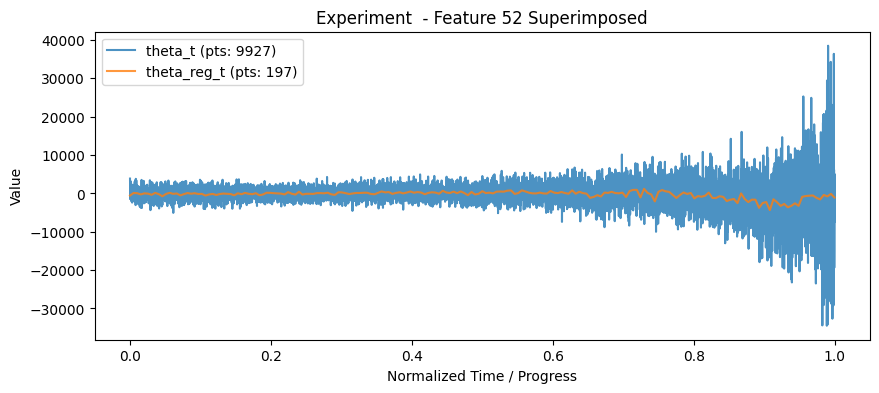

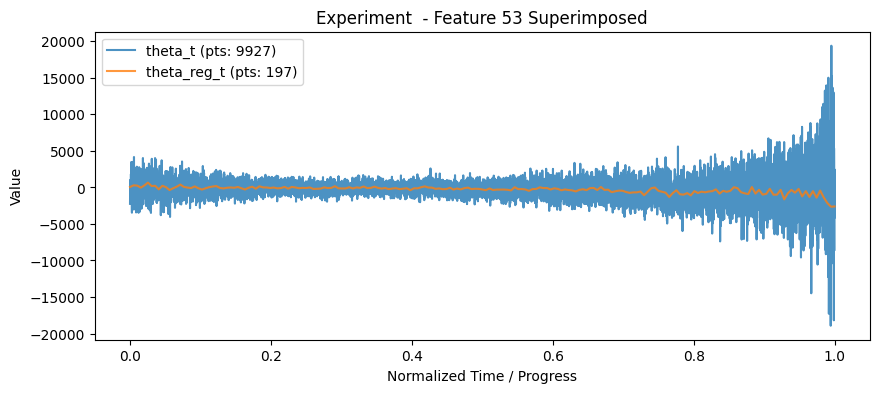

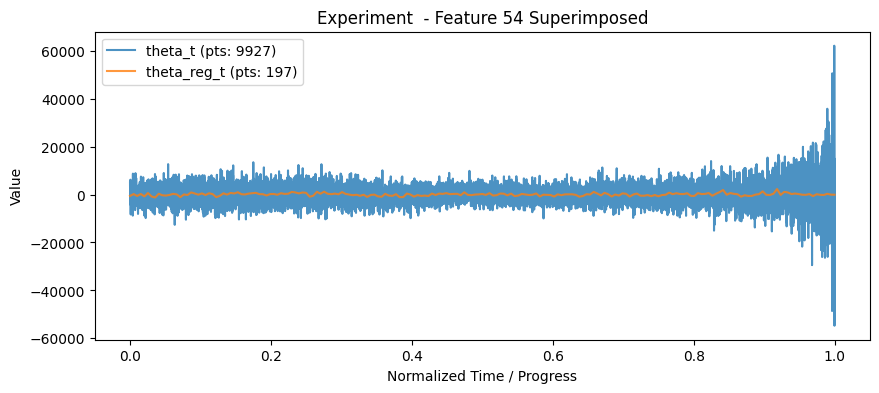

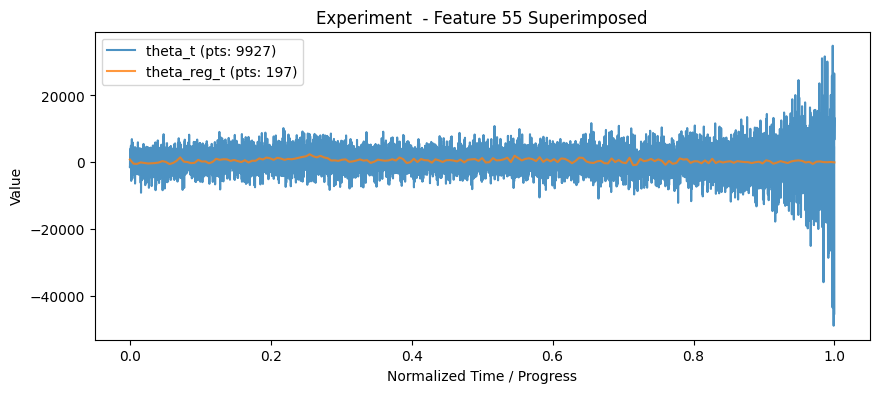

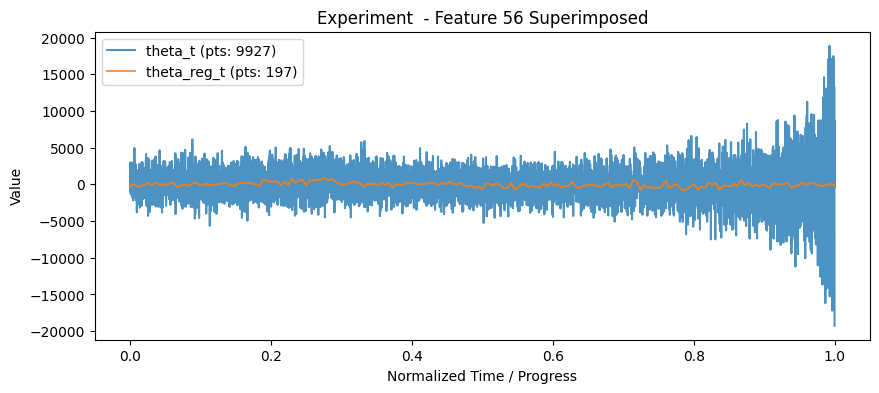

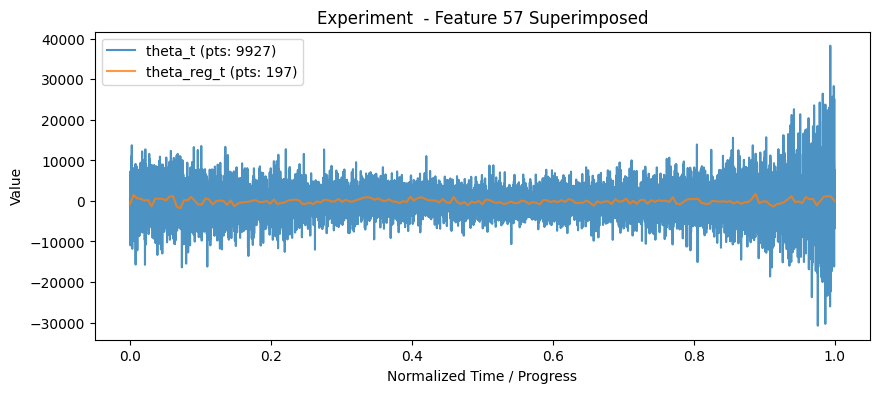

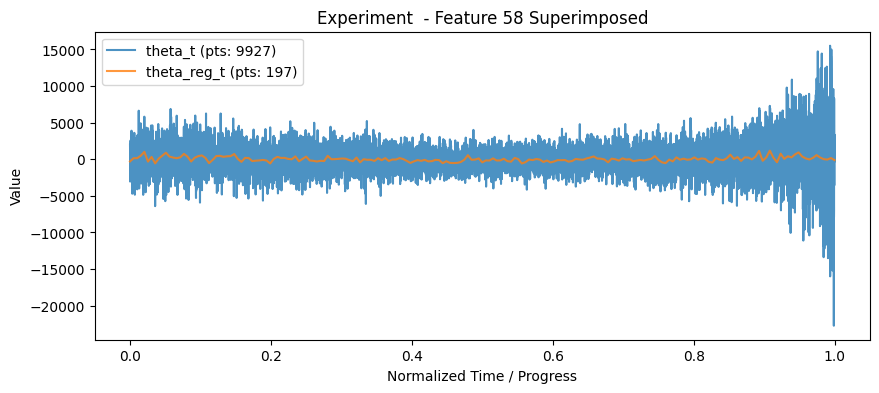

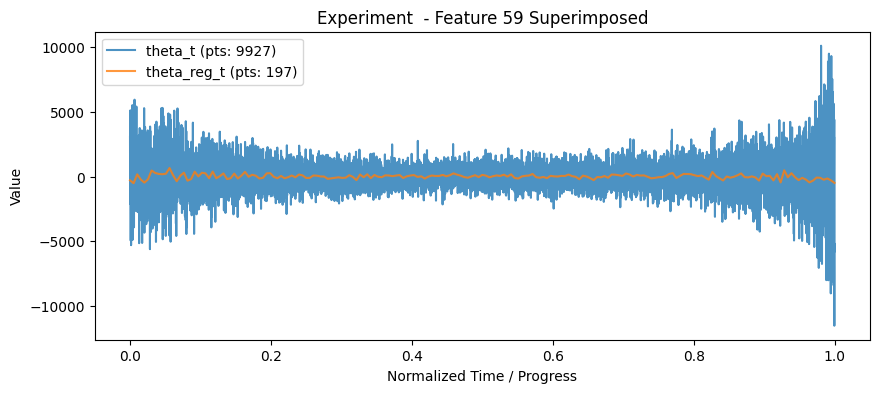

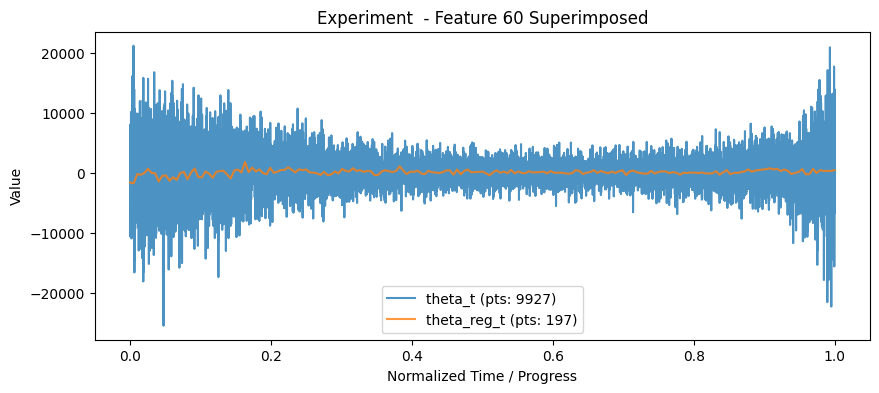

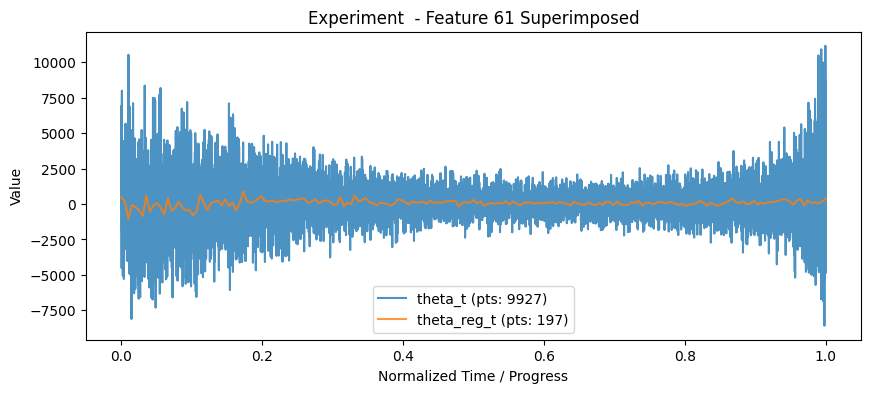

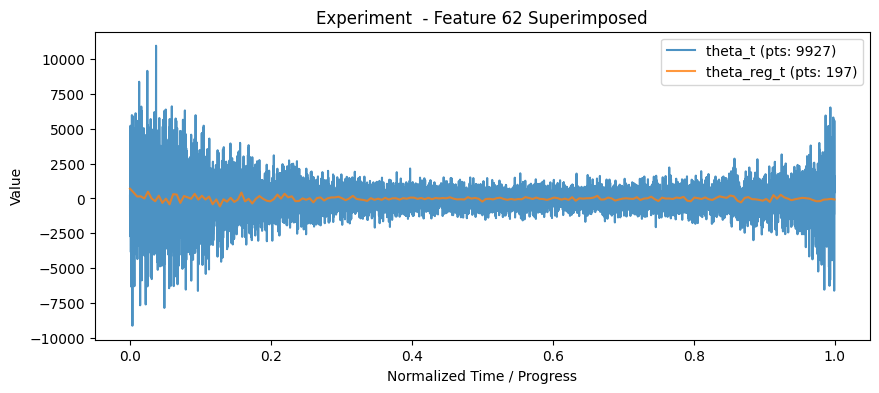

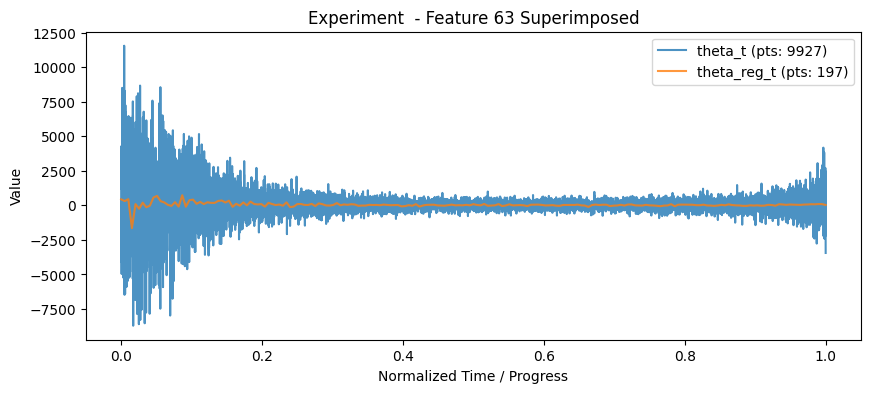

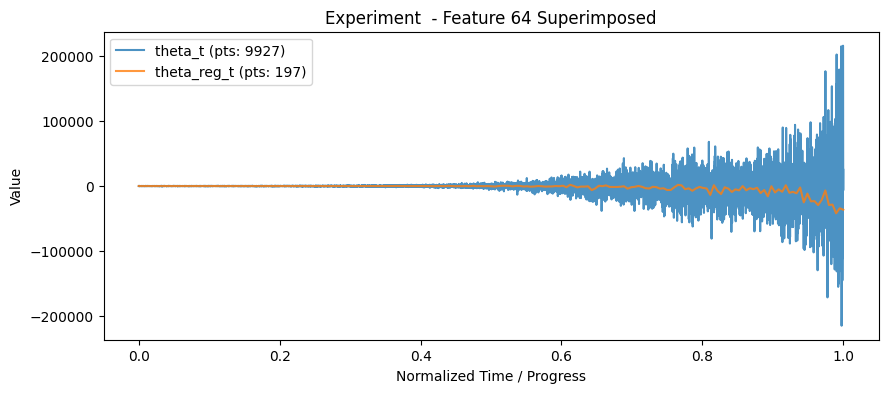

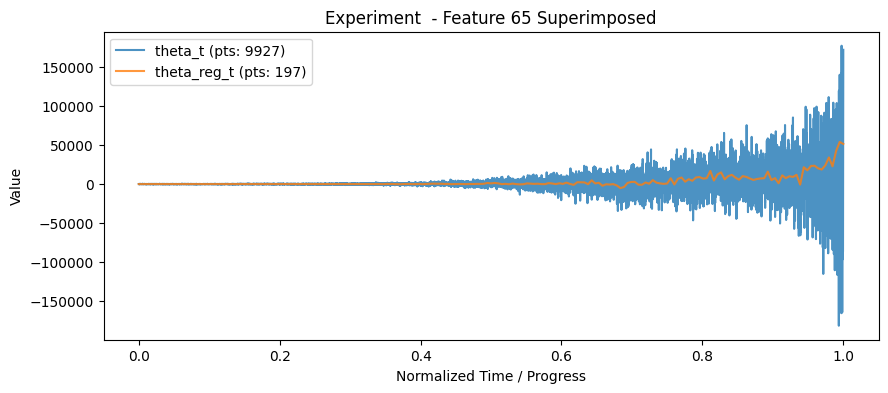

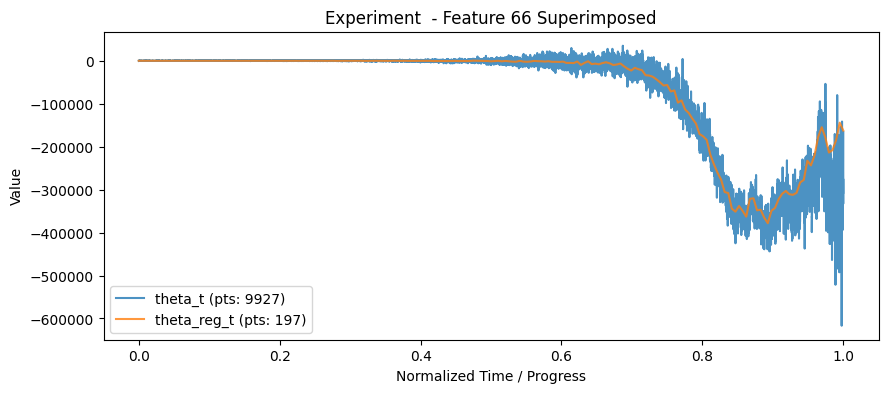

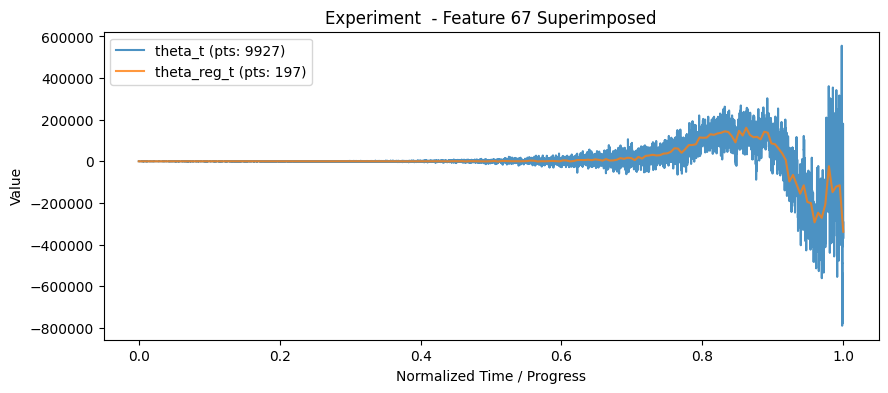

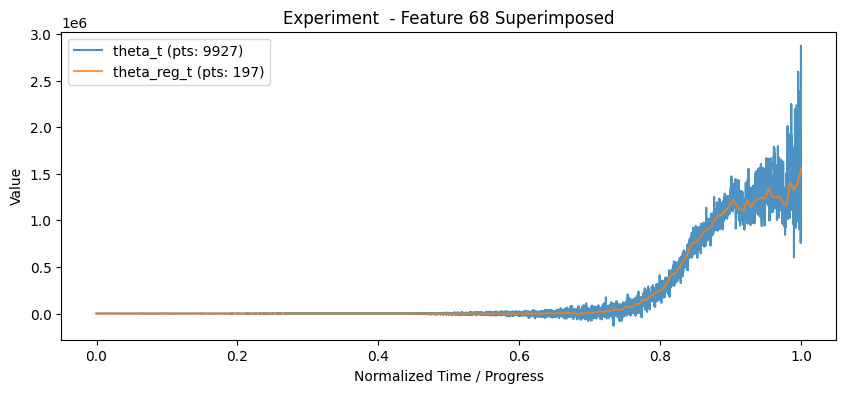

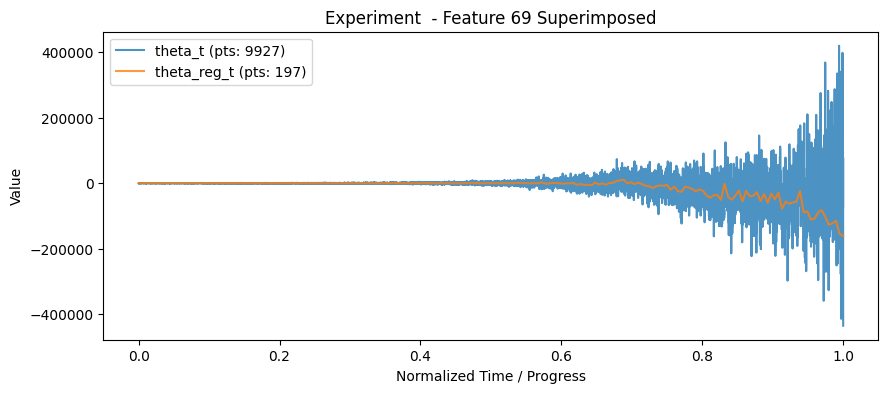

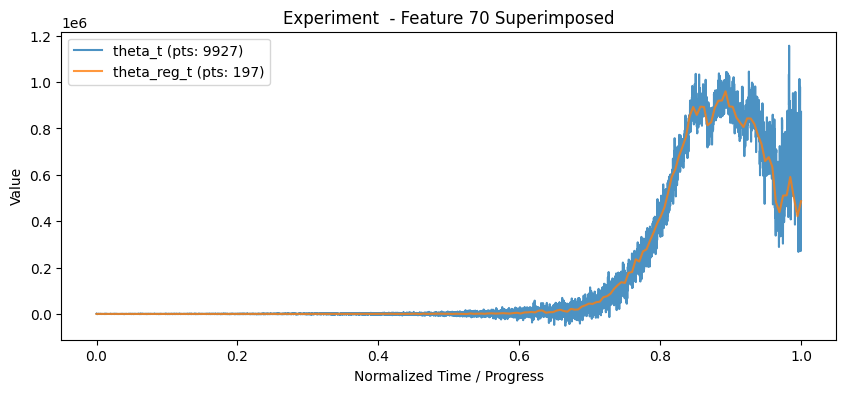

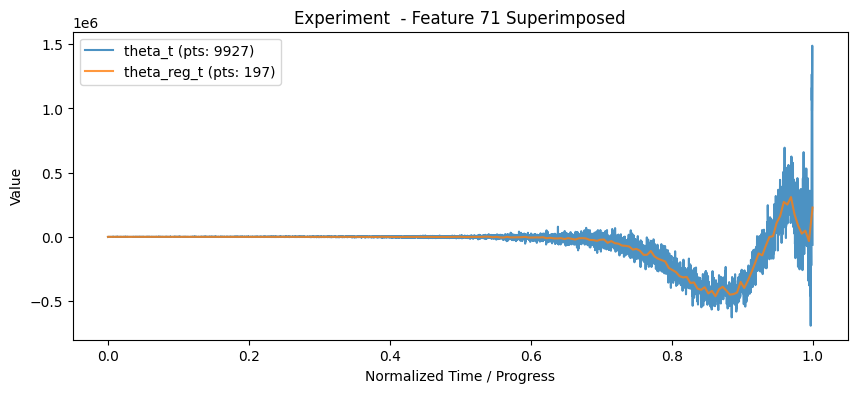

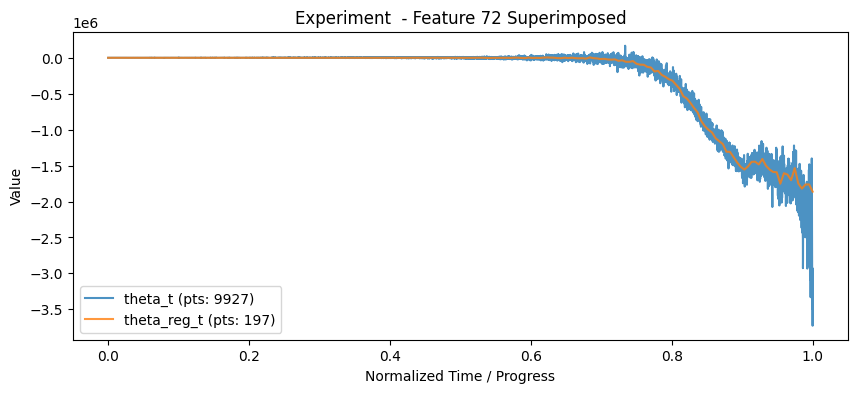

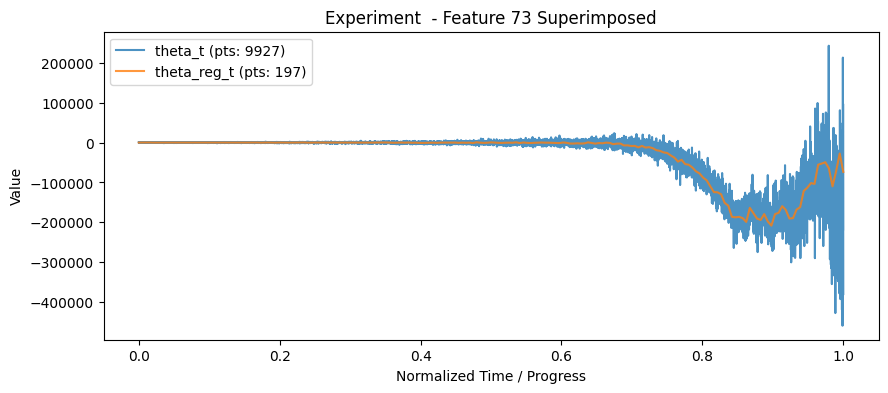

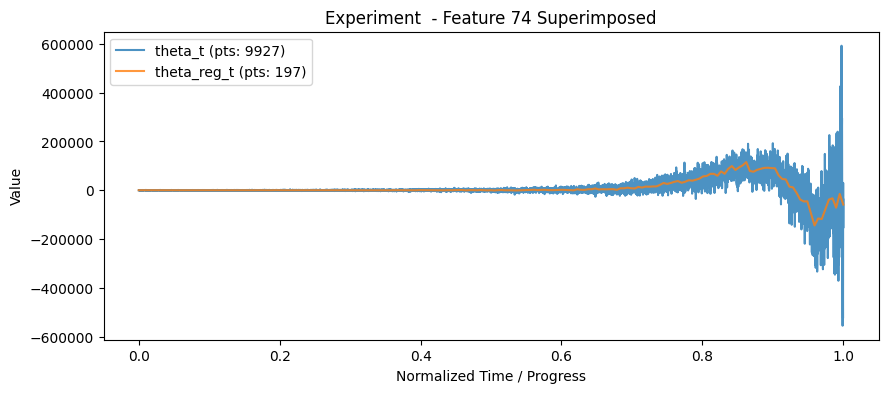

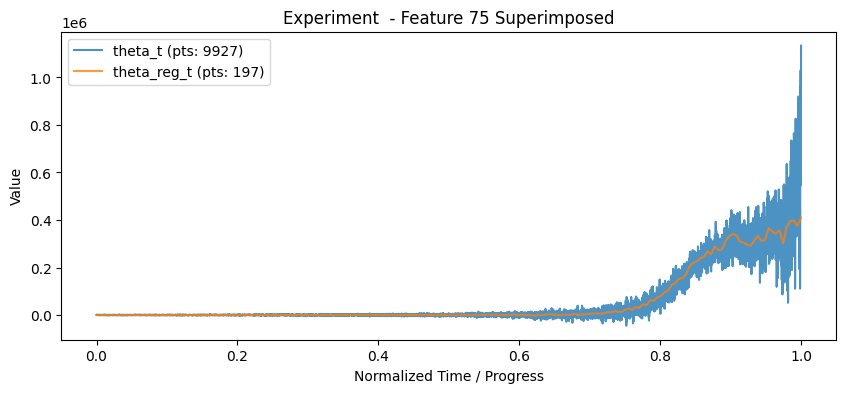

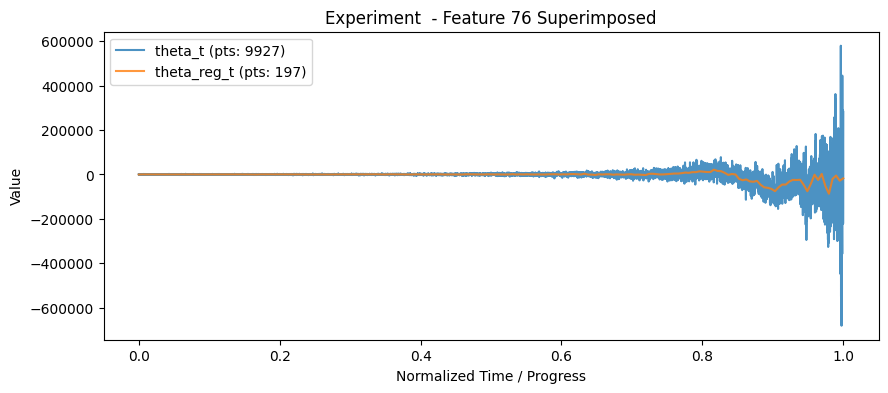

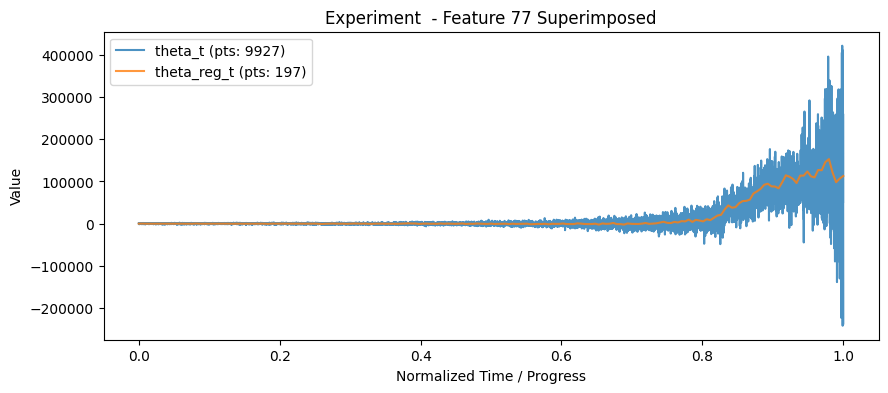

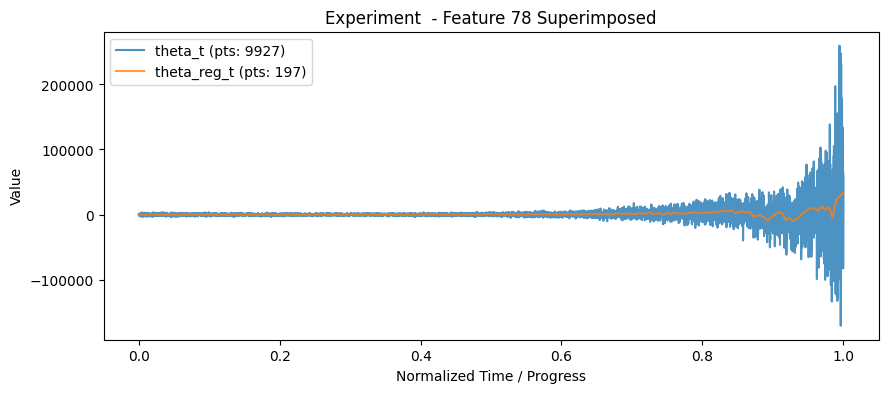

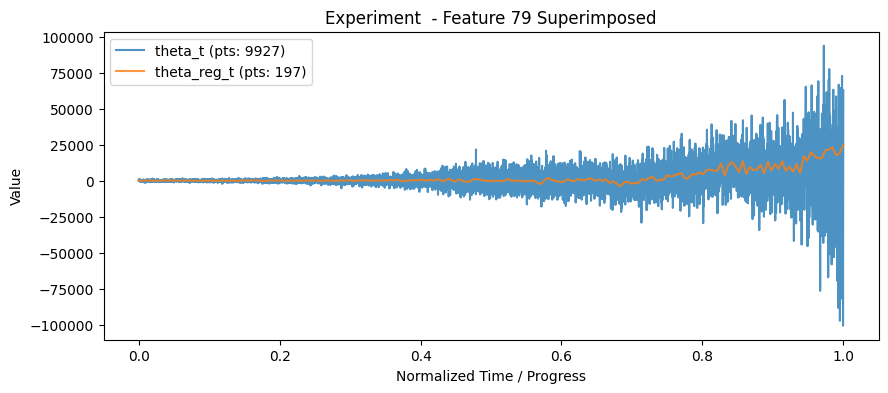

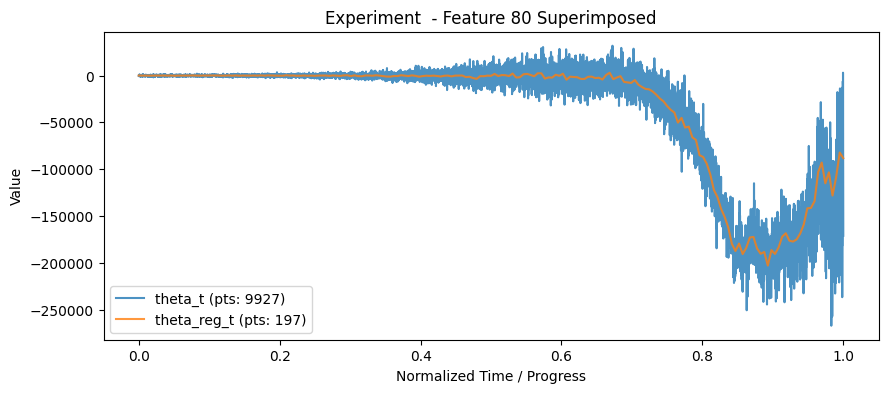

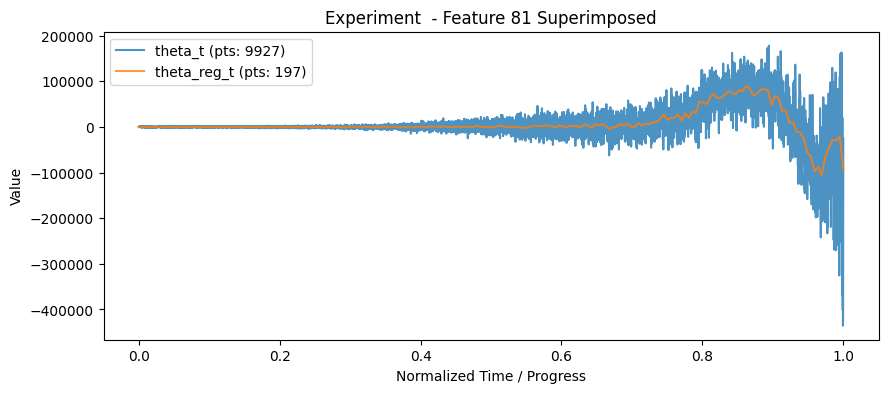

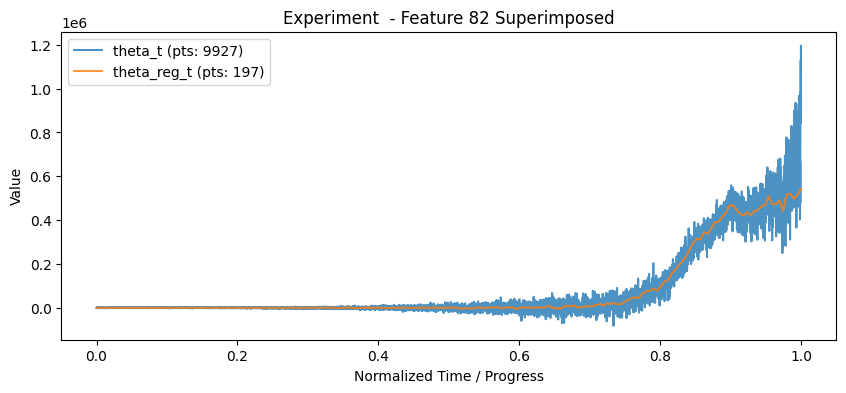

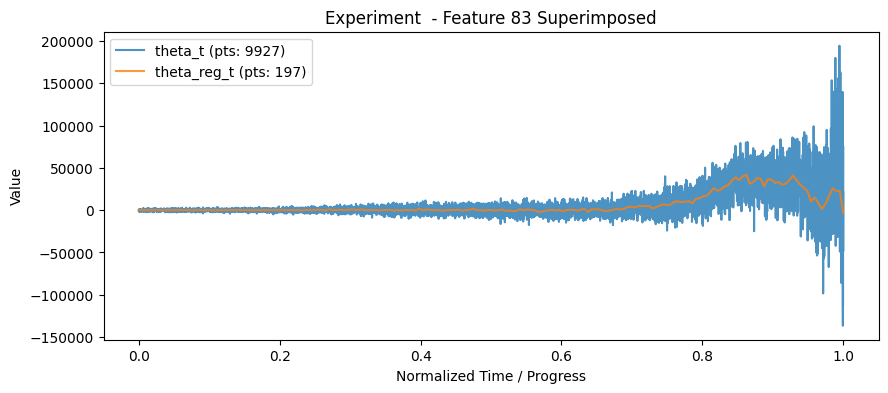

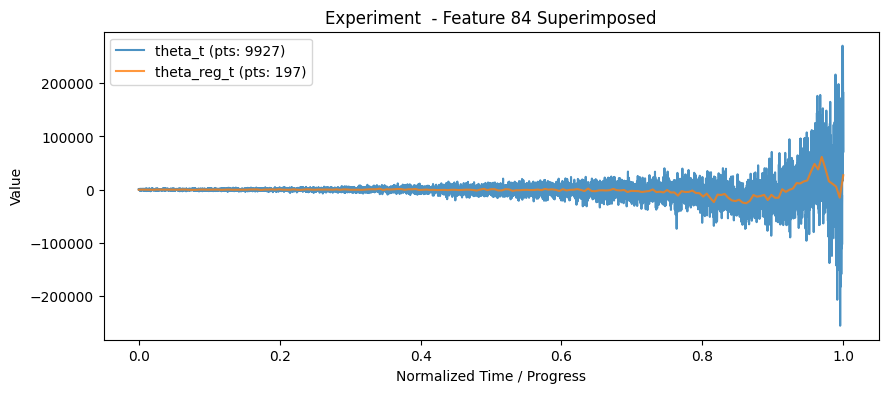

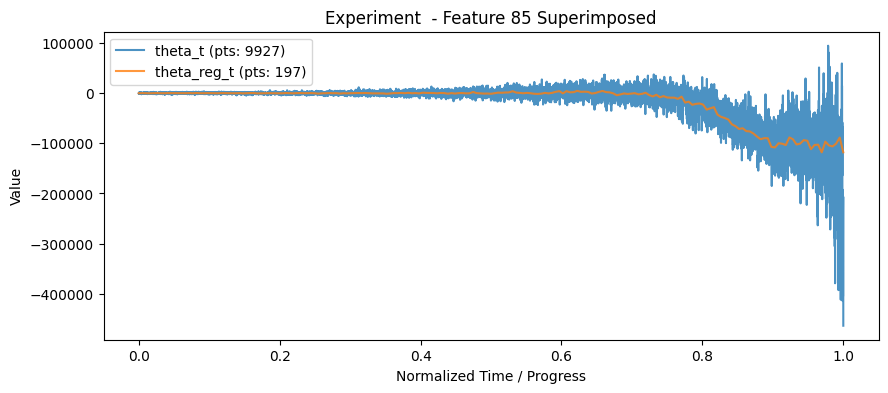

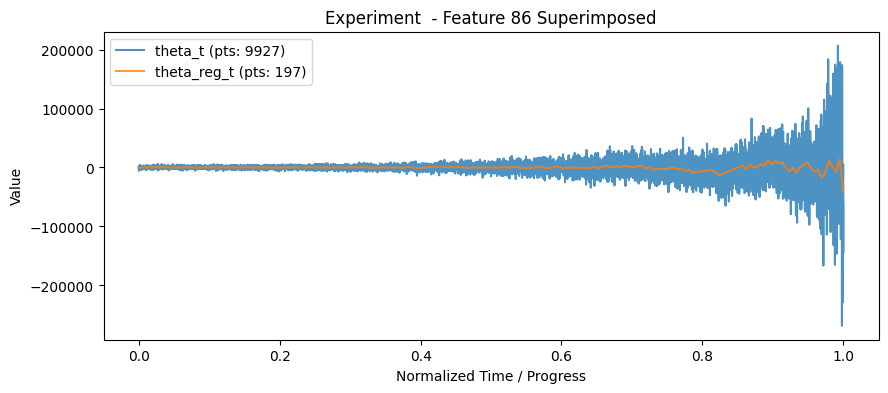

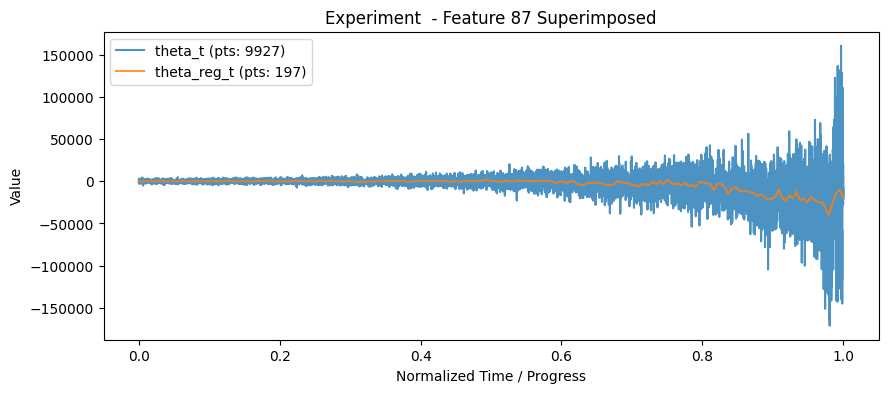

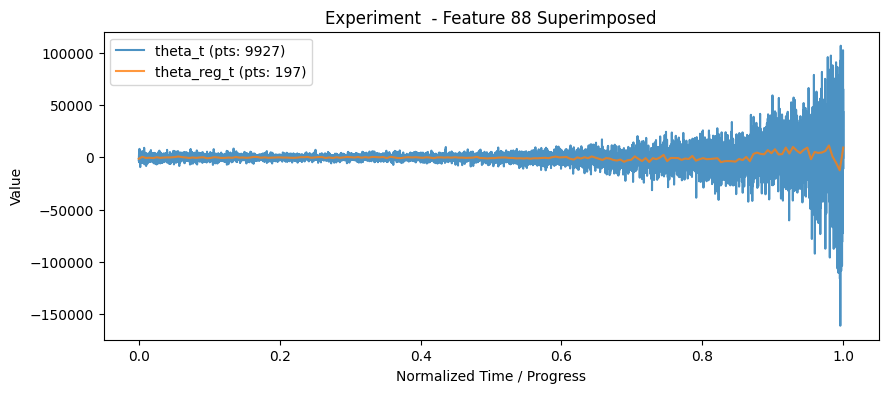

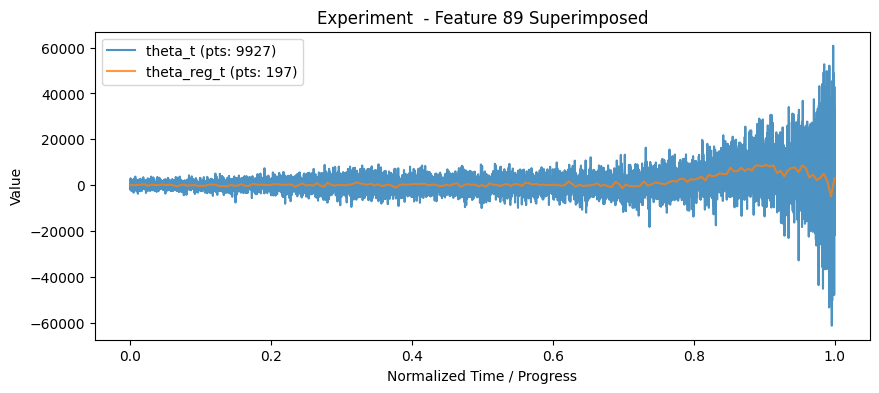

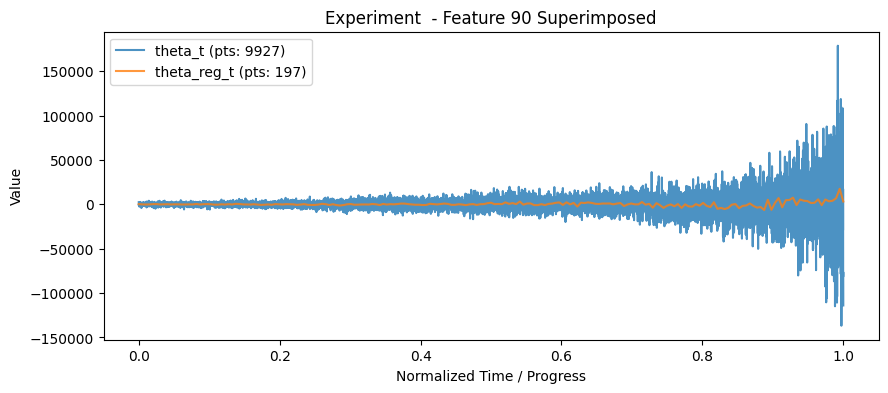

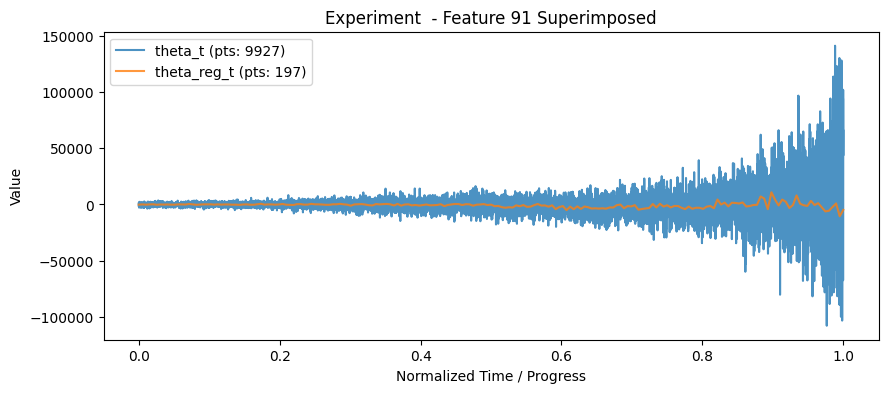

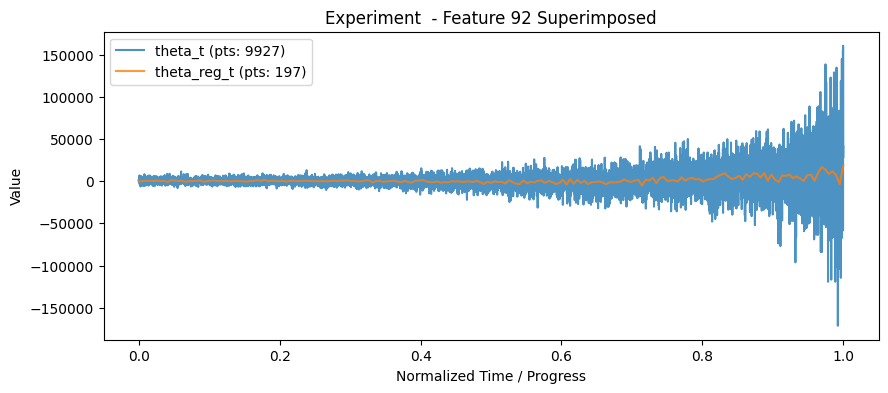

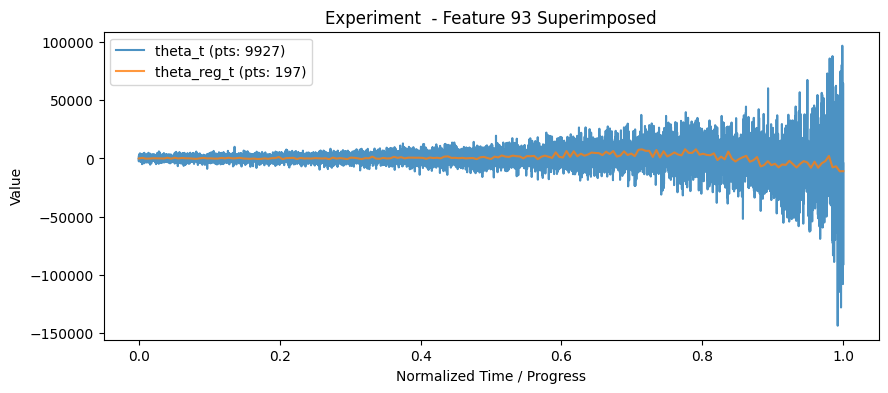

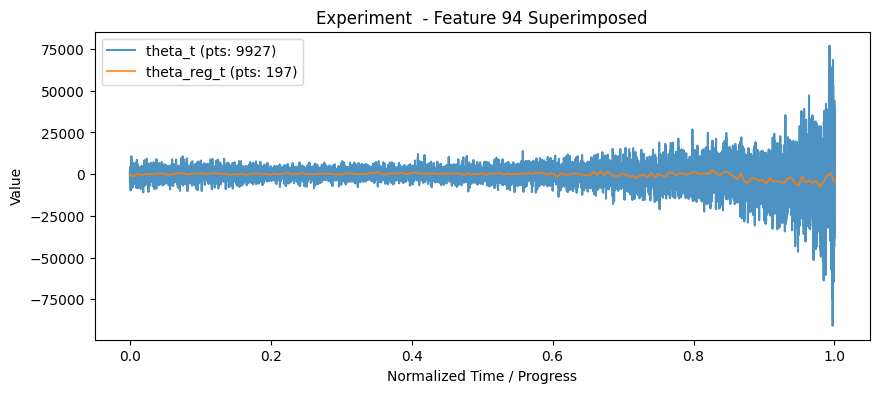

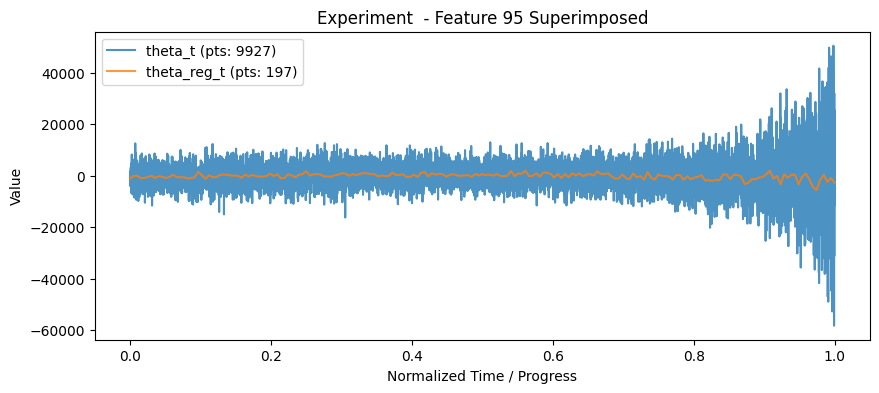

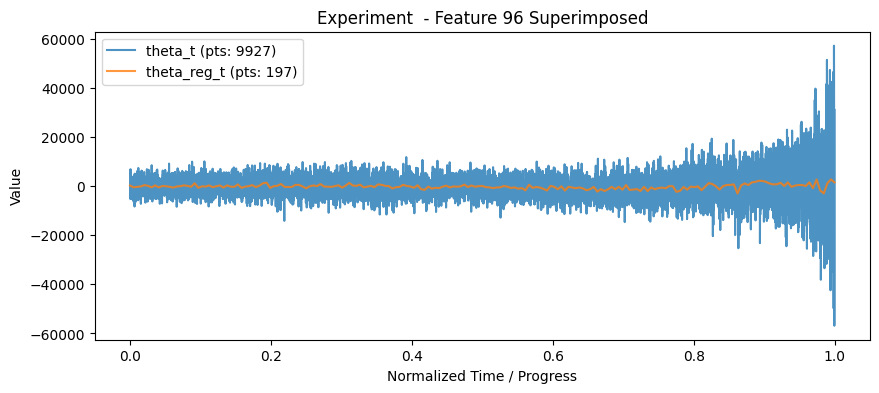

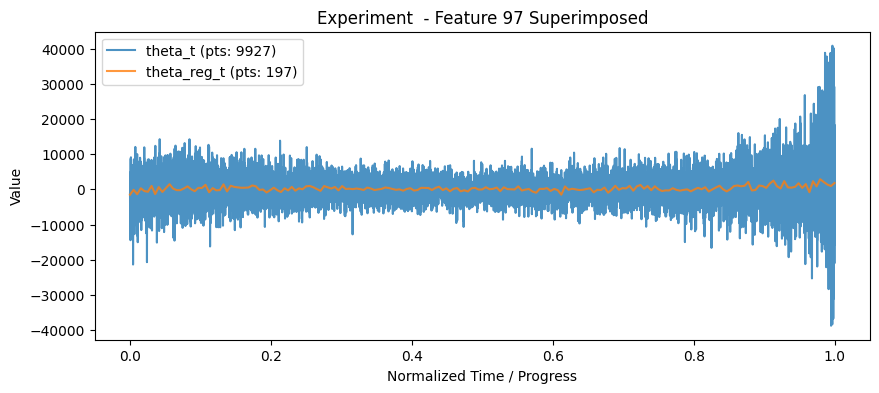

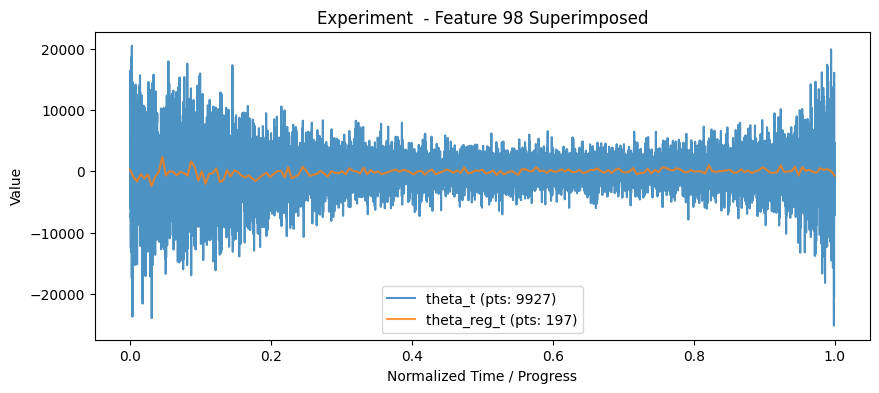

In [11]:
# Move to CPU and convert to numpy for easier plotting
import matplotlib.pyplot as plt
theta_t = theta_t.cpu()
theta_reg_t = theta_reg_t.cpu()

# Get the number of time steps (rows) for each
len_t = theta_t.shape[0]
len_reg = theta_reg_t.shape[0]
print(len_t, len_reg) 

# Iterate through each feature/column
%matplotlib inline
for i in range(theta_t.shape[1]): 
    # Create matching X-axes spanning from 0 to 1 (or 0 to len_t if preferred)
    x_t = np.linspace(0, 1, len_t)
    x_reg = np.linspace(0, 1, len_reg)
    
    plt.figure(figsize=(10, 4))
    
    # Plot both on the same axes
    #plt.plot(results[key]['xt'], theta_t[:, i], label=f"theta_t (pts: {len_t})", alpha=0.8) 
    plt.plot(x_t, theta_t[:, i], label=f"theta_t (pts: {len_t})", alpha=0.8) 
    plt.plot(x_reg, theta_reg_t[:, i], label=f"theta_reg_t (pts: {len_reg})", alpha=0.8) 
    
    plt.title(f"Experiment {label} - Feature {i} Superimposed")
    plt.xlabel("Normalized Time / Progress")
    plt.ylabel("Value")
    plt.legend()
    plt.show()  # Show the combined plot

## Moment matching diagnostics

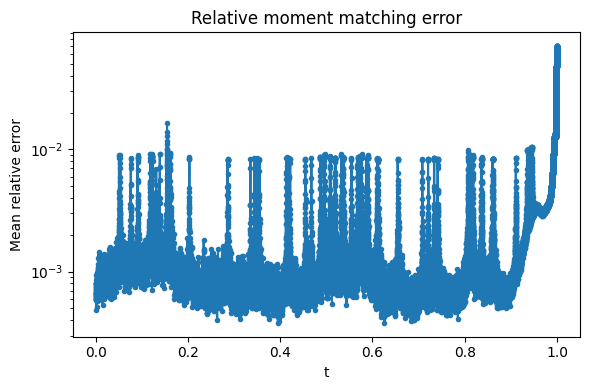

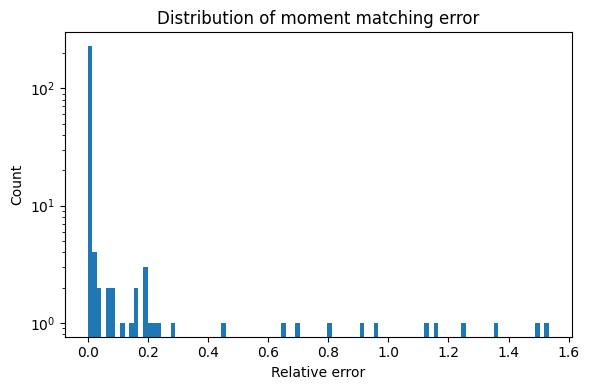

<Figure size 640x480 with 0 Axes>

In [10]:
threshold = 1e-8
%matplotlib inline
print(label)
if result.get('barphi_e') is None or result.get('barphi_p') is None:
    print('Moment matching arrays not available. Set FORCE_RERUN=True or make sure the auxiliary file exists.')
else:
    plot_moment_matching(result['barphi_e'], result['barphi_p'], result['t'], threshold)
    plt.suptitle(label)
    
    plt.show()


## Visual comparison of samples

In [13]:
def Compare_time_series_row(Data, Synth, N, save=None):
    """Compare the first N time series: data (top) vs synthesis (bottom)."""

    # Increased figure height slightly to accommodate larger labels without overlapping
    fig, axs = plt.subplots(
        2,
        N,
        figsize=(3.5 * N, 5.5),
        sharex=True,
        sharey=False,
        constrained_layout=True,
    )

    # Handle N=1 edge case where axs is 1D array instead of 2D
    if N == 1:
        axs = axs[:, np.newaxis]

    x = np.arange(Data.shape[-1])

    for row, (dataset, color, ylabel) in enumerate(
        zip((Data, Synth), ("tab:blue", "navy"), ("Data", "MGD synthesis"))
    ):

        # Row / Axis Title Font Size (16pt)
        axs[row, 0].set_ylabel(
            ylabel, fontsize=16, fontweight="bold", labelpad=8
        )

        for col, ax in enumerate(axs[row]):
            y = dataset[col, 0].cpu()
            ax.plot(
                x,
                y,
                color=color,
                lw=2.2,  # Thicker line for paper clarity
                marker="o",
                ms=3,  # Slightly larger marker
                mfc="white",
                mec=color,
                mew=1.0,
            )

            ax.grid(alpha=0.2)
            ax.spines[["top", "right"]].set_visible(False)

            if col:
                ax.set_yticklabels([])

            # Axis Tick Label Font Size (14pt)
            ax.tick_params(axis="both", which="major", labelsize=14)

    if save:
        if "title" in save:
            # Figure Title Font Size (18pt)
            fig.suptitle(save["title"], fontsize=18, fontweight="bold")
        fig.savefig(save["filename"], dpi=300, bbox_inches="tight")
        plt.close(fig)
    else:
        plt.show()

In [14]:
for i in range(0,15): 
    save_config = {
        "filename": f"figures/jets_time_series_compare{i}.png",
        "title": ""  # Optional: set a title or leave out if not needed
    }
    print(result['xt'].shape) 
    print(label)
    %matplotlib inline 
    Compare_time_series_row(x1[i*5:i*5+5,:,:], result['xt'][i*5:i*5+5,:,:],1, save_config)
    plt.suptitle(label)
    plt.show()


torch.Size([3000, 1, 128])



<Figure size 640x480 with 0 Axes>

torch.Size([3000, 1, 128])



<Figure size 640x480 with 0 Axes>

torch.Size([3000, 1, 128])



...

<Figure size 640x480 with 0 Axes>

torch.Size([3000, 1, 128])



<Figure size 640x480 with 0 Axes>

torch.Size([3000, 1, 128])



<Figure size 640x480 with 0 Axes>

## Roba di boffetta

<Axes: xlabel='$\\tau$', ylabel='Skewness'>

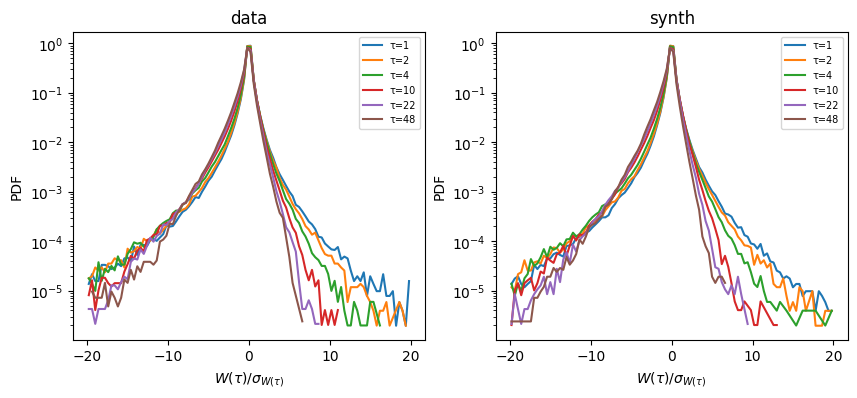

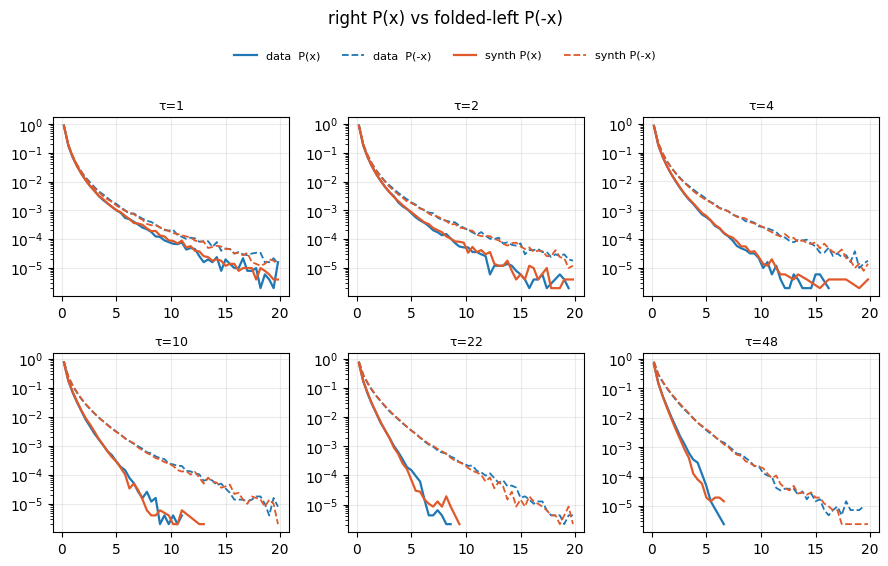

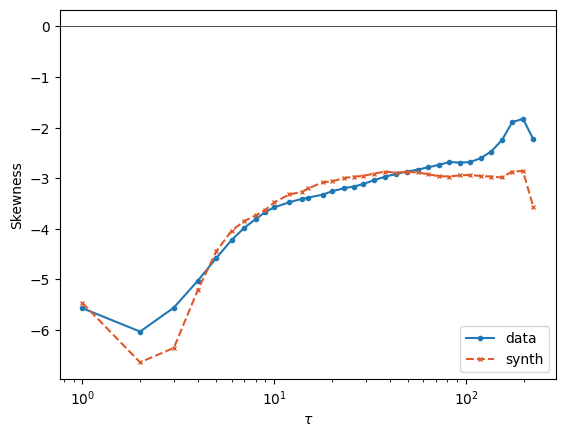

In [15]:
T = x1.shape[-1]
taus = logspaced_taus(50, num_points=6)              # positive only, for PDFs
pdf_data  = pdf_energy_increments(x1, taus, mode="power")
pdf_synth = pdf_energy_increments(result["xt"], taus, mode="power")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
plot_pdf_panel(pdf_data, ax=axes[0], title="data")
plot_pdf_panel(pdf_synth, ax=axes[1], title="synth")

plot_pdf_folded_grid(pdf_data, pdf_synth, title="right P(x) vs folded-left P(-x)")

fig2, ax2 = plt.subplots()
%matplotlib inline
plot_skewness_comparison(x1, result["xt"], ax=ax2)   # positive-only log-x taus by default

## Energy increments distribution skewness 

In [107]:
# x = velocity 
E_data = 0.5 * x1**2 
E_synth = 0.5 * result["xt"]**2 

In [108]:
start_tau = 1      # The plot starts around tau = 2 or 3
end_tau = 1024     # The plot ends around 1000
num_points = 45    # Visually, there are roughly 40-50 points in the plot

# 2. Generate log-spaced floats using base-10 exponents
# log10(2) ≈ 0.301, log10(1000) = 3.0
taus_float = torch.logspace(
    start=torch.log10(torch.tensor(start_tau, dtype=torch.float32)),
    end=torch.log10(torch.tensor(end_tau, dtype=torch.float32)),
    steps=num_points,
    base=10.0
)

# 3. Convert to integers and keep only the unique values to prevent indexing errors
pos_taus = torch.unique(taus_float.long()).tolist()
neg_taus = [-t for t in reversed(pos_taus)]
taus_list = neg_taus + pos_taus

In [109]:
skew_data_array = []
skew_synth_array = []

for tau in taus_list: 
    # Gestione dello slicing per mantenere la coerenza temporale
    if tau > 0:
        # Il futuro v(t + tau) e il presente v(t)
        v_future_data = x1[:, :, tau:]
        v_present_data = x1[:, :, :-tau]
        
        v_future_synth = result["xt"][:, :, tau:]
        v_present_synth = result["xt"][:, :, :-tau]
    else:
        # Se tau è negativo (es. -5):
        # v(t + tau) è il passato -> x1[:, :, :-5]
        # v(t) è il presente -> x1[:, :, 5:]
        v_future_data = x1[:, :, :tau]
        v_present_data = x1[:, :, -tau:]
        
        v_future_synth = result["xt"][:, :, :tau]
        v_present_synth = result["xt"][:, :, -tau:]

    # 1. Calcola l'incremento di velocità corretto: delta_v = v(t + tau) - v(t)
    delta_v_data = v_future_data - v_present_data
    delta_v_synth = v_future_synth - v_present_synth
    
    # 2. Moltiplica l'incremento per la velocità presente v(t)
    target_data = delta_v_data * v_present_data
    target_synth = delta_v_synth * v_present_synth
    
    # 3. Centra i dati rispetto alla media
    target_data_centered = target_data - torch.mean(target_data)
    target_synth_centered = target_synth - torch.mean(target_synth)
    
    # 4. Calcola la skewness: S = < target^3 > / < target^2 >^1.5
    skew_data = (torch.mean(target_data_centered**3) / (torch.mean(target_data_centered**2)**1.5)).cpu()
    skew_synth = (torch.mean(target_synth_centered**3) / (torch.mean(target_synth_centered**2)**1.5)).cpu()
    
    skew_data_array.append(skew_data.item()) 
    skew_synth_array.append(skew_synth.item())

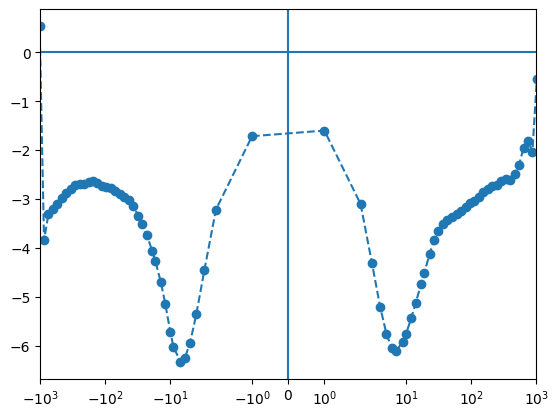

In [110]:
plt.plot(taus_list, skew_data_array, "o--") 
#plt.plot(taus_list, skew_synth_array, "o--") 
plt.axhline(0)
plt.axvline(0) 
plt.xscale("symlog") 
plt.xlim(-1000, 1000)
plt.show() 

## Leverage with C_pq

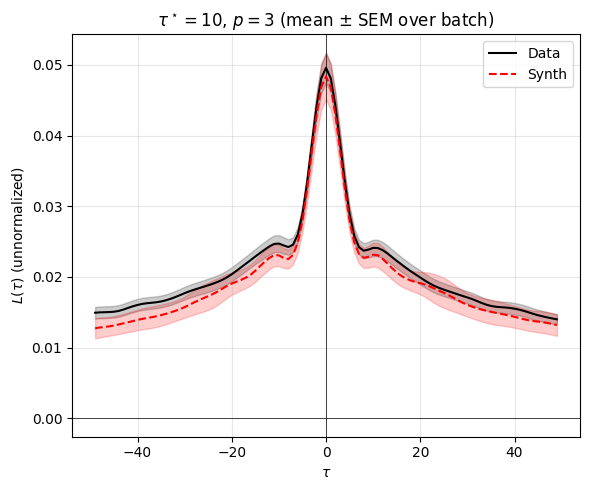

In [11]:
tau, L_data, err_data, L_synth, err_synth = C_pq_plot(x1, result["xt"], p = 3.0, tau_star=10, normalize=False) 

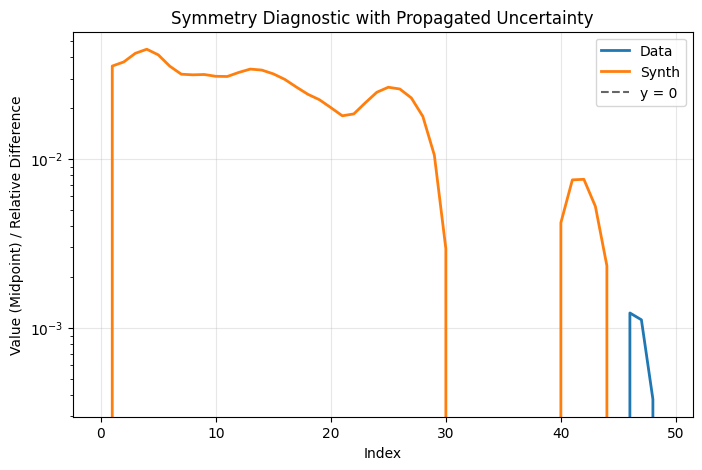

In [22]:
# 2. Find the midpoint index
half = L_data.shape[0] // 2 

# --- Rel Diff: DATA ---
A_d, B_d = L_data[:half], L_data[-half:][::-1]
sA_d, sB_d = err_data[:half], err_data[-half:][::-1]

rel_diff_data = (-1*A_d + B_d) / ((A_d + B_d) / 2)
# Propagated error for relative difference
err_rel_diff_data = (4 / (A_d + B_d)**2) * np.sqrt((B_d * sA_d)**2 + (A_d * sB_d)**2)

# --- Rel Diff: SYNTHETIC ---
A_s, B_s = L_synth[:half], L_synth[-half:][::-1]
sA_s, sB_s = err_synth[:half], err_synth[-half:][::-1]

rel_diff_synth = (-1*A_s + B_s) / ((A_s + B_s) / 2)
# Propagated error for relative difference
err_rel_diff_synth = (4 / (A_s + B_s)**2) * np.sqrt((B_s * sA_s)**2 + (A_s * sB_s)**2)

# 3. Prepend the midpoint value and its original error (index 0)
diff_data = np.r_[0, rel_diff_data]
diff_synth = np.r_[0, rel_diff_synth]

err_plot_data = np.r_[err_data[half], err_rel_diff_data]
err_plot_synth = np.r_[err_synth[half], err_rel_diff_synth]

# 4. Plotting
plt.figure(figsize=(8, 5))
x_axis = np.arange(len(diff_data))

# Plot lines
plt.plot(x_axis, diff_data, label="Data", color="C0", lw=2)
plt.plot(x_axis, diff_synth, label="Synth", color="C1", lw=2)

# Plot uncertainty bounds
# plt.fill_between(x_axis, diff_data - err_plot_data, diff_data + err_plot_data, 
#                  color="C0", alpha=0.2, label="Data Uncertainty")
# plt.fill_between(x_axis, diff_synth - err_plot_synth, diff_synth + err_plot_synth, 
#                  color="C1", alpha=0.2, label="Synth Uncertainty")

# Reference line at y=0 (dashed, thin)
plt.axhline(0, color="black", linestyle="--", alpha=0.6, label="y = 0")

plt.yscale("log") 
plt.xlabel("Index")
plt.ylabel("Value (Midpoint) / Relative Difference")
plt.title("Symmetry Diagnostic with Propagated Uncertainty")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Scaling exponent ratio 

Computing structure functions for 24 lags...
Computing structure functions for 24 lags...


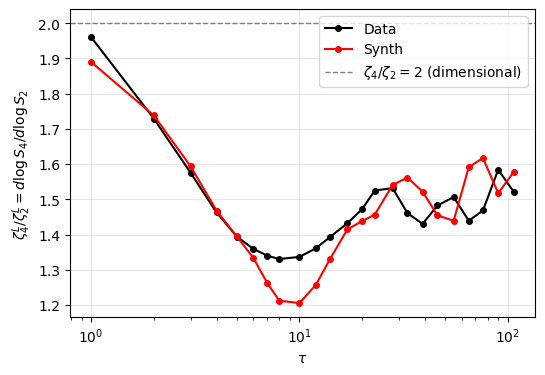

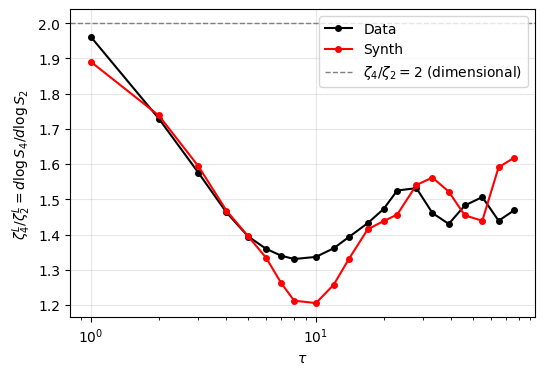

In [23]:
taus, ratio_data, ratio_synth = scaling_exponent_ratio_compare(x1, result['xt'], 30, kill_points=1) 

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(taus[:-2], ratio_data[:-2], 'ko-', ms=4, label='Data')
ax.plot(taus[:-2], ratio_synth[:-2], 'ro-', ms=4, label='Synth')
ax.axhline(2.0, color='grey', ls='--', lw=1, label=r'$\zeta_4/\zeta_2=2$ (dimensional)')
ax.set_xscale('log')
ax.set_xlabel(r'$\tau$')
ax.set_ylabel(r'$\zeta_4^L/\zeta_2^L = d\log S_4 / d\log S_2$')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

## Histograms reproduction and other diagnostics 

Spectrum



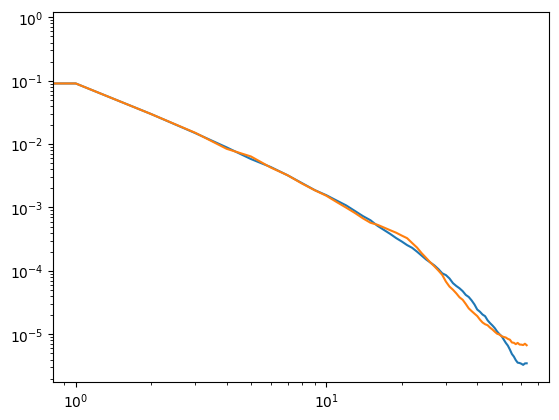

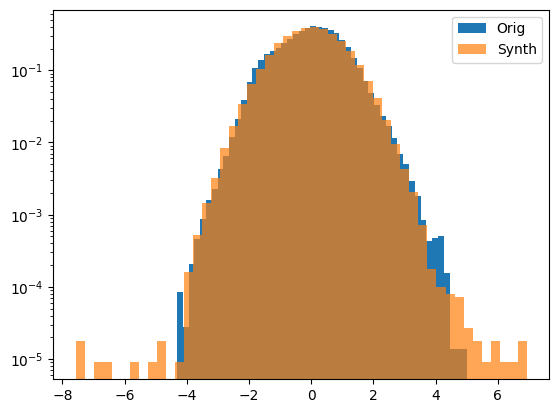

<Figure size 640x480 with 0 Axes>

Histogram



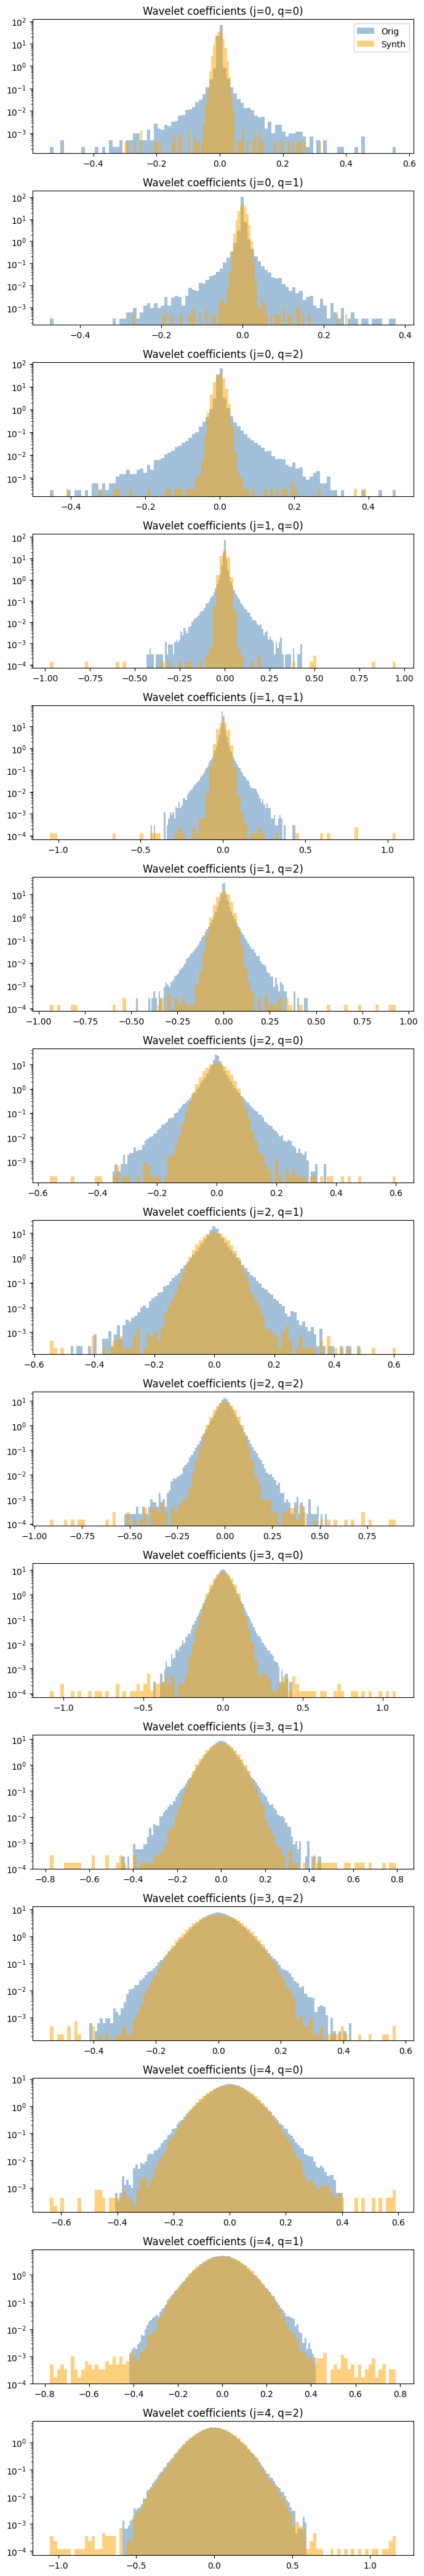

<Figure size 640x480 with 0 Axes>

Structure functions

Computing structure functions for 63 lags...
Computing structure functions for 63 lags...


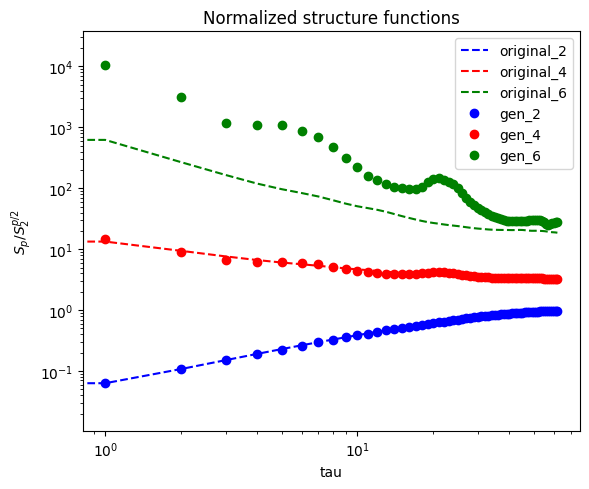

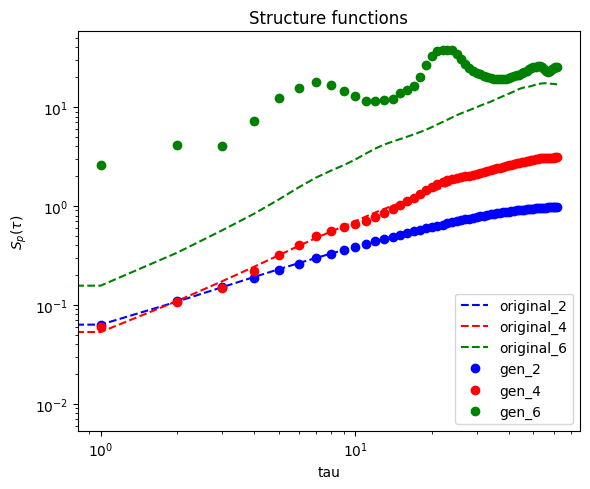

<Figure size 640x480 with 0 Axes>

In [15]:
%matplotlib inline 
def run_project_diagnostics(x_ref, result):
    """
    Uses the existing project plotting utilities. These functions usually create
    their own figures, so we call each diagnostic once per model and add titles.
    """
    diagnostic_functions = [
        ('Spectrum', spec_plot),
        ('Histogram', hist_plot),
        ('Structure functions', structure_plot),
    ]

    for diag_name, diag_fun in diagnostic_functions:
        print('' + '=' * 80)
        print(diag_name)
        print('=' * 80)
        print(label)
        diag_fun(x_ref, result['xt'])
        plt.suptitle(f"{diag_name}: {label}")
        plt.show()

    #print('' + '=' * 80)
    #print('Cross statistics')
    #print('=' * 80)
    #for key, exp in experiments.items():
        #print(exp['label'])
        #cross_plot(x_ref, xt_cg, pq=[(3, 1), (3, 3), (4, 4)])
        #plt.suptitle(f"Cross statistics: {exp['label']}")
        #plt.show()

run_project_diagnostics(x1, result)


## Entropy bound comparison

Contains NaN: tensor(False)
Contains Inf: tensor(False)
GaussianK_psi
  Entropy bound: 47.57743835449219
  Gaussian estimation: -66.50381469726562


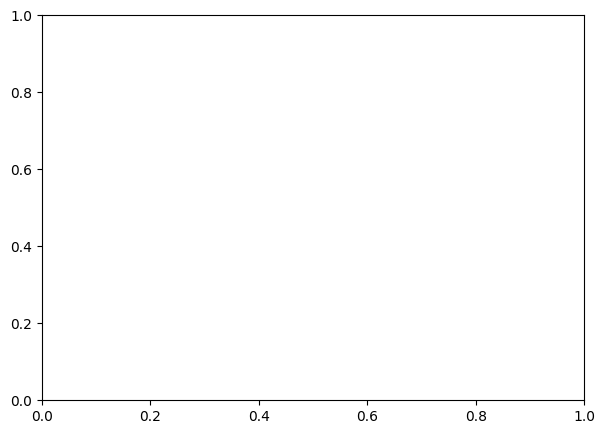

<class 'ValueError'>: x and y must have same first dimension, but have shapes (41,) and (39,)

In [30]:
def entropy_curves(x_ref, dH_t_bound, t_used):
    d = x_ref.shape[-2] * x_ref.shape[-1]
    H_p_0 = (np.log(2 * np.pi) + 1) * d / 2
    H_t_bound = dH_t_bound.cumsum(0).detach().cpu() / (t_used.shape[0]) + H_p_0
    H_t_gaussian = compute_gaussian_entropy(x_ref, interpolant, t_used)
    return H_t_bound, H_t_gaussian

plt.figure(figsize=(7, 5))
last_gaussian = None

H_t_bound, H_t_gaussian = entropy_curves(x1, result['dH_t_bound'], result['t'].cpu())

print("Contains NaN:", torch.isnan(result['dH_t_bound']).any())
print("Contains Inf:", torch.isinf(result['dH_t_bound']).any())
last_gaussian = H_t_gaussian
print(label)
print('  Entropy bound:', H_t_bound[-2].item() if torch.is_tensor(H_t_bound[-2]) else H_t_bound[-1])
print('  Gaussian estimation:', H_t_gaussian[-2].item() if torch.is_tensor(H_t_gaussian[-2]) else H_t_gaussian[-2])
plt.plot(result['t'].detach().cpu(), H_t_bound, label=f"bound: {label}")
"""
plt.plot(
    t.detach().cpu(),
    last_gaussian.detach().cpu() if torch.is_tensor(last_gaussian) else last_gaussian,
    '--',
    label='Gaussian entropy estimate',
)
plt.xlabel('t')
plt.ylabel('entropy')
plt.legend()
plt.tight_layout()
plt.show()
"""

## Project entropy plotting utility for each model

## Plots for paper 

In [12]:
"""
Per-panel figure generator for the turbulence diagnostics paper figure.

Each panel_* function makes ONE standalone matplotlib figure comparing two
(data, synth) pairs -- Eulerian (blue) and Lagrangian (green) -- with training
data as dotted lines and MGD synthesis as solid lines. Call make_all_panels()
once per (data_E, synth_E, data_L, synth_L) group; run it again for a second
pair of datasets by just calling it again with a different save_dir.

Depends on (assumed already imported / defined in the notebook):
    second_order_structure_function, flatness, logder, C_pq_structure,
    leverage_correlation

If save_dir is None -> plt.show(). If save_dir is given -> each panel is
saved as save_dir/panel_x.<fmt> and the figure is closed (no display).
"""

import os
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter1d

# ---------------------------------------------------------------- style ----
STYLE = dict(fontsize=24, lw=4.0, grid_alpha=0.3, figsize=(7, 6))
COLOR_E = 'tab:blue'   # Eulerian
COLOR_L = 'tab:blue'  # Lagrangian
LS_DATA = ':'          # training data
LS_SYNTH = '-'         # MGD synthesis


def _to_np(x):
    return x.cpu().numpy() if hasattr(x, 'cpu') else np.asarray(x)


def _apply_style(ax, xlabel, ylabel):
    ax.set_xlabel(xlabel, fontsize=STYLE['fontsize'])
    ax.set_ylabel(ylabel, fontsize=STYLE['fontsize'])
    ax.tick_params(labelsize=STYLE['fontsize'] * 0.8)
    ax.grid(True, alpha=STYLE['grid_alpha'])


def _finalize(fig, save_dir, name, fmt='pdf', dpi=200):
    fig.tight_layout()
    if save_dir is None:
        plt.show()
    else:
        os.makedirs(save_dir, exist_ok=True)
        fig.savefig(os.path.join(save_dir, f'{name}.{fmt}'), dpi=dpi, bbox_inches='tight')
        plt.close(fig)


def _legend(ax, ncol=1):
    ax.legend(fontsize=STYLE['fontsize'] * 0.6, frameon=False, ncol=ncol)


# ------------------------------------------------------------- (a) PDFs ----
def panel_a_marginals(data_E, synth_E, data_L, synth_L, n_bins=201,
                       smooth=True, smooth_sigma=1.5, y_floor=1e-4,
                       save_dir=None, fmt='pdf', dpi=200):
    fig, ax = plt.subplots(figsize=STYLE['figsize'])
    x_lo, x_hi = np.inf, -np.inf
    for data, synth, color, label in [(data_E, synth_E, COLOR_E, 'Eulerian'),
                                       (data_L, synth_L, COLOR_L, 'Lagrangian')]:
        d, s = _to_np(data).reshape(-1), _to_np(synth).reshape(-1)
        lo, hi = min(d.min(), s.min()), max(d.max(), s.max())
        bins = np.linspace(lo, hi, n_bins)
        ctr = 0.5 * (bins[1:] + bins[:-1])
        pd_, _ = np.histogram(d, bins=bins, density=True)
        ps_, _ = np.histogram(s, bins=bins, density=True)
        if smooth:
            pd_ = gaussian_filter1d(pd_, smooth_sigma)
            ps_ = gaussian_filter1d(ps_, smooth_sigma)

        # Track the x-range over which either curve is still above the
        # y-axis floor (y_floor), so the horizontal extent adapts to the
        # vertical cutoff instead of just spanning the full (often much
        # wider) raw data range.
        above = ctr[(pd_ > y_floor) | (ps_ > y_floor)]
        if above.size:
            x_lo = min(x_lo, above.min())
            x_hi = max(x_hi, above.max())

        pd_ = np.where(pd_ > 0, pd_, np.nan)
        ps_ = np.where(ps_ > 0, ps_, np.nan)
        ax.plot(ctr, pd_, ls=LS_DATA, color=color, lw=STYLE['lw'], label=f'{label} data')
        ax.plot(ctr, ps_, ls=LS_SYNTH, color=color, lw=STYLE['lw'], label=f'{label} synth')
    ax.set_yscale('log')
    _, hi_y = ax.get_ylim()
    ax.set_ylim(y_floor, hi_y)
    if np.isfinite(x_lo) and np.isfinite(x_hi):
        pad = 0.05 * (x_hi - x_lo)
        ax.set_xlim(x_lo - pad, x_hi + pad)
    #_legend(ax)
    _apply_style(ax, r'$x$', 'PDF')
    _finalize(fig, save_dir, 'panel_a_marginals', fmt, dpi)


# --------------------------------------------------------- (b) spectrum ----
def _psd(x):
    x2 = _to_np(x).reshape(-1, _to_np(x).shape[-1])
    f = np.fft.rfft(x2, axis=-1)
    return np.mean(np.abs(f) ** 2, axis=0)


def panel_b_spectrum(data_E, synth_E, data_L, synth_L, omega_max=0.4,
                      save_dir=None, fmt='pdf', dpi=200):
    fig, ax = plt.subplots(figsize=STYLE['figsize'])
    T = data_E.shape[-1]
    omega = np.fft.rfftfreq(T)
    # Cut the spectrum off at omega_max (drop the omega=0 bin too, since it's
    # plotted on a log-x axis). Slicing before plotting -- rather than just
    # calling set_xlim -- means the y-axis autoscale also reflects only the
    # visible frequency range.
    mask = (omega > 0) & (omega <= omega_max)
    omega_plot = omega[mask]
    for data, synth, color, label in [(data_E, synth_E, COLOR_E, 'Eulerian'),
                                       (data_L, synth_L, COLOR_L, 'Lagrangian')]:
        P_o, P_s = _psd(data), _psd(synth)
        ax.plot(omega_plot, P_o[mask], ls=LS_DATA, color=color, lw=STYLE['lw'], label=f'{label} data')
        ax.plot(omega_plot, P_s[mask], ls=LS_SYNTH, color=color, lw=STYLE['lw'], label=f'{label} synth')
    ax.set_xscale('log')
    ax.set_yscale('log')
    #_legend(ax)
    _apply_style(ax, r'$\omega$', 'PSD')
    _finalize(fig, save_dir, 'panel_b_spectrum', fmt, dpi)


# ------------------------------------------------- (c) structure functions
def panel_c_structure_functions(data_E, synth_E, data_L, synth_L, orders=(4, 6, 8),
                                 save_dir=None, fmt='pdf', dpi=200):
    # NOTE: only the first order is labeled per group to keep the legend
    # readable; the 3 orders are distinguished by alpha only (1.0/0.7/0.4).
    fig, ax = plt.subplots(figsize=STYLE['figsize'])
    max_tau = data_E.shape[-1] // 2
    taus = np.arange(1, max_tau)
    alphas = np.linspace(1.0, 0.4, len(orders))
    for data, synth, color, label in [(data_E, synth_E, COLOR_E, 'Eulerian'),
                                       (data_L, synth_L, COLOR_L, 'Lagrangian')]:
        S_o = second_order_structure_function(data, p=np.array(orders), max_tau=max_tau)
        S_s = second_order_structure_function(synth, p=np.array(orders), max_tau=max_tau)
        for k, p in enumerate(orders):
            ax.plot(taus, S_o[k], ls=LS_DATA, color=color, lw=STYLE['lw'], alpha=alphas[k],
                    label=f'{label} data' if k == 0 else None)
            ax.plot(taus, S_s[k], ls=LS_SYNTH, color=color, lw=STYLE['lw'], alpha=alphas[k],
                    label=f'{label} synth' if k == 0 else None)
    ax.set_xscale('log')
    ax.set_yscale('log')
    #_legend(ax)
    _apply_style(ax, r'$\tau$', r'$S_p(\tau)$, $p=4,6,8$')
    _finalize(fig, save_dir, 'panel_c_structure_functions', fmt, dpi)


# --------------------------------------------------- (d) flatness slope ----
def panel_d_flatness_slope(data_E, synth_E, data_L, synth_L, num_points=30,
                            save_dir=None, fmt='pdf', dpi=200):
    # ASSUMPTION: "local slope of the flatness" = d(log Flat_4)/d(log tau).
    # Swap in plain flatness(...) below if you meant Flat_4(tau) itself.
    fig, ax = plt.subplots(figsize=STYLE['figsize'])
    for data, synth, color, label in [(data_E, synth_E, COLOR_E, 'Eulerian'),
                                       (data_L, synth_L, COLOR_L, 'Lagrangian')]:
        taus_o, F_o = flatness(data, num_points=num_points)
        taus_s, F_s = flatness(synth, num_points=num_points)
        slope_o = logder(F_o, taus_o)
        slope_s = logder(F_s, taus_s)
        ax.plot(taus_o, slope_o, ls=LS_DATA, color=color, lw=STYLE['lw'], label=f'{label} data')
        ax.plot(taus_s, slope_s, ls=LS_SYNTH, color=color, lw=STYLE['lw'], label=f'{label} synth')
    ax.set_xscale('log')
    #_legend(ax)
    _apply_style(ax, r'$\tau$', r'$d\log \mathrm{Flat}_4/d\log\tau$')
    _finalize(fig, save_dir, 'panel_d_flatness_slope', fmt, dpi)


# --------------------------------------------------- (e) increment PDFs ----
def panel_e_increment_pdfs(data_E, synth_E, data_L, synth_L, taus=(1, 4, 16, 64),
                            n_bins=201, xlim=(-6, 6), smooth=True, smooth_sigma=1.5,
                            save_dir=None, fmt='pdf', dpi=200):
    fig, ax = plt.subplots(figsize=STYLE['figsize'])
    taus = list(taus)
    groups = [(data_E, synth_E, COLOR_E, 'Eulerian'), (data_L, synth_L, COLOR_L, 'Lagrangian')]
    bins = np.linspace(xlim[0], xlim[1], n_bins)
    ctr = 0.5 * (bins[1:] + bins[:-1])

    # loop over tau on the outside so one label per tau can be placed after
    # both groups have been drawn for that scale
    for k, tau in enumerate(taus):
        for data, synth, color, label in groups:
            d_np, s_np = _to_np(data), _to_np(synth)
            d_inc = (d_np[..., tau:] - d_np[..., :-tau]).reshape(-1)
            s_inc = (s_np[..., tau:] - s_np[..., :-tau]).reshape(-1)
            d_inc = d_inc / (d_inc.std() + 1e-12)
            s_inc = s_inc / (s_inc.std() + 1e-12)
            pd_, _ = np.histogram(d_inc, bins=bins, density=True)
            ps_, _ = np.histogram(s_inc, bins=bins, density=True)
            if smooth:
                pd_ = gaussian_filter1d(pd_, smooth_sigma)
                ps_ = gaussian_filter1d(ps_, smooth_sigma)
            pd_ = pd_ / (pd_.max() + 1e-12) * 10.0 ** (-k)
            ps_ = ps_ / (ps_.max() + 1e-12) * 10.0 ** (-k)
            pd_ = np.where(pd_ > 0, pd_, np.nan)
            ps_ = np.where(ps_ > 0, ps_, np.nan)
            ax.plot(ctr, pd_, ls=LS_DATA, color=color, lw=STYLE['lw'] * 0.7,
                    label=f'{label} data' if k == 0 else None)
            ax.plot(ctr, ps_, ls=LS_SYNTH, color=color, lw=STYLE['lw'] * 0.7,
                    label=f'{label} synth' if k == 0 else None)

        # label placed at the (normalized) peak height for this scale
        peak_y = 10.0 ** (-k)
        ax.text(0.0, peak_y * 1.5, rf'$\tau={tau}$',
                ha='center', va='bottom', fontsize=STYLE['fontsize'] * 0.5,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor='black', linewidth=1.2))

    ax.set_yscale('log')
    ax.set_xlim(xlim)
    ax.set_ylim(10.0 ** (-(len(taus) + 1)), 5.0)
    #_legend(ax, ncol=2)
    _apply_style(ax, r'$\delta u/\sigma_{\delta u}$', 'PDF (shifted)')
    _finalize(fig, save_dir, 'panel_e_increment_pdfs', fmt, dpi)


# ------------------------------------------------------ (f,g,h) C_{p,q} ----
def _panel_cpq(data_E, synth_E, data_L, synth_L, p, q, tau_star, ylabel, name,
               inset=False, save_dir=None, fmt='pdf', dpi=200):
    fig, ax = plt.subplots(figsize=STYLE['figsize'])
    max_tau = data_E.shape[-1] // 2
    axins = ax.inset_axes([0.55, 0.55, 0.4, 0.4]) if inset else None
    for data, synth, color, label in [(data_E, synth_E, COLOR_E, 'Eulerian'),
                                       (data_L, synth_L, COLOR_L, 'Lagrangian')]:
        d_np, s_np = _to_np(data), _to_np(synth)
        taus, r_o = C_pq_structure(d_np, p, q, tau_star, max_tau=max_tau)
        _, r_s = C_pq_structure(s_np, p, q, tau_star, max_tau=max_tau)
        ax.plot(taus, r_o, ls=LS_DATA, color=color, lw=STYLE['lw'], label=f'{label} data')
        ax.plot(taus, r_s, ls=LS_SYNTH, color=color, lw=STYLE['lw'], label=f'{label} synth')
        if inset:
            axins.plot(taus, r_o, ls=LS_DATA, color=color, lw=STYLE['lw'] * 0.7)
            axins.plot(taus, r_s, ls=LS_SYNTH, color=color, lw=STYLE['lw'] * 0.7)
    ax.axvline(tau_star, color='grey', ls=':', lw=2)
    if inset:
        lo, hi = max(1, tau_star // 2), tau_star * 2  # ASSUMPTION: zoom window
        axins.set_xlim(lo, hi)
        axins.axvline(tau_star, color='grey', ls=':', lw=1.5)
        axins.grid(True, alpha=STYLE['grid_alpha'])
        axins.tick_params(labelsize=STYLE['fontsize'] * 0.5)
    ax.set_xscale('log')
    #_legend(ax)
    _apply_style(ax, r'$\tau$', ylabel)
    _finalize(fig, save_dir, name, fmt, dpi)


def panel_f_C4(data_E, synth_E, data_L, synth_L, tau_star=20,
               save_dir=None, fmt='pdf', dpi=200):
    _panel_cpq(data_E, synth_E, data_L, synth_L, 2, 2, tau_star,
               r'$C_4(\tau,\tau^\star)$', 'panel_f_C4', inset=False,
               save_dir=save_dir, fmt=fmt, dpi=dpi)


def panel_g_C6(data_E, synth_E, data_L, synth_L, tau_star=20,
               save_dir=None, fmt='pdf', dpi=200):
    _panel_cpq(data_E, synth_E, data_L, synth_L, 3, 3, tau_star,
               r'$C_6(\tau,\tau^\star)$', 'panel_g_C6', inset=False,
               save_dir=save_dir, fmt=fmt, dpi=dpi)


def panel_h_C42(data_E, synth_E, data_L, synth_L, tau_star=20,
                 save_dir=None, fmt='pdf', dpi=200):
    _panel_cpq(data_E, synth_E, data_L, synth_L, 4, 2, tau_star,
               r'$C_{4,2}(\tau,\tau^\star)$', 'panel_h_C42', inset=True,
               save_dir=save_dir, fmt=fmt, dpi=dpi)


# --------------------------------------------------------- (i) skewness ---
def panel_i_skewness(data_E, synth_E, data_L, synth_L, num_points=45, mode='power',
                      save_dir=None, fmt='pdf', dpi=200):
    # taus log-spaced over [1, M/2), M = data_E.shape[-1] (i.e. stop at tau=M/2)
    fig, ax = plt.subplots(figsize=STYLE['figsize'])
    max_tau = data_E.shape[-1] // 2
    taus = log_spaced_taus(max_tau, num_points=num_points)
    for data, synth, color, label in [(data_E, synth_E, COLOR_E, 'Eulerian'),
                                       (data_L, synth_L, COLOR_L, 'Lagrangian')]:
        _, s_o = skewness_vs_tau(data, taus, mode=mode)
        _, s_s = skewness_vs_tau(synth, taus, mode=mode)
        ax.plot(taus, s_o, ls=LS_DATA, color=color, lw=STYLE['lw'], label=f'{label} data')
        ax.plot(taus, s_s, ls=LS_SYNTH, color=color, lw=STYLE['lw'], label=f'{label} synth')
    ax.axhline(0, color='black', lw=1)
    ax.set_xscale('log')
    #_legend(ax)
    _apply_style(ax, r'$\tau$', 'Skewness')
    _finalize(fig, save_dir, 'panel_i_skewness', fmt, dpi)


# --------------------------------------------------------------- driver ----
def make_all_panels(data_E, synth_E, data_L, synth_L, tau_star=20,
                     save_dir=None, fmt='png', dpi=200):
    """Run all 9 panels for one (Eulerian, Lagrangian) group.
    Call again with a different save_dir for the second data/synth pair."""
    panel_a_marginals(data_E, synth_E, data_L, synth_L, save_dir=save_dir, fmt=fmt, dpi=dpi)
    panel_b_spectrum(data_E, synth_E, data_L, synth_L, save_dir=save_dir, fmt=fmt, dpi=dpi)
    panel_c_structure_functions(data_E, synth_E, data_L, synth_L, save_dir=save_dir, fmt=fmt, dpi=dpi)
    panel_d_flatness_slope(data_E, synth_E, data_L, synth_L, save_dir=save_dir, fmt=fmt, dpi=dpi)
    panel_e_increment_pdfs(data_E, synth_E, data_L, synth_L, save_dir=save_dir, fmt=fmt, dpi=dpi)
    panel_f_C4(data_E, synth_E, data_L, synth_L, tau_star=tau_star, save_dir=save_dir, fmt=fmt, dpi=dpi)
    panel_g_C6(data_E, synth_E, data_L, synth_L, tau_star=tau_star, save_dir=save_dir, fmt=fmt, dpi=dpi)
    panel_h_C42(data_E, synth_E, data_L, synth_L, tau_star=tau_star, save_dir=save_dir, fmt=fmt, dpi=dpi)
    panel_i_skewness(data_E, synth_E, data_L, synth_L, save_dir=save_dir, fmt=fmt, dpi=dpi)


# Usage:
# from paper_figures import make_all_panels
# make_all_panels(data_E, synth_E, data_L, synth_L, tau_star=20, save_dir=None)          # display
# make_all_panels(data_E, synth_E, data_L, synth_L, tau_star=20, save_dir='figs/run1')   # save
# make_all_panels(data_E2, synth_E2, data_L2, synth_L2, tau_star=20, save_dir='figs/run2')

In [13]:
# Usage:
# from paper_figures import make_all_panels
for key, res in result.items(): 
    #data_E = x1
    #synth_E = results[key]["xt"]
    data_lagr = x1
    synth_lagr = result["xt"]
    
    # Plotting panels using specific turbulence variables
    #make_all_panels(data_E, synth_E, data_lagr, synth_lagr, tau_star=20, save_dir=None)          # display
    #make_all_panels(data_E, synth_E, data_lagr, synth_lagr, tau_star=20, save_dir='paper_figs/run1')   # save
    %matplotlib inline
    make_all_panels(data_lagr, synth_lagr, data_lagr, synth_lagr, tau_star=20, save_dir='figures/lagrangian')   # save


Computing structure functions for 127 lags...
Computing structure functions for 127 lags...
Loaded structure functions from cache!
Loaded structure functions from cache!
Computing structure functions for 24 lags...
Computing structure functions for 24 lags...
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!
Loaded structure functions from cache!